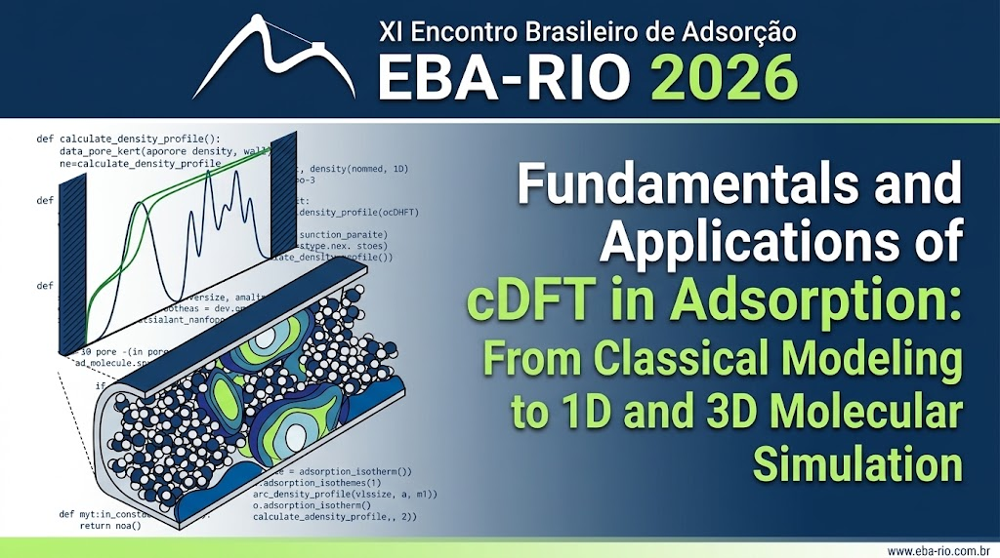


# cDFT aplicada à adsorção com PyDFTlj

**Curso hands-on · Google Colab · Revisão 6**

Uma ideia guia a aula: a cDFT estende a termodinâmica do bulk para uma densidade que varia no espaço. Vamos ligar essa ideia a decisões concretas: fluido, funcional, campo de força, malha, solver e observáveis.

O percurso de **4 horas** cobre preparação, EOS, perfis 1D, histerese, uma comparação entre Steele 1D e carbono atomístico 3D e o caso CIF–MOF. Ao final ficam as extensões de malha e RDF e os testes de solver e hardware. Executar todos os cálculos finos pode ultrapassar a duração da aula.

DFT aqui é **clássica**, não eletrônica. Trabalhamos com uma espécie de fluido representada por um sítio LJ efetivo. Código fixado: [PyDFTlj 1.0.3, commit 16e7d43](https://github.com/elvissoares/PyDFTlj/tree/16e7d4349e22d3ead8774a332011b4c3d21806cd).


## Roteiro da aula

As partes agrupam objetivos; as **seções numeradas de 1 a 19** seguem uma única sequência. Os subtítulos internos herdam o número da seção. Não há blocos fora das partes.

| Parte | Seções | Tempo sugerido | Resultado |
|---|---|---:|---|
| A — Preparação e fundamentos | 1–5 | 0–65 min | Colab, unidades, EOS e configuração da cDFT |
| B — Adsorção 1D em carbono | 6–9 | 65–135 min | Potencial de Steele, perfis e histerese de N₂ |
| Intervalo | — | 135–145 min | — |
| C — Da fenda 1D à fenda 3D | 10 | 145–170 min | Slab ASE, soma LJ e comparação com Steele |
| D — CH₄ em IRMOF-1 | 11–13 | 170–230 min | CIF, potencial, densidade e isoterma |
| E — Extensões físicas e numéricas | 14–15 | Estudo orientado | Malhas da MOF e RDF |
| F — Troubleshooting e desempenho | 16–18 | Estudo orientado | Diagnóstico, três solvers e CPU/GPU |
| G — Aplicação à pesquisa | 19 | 230–240 min | Plano de adaptação do aluno |

**Percurso em aula:** A → B → C → D → G. As partes E e F ficam após os estudos de caso, para consulta e atividades extras. Tempos são de planejamento, não garantias de execução.

**Execução no Colab:** rode as células em ordem no percurso escolhido. A seção 14 depende dos dados da MOF; a 15 depende apenas das importações e da pasta `dados`; a 17 reutiliza `slab_dft` da seção 10; a 18 tem construtor próprio. “Executar tudo” inclui extensões caras. Salve uma cópia antes de explorar malhas maiores.


# Parte A — Preparação e fundamentos


## 1. Preparação no Google Colab

1. Abra este arquivo em [Google Colab](https://colab.research.google.com/) usando **Arquivo → Fazer upload de notebook**.
2. Para usar GPU, abra **Ambiente de execução → Alterar tipo de ambiente de execução** e escolha uma GPU disponível em **Acelerador de hardware** (por exemplo, T4). Salve e reconecte. Os nomes dos menus podem variar com o idioma da interface.
3. Execute a instalação abaixo e depois a célula de importações. `CUDA disponível: True` confirma que o PyTorch consegue usar a GPU.
4. Se a sessão reiniciar, repita a instalação e as células necessárias para reconstruir os objetos. Arquivos em `/content` são temporários; baixe o notebook e os resultados ao terminar.

CPU funciona para todos os exemplos. GPU é especialmente útil nas malhas 3D maiores; disponibilidade e memória dependem da sessão do Colab.

O pacote depende de NumPy, SciPy, pandas, Matplotlib, SciencePlots e PyTorch. Adicionamos **ASE** (CIF e `.cube`), **py3Dmol** (campos 3D interativos) e **xlrd** (planilhas de referência). O commit fixado torna a API reproduzível. A próxima célula instala essas dependências.


In [1]:
%pip -q install "git+https://github.com/elvissoares/PyDFTlj.git@16e7d4349e22d3ead8774a332011b4c3d21806cd" ase py3Dmol xlrd


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 26.1 MB/s eta 0:00:00


Importamos as bibliotecas e registramos versões, dispositivo e disponibilidade de CUDA. Essas informações ajudam a reproduzir os resultados.


In [2]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
from urllib.request import urlretrieve
import gc
import inspect
import time
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pydftlj.dft import DFT
from pydftlj.eos import LJEOS
from pydftlj.optimizer import Optimizer

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.20})

COMMIT = "16e7d4349e22d3ead8774a332011b4c3d21806cd"
RAW = f"https://raw.githubusercontent.com/elvissoares/PyDFTlj/{COMMIT}"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_1D = "cpu"  # Malhas pequenas; a comparação de hardware fica na seção 18.
CPU_THREADS = 1    # Ajustável; evita excesso de threads nas FFTs pequenas da aula.
torch.set_num_threads(CPU_THREADS)

print("Python:", sys.version.split()[0])
for pacote in ["pydftlj", "numpy", "scipy", "pandas", "matplotlib", "torch", "ase", "py3Dmol"]:
    print(f"{pacote:12s}: {version(pacote)}")
print("CUDA do PyTorch:", torch.version.cuda)
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Dispositivo:", DEVICE)


Python: 3.13.15
pydftlj     : 1.0.3
numpy       : 2.1.3
scipy       : 1.16.3
pandas      : 2.2.3
matplotlib  : 3.10.0
torch       : 2.11.0+cu130
ase         : 3.29.0
py3Dmol     : 2.5.5
CUDA do PyTorch: 13.0
CUDA disponível: True
GPU: Tesla T4
Dispositivo: cuda


## 2. Primeiro, entenda o objeto que será montado

```text
PyDFTlj/
├── pydftlj/
│   ├── __init__.py
│   ├── dft.py          Malha, campos, funcionais e observáveis
│   ├── eos.py          EOS de esferas duras e LJ; equilíbrio líquido–vapor
│   ├── optimizer.py    Picard, Anderson, FIRE e ABC-FIRE
│   └── aux.py          Funções-peso FMT e kernels LJ em Fourier
├── examples/
│   ├── Example1...     EOS e diagrama de fases
│   ├── Example2...     Esferas duras junto a uma parede
│   ├── Example3...     LJ em parede dura e fenda de Steele
│   ├── Example4...     Função de distribuição radial
│   ├── Example5...     CH4 em MOFs
│   ├── Example6...     CH4 em carbono amorfo
│   ├── structures/    CIFs de MOFs e carbonos
│   ├── parameters/    DREIDING, UFF e Steele
│   ├── data/
│   │   ├── MC/        Dados de simulação molecular (incluem MC e MD)
│   │   └── experimental/
│   └── figures/       Figuras de referência
├── dist/              Distribuições empacotadas
├── pyproject.toml     Metadados e dependências
├── setup.py           Instalação
├── README.md          Visão geral e referências
└── LICENSE            GPL-3.0
```

Alguns exemplos antigos usam `Set_...` e `ndim`. Neste curso usamos a API `snake_case` do commit fixado.



### 2.1 Ordem segura de um cálculo

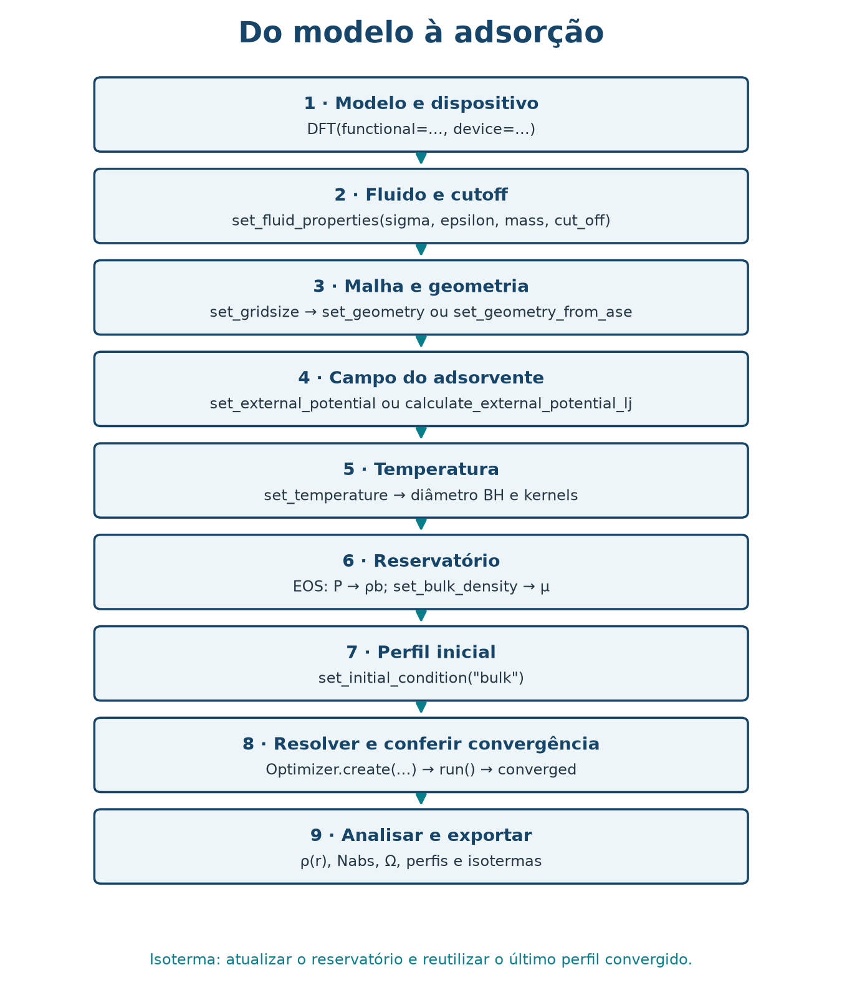

A ordem tem efeito: `set_temperature()` cria kernels e regiões acessíveis a partir do campo já definido. Atualizar `rhob` muda o reservatório; atualizar o perfil inicial descarta o chute anterior. Em uma isoterma, mantemos o perfil convergido para a pressão seguinte.



### 2.2 Argumentos que você realmente ajustará

| Chamada | Argumentos e efeito |
|---|---|
| `DFT(functional, device)` | Parte repulsiva + atrativa; `cpu` ou `cuda` |
| `set_fluid_properties(sigma, epsilon, mass, cut_off)` | Escalas do fluido, massa e alcance do kernel |
| `set_gridsize(gridsize)` | Espaçamento em cada direção |
| `set_geometry(lengths)` | Escalar: 1D efetivo; tupla de três comprimentos: 3D |
| `set_geometry_from_ase(atoms)` | Estrutura e célula ortogonal vindas de ASE |
| `set_external_potential(Vext)` | Array com a mesma forma de `Ngrid` |
| `set_temperature(kT)` | Temperatura na convenção adotada |
| `set_bulk_density(rhob)` | Densidade numérica do reservatório e potencial químico |
| `set_initial_condition(model="bulk")` | Perfil inicial; a opção é sensível a maiúsculas |
| `Optimizer.create(nome, sistema, ...)` | Picard: `alpha`; Anderson: `alpha`, `history_size`, `regularization`; FIRE: `dt`, `dt_max`, `mode` |
| `LJEOS(sigma, epsilon)` | `p(rho,T)`, `mu(rho,T)` e `VLE()` sem criar DFT |

Os métodos de configuração alteram o objeto. Resultados são lidos em `rho`, `Vext`, `Omega`, `Nabs` e nos arquivos exportados.


## 3. Unidades sem mistério

O pacote recebe números sem metadados de unidades. No caso dimensional, adotamos Å, K e partículas. **Temperatura em K não é uma energia**: os demais valores energéticos são divididos por $k_B$, tornando `beta=1/T` compatível com eles.



### 3.1 Entradas

| Variável / argumento | Unidade | Observação |
|---|---|---|
| `sigma`, `gridsize`, `lengths`, posições do CIF | Å | ASE usa Å; `gridsize` é espaçamento, não número de pontos |
| `epsilon` | K | Valor de $\epsilon/k_B$; divida uma energia em joules por $k_B$ |
| `kT` em `set_temperature` | K | Nome histórico do argumento; fornecemos T na convenção dimensional |
| `Vext` | K | Energia externo–fluido dividida por $k_B$ |
| `rhob` | Partículas/Å³ | Densidade numérica; não é mol/L nem kg/m³ |
| `mass` | u | Massa de uma molécula; valor numérico igual à massa molar em g/mol |
| `pbar_values`, `pbar` | bar | Entradas das rotas de pressão do pacote |
| `sigma/AA`, `epsilon/kB` no campo de força | Å, K | Parâmetros por símbolo do sólido; o helper aplica Lorentz–Berthelot |
| `cut_off` | Comprimento no kernel fluido–fluido | O helper atomístico tem outra convenção no commit; veja a nota abaixo |
| `alpha`, `rtol`, `atol` do solver | Adimensionais | A tolerância atua no resíduo em $\ln\rho$; `dt` de FIRE não é tempo físico |



### 3.2 Saídas

| Variável / resultado | Unidade | Observação |
|---|---|---|
| `rho`, `rhob` | Partículas/Å³ | $\rho^*=\rho\sigma^3$ é adimensional |
| `Vext`, `mu`, `muid`, `muexc` | K | Para J por partícula, multiplique por $k_B$ |
| `c1`, `beta*Vext`, `beta*mu`, `n3` | Adimensional | `c1` tem sinal oposto à derivada de $\beta F^{exc}$; `n3` é densidade ponderada |
| `Fid`, `Fhs`, `Flj`, `Omega` | K por célula numérica | Multiplique por $k_B$ para J por célula; não são energias molares |
| `eos.p(rho,T)` | K/Å³ | Multiplique por $k_B\,10^{25}$ para bar |
| `Volbox`, `Vol`, `Vpore` | Å³ | Volumes geométrico, numérico e acessível ao He, respectivamente |
| `Nabs` | Partículas por célula numérica | Em 1D, use $N/A=\int\rho(z)dz$ para comparar por área |
| `helium_fraction` | Adimensional | `Vpore/Volbox`; depende da convenção da sonda He |
| Arquivo de isoterma | Indicada em cada coluna | Inclui bar, mol/kg e excesso; leia o cabeçalho antes de converter |
| Campo em `.cube` | A escolhida na exportação | Neste notebook: potencial $V/T$ e densidade em partículas/Å³; ASE converte as coordenadas para a convenção do formato |

**Cutoff:** em `aux.lj_potential`, o teste é `r > rcut*sigma`, enquanto `lj3dFT` recebe um comprimento. Isso deve ser auditado antes de transferir parâmetros de literatura. O caso MOF mantém a convenção numérica original para comparação.

**Unidades reduzidas:** com $\sigma=\epsilon=1$, interprete $r,T,\rho$ como $r^*,T^*,\rho^*$. Os rótulos Å/K impressos pelo pacote não mudam automaticamente. As rotas `pbar` pressupõem a convenção dimensional.

O potencial químico interno usa um zero convencional na parte ideal. Compare Ω de estados com a mesma convenção de μ. Abaixo, três fatores mostram conversões típicas sem esconder a conta em funções auxiliares.


In [3]:
# Três fatores bastam para as conversões usadas no curso.
kB = 1.380649e-23       # J/K
NA = 6.02214076e23      # 1/mol
amu = 1.66053906660e-27 # kg

K_A3_para_bar = kB * 1e30 / 1e5
rho_A3_para_mol_m3 = 1e30 / NA
K_para_kJ_mol = kB * NA / 1000

tabela_unidades = pd.DataFrame({
    "Grandeza": ["Densidade", "Pressão", "Energia"],
    "Valor interno": [1.0e-3, 0.25, 300.0],
    "Unidade interna": ["moléculas/Å³", "K/Å³", "K"],
    "Valor convertido": [
        1.0e-3 * rho_A3_para_mol_m3,
        0.25 * K_A3_para_bar,
        300.0 * K_para_kJ_mol,
    ],
    "Unidade convertida": ["mol/m³", "bar", "kJ/mol"],
})
display(tabela_unidades.style.format({"Valor interno": "{:.4g}", "Valor convertido": "{:.5g}"}))


,Grandeza,Valor interno,Unidade interna,Valor convertido,Unidade convertida
0,Densidade,0.001,moléculas/Å³,1660.5,mol/m³
1,Pressão,0.25,K/Å³,34.516,bar
2,Energia,300,K,2.4943,kJ/mol


## 4. A EOS antes da cDFT

A `LJEOS` pode ser usada sem criar um objeto DFT. Primeiro veremos $p(\rho)$ e $\mu(\rho)$ do CH₄ efetivo TraPPE; depois, o equilíbrio líquido–vapor.


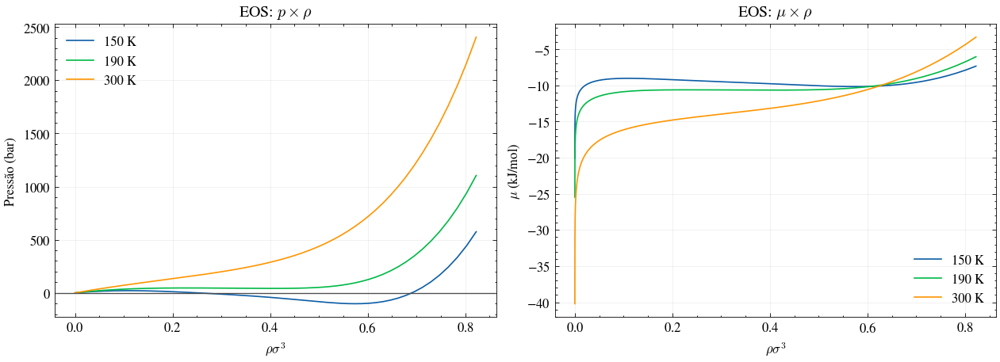

In [4]:
sigma = 3.73    # Å, CH4 TraPPE-UA efetivo
epsilon = 148.0 # K
mass = 16.043   # u

eos = LJEOS(sigma=sigma, epsilon=epsilon)
rho = torch.logspace(-7, -1.80, 500, dtype=torch.float64) # moléculas/Å³
temperaturas = [150.0, 190.0, 300.0]                     # K

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for temp in temperaturas:
    p = eos.p(rho, temp).numpy() * K_A3_para_bar
    mu = eos.mu(rho, temp).numpy() * K_para_kJ_mol
    ax[0].plot(rho.numpy() * sigma**3, p, label=f"{temp:.0f} K")
    ax[1].plot(rho.numpy() * sigma**3, mu, label=f"{temp:.0f} K")

ax[0].axhline(0, color="0.3", lw=0.8)
ax[0].set(xlabel=r"$\rho\sigma^3$", ylabel="Pressão (bar)", title=r"EOS: $p\times\rho$")
ax[1].set(xlabel=r"$\rho\sigma^3$", ylabel=r"$\mu$ (kJ/mol)", title=r"EOS: $\mu\times\rho$")
for eixo in ax:
    eixo.legend(frameon=False)
plt.show()


### 4.1 Equilíbrio líquido–vapor

`VLE()` encontra o ponto crítico por $\partial p/\partial\rho=\partial^2p/\partial\rho^2=0$ e segue a coexistência impondo $p_v=p_l$ e $\mu_v=\mu_l$. As três projeções abaixo mostram a mesma informação termodinâmica.


In [5]:
dados = Path("dados_curso")
dados.mkdir(exist_ok=True)

arquivo = dados / "methane-saturation.dat"
if not arquivo.exists():
    urlretrieve(f"{RAW}/examples/data/experimental/methane-saturation.dat", arquivo)
exp = pd.read_csv(arquivo, sep="\t")

rho_c, T_c, rho_sat, T_sat, p_sat = eos.VLE(kTmin=0.65)
n = len(rho_sat) // 2

# Conversões para unidades familiares ao público de adsorção.
rho_sat = rho_sat * 1e30 * mass * amu
p_sat = p_sat * K_A3_para_bar
rho_c = rho_c * 1e30 * mass * amu

rho_v, rho_l = rho_sat[:n], rho_sat[n:]
T_v, T_l = T_sat[:n], T_sat[n:]
p_v, p_l = p_sat[:n], p_sat[n:]


Vamos reunir os três diagramas de coexistência: temperatura–densidade, pressão de saturação–temperatura e pressão de saturação–densidade. Cores iguais identificam o mesmo ramo nas curvas e nos dados.


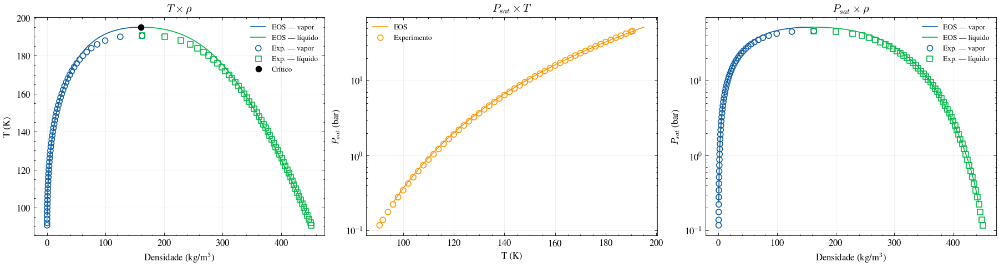

In [6]:
vapor, liquido, pressao = "C0", "C1", "C2"
p_exp = 10 * exp["Pressure (MPa)"]

fig, ax = plt.subplots(1, 3, figsize=(15.0, 4.0), constrained_layout=True)

# T x rho
ax[0].plot(rho_v, T_v, color=vapor, label="EOS — vapor")
ax[0].plot(rho_l, T_l, color=liquido, label="EOS — líquido")
ax[0].scatter(exp["Vapor Density (kg/m3)"], exp["Temperature (K)"],
              facecolors="none", edgecolors=vapor, label="Exp. — vapor")
ax[0].scatter(exp["Liquid Density (kg/m3)"], exp["Temperature (K)"],
              marker="s", facecolors="none", edgecolors=liquido, label="Exp. — líquido")
ax[0].plot(rho_c, T_c, "ko", label="Crítico")

# Psat x T
ax[1].plot(T_v, p_v, color=pressao, label="EOS")
ax[1].scatter(exp["Temperature (K)"], p_exp,
              facecolors="none", edgecolors=pressao, label="Experimento")

# Psat x rho
ax[2].plot(rho_v, p_v, color=vapor, label="EOS — vapor")
ax[2].plot(rho_l, p_l, color=liquido, label="EOS — líquido")
ax[2].scatter(exp["Vapor Density (kg/m3)"], p_exp,
              facecolors="none", edgecolors=vapor, label="Exp. — vapor")
ax[2].scatter(exp["Liquid Density (kg/m3)"], p_exp,
              marker="s", facecolors="none", edgecolors=liquido, label="Exp. — líquido")

titulos = [r"$T\times\rho$", r"$P_{sat}\times T$", r"$P_{sat}\times\rho$"]
for eixo, titulo in zip(ax, titulos):
    eixo.set_title(titulo)
    eixo.legend(frameon=False, fontsize=8)
ax[0].set(xlabel=r"Densidade (kg/m$^3$)", ylabel="T (K)")
ax[1].set(xlabel="T (K)", ylabel=r"$P_{sat}$ (bar)", yscale="log")
ax[2].set(xlabel=r"Densidade (kg/m$^3$)", ylabel=r"$P_{sat}$ (bar)", yscale="log")
plt.savefig("v6_diagrama_fases_CH4.png", dpi=220, bbox_inches="tight")
plt.show()


### Exercício 1: Determinação e Análise do Equilíbrio Líquido-Vapor ($\text{N}_2$ e $\text{Ar}$)

#### Objetivo
Calcular e representar graficamente o envelope de equilíbrio líquido-vapor (ELV) para o nitrogênio molecular ($\text{N}_2$) e para o argônio ($\text{Ar}$), avaliando o comportamento termodinâmico dos fluidos puros por meio dos seguintes diagramas de fase:

1. **Diagrama de Coexistência de Fases ($\rho \times T$):** Curvas de densidade das fases líquida ($\rho_{\mathrm{liq}}$) e vapor ($\rho_{\mathrm{vap}}$) em função da temperatura, destacando a região bifásica e a aproximação do ponto crítico.
2. **Curva de Pressão de Saturação ($T \times P_{\mathrm{sat}}$ ou $\ln P_{\mathrm{sat}} \times 1/T$):** Evolução da pressão de vapor com a temperatura ao longo da linha de equilíbrio.
3. **Isotermas e Envelopes de Coexistência ($\rho \times P_{\mathrm{sat}}$):** Comportamento da densidade em relação à pressão de equilíbrio para diferentes condições isotérmicas.

---

#### Parâmetros compatíveis com a EOS de um sítio

O PyDFTlj não implementa diretamente o N₂ TraPPE de múltiplos sítios e cargas. Seus valores σ=3,310 Å e ε/kB=36 K são **por sítio N**: inseri-los em `LJEOS` não reproduz o ELV do N₂ molecular.

Para executar o exercício com a biblioteca do curso, adote:

| Fluido / modelo | Representação | σ [Å] | ε/kB [K] | Massa [u] |
|---|---|---:|---:|---:|
| Ar LJ | Um átomo | 3,405 | 119,8 | 39,948 |
| N₂ efetivo | Um sítio por molécula, sem quadrupolo | 3,615 | 101,5 | 28,0134 |

O N₂ efetivo segue os parâmetros LJ–MC de Ravikovitch et al. usados na seção 9. Ele **não é o campo de força TraPPE molecular**. Discuta essa limitação ao interpretar os envelopes. Os parâmetros de Ar são um modelo LJ convencional; a referência TraPPE de n-alcanos não deve ser usada como fonte específica do Ar.


---

#### Referências

* **$\text{N}_2$ (TraPPE):** Potoff, J. J.; Siepmann, J. I. *Vapor–Liquid Equilibria of Mixtures Containing Alkanes, Carbon Dioxide, and Nitrogen.* **AIChE Journal**, v. 47, n. 7, p. 1676–1682, 2001. [DOI: 10.1002/aic.690470719](https://doi.org/10.1002/aic.690470719)
* **Ar LJ:** Rahman, A. *Correlations in the Motion of Atoms in Liquid Argon*. Physical Review 136, A405 (1964). [DOI](https://doi.org/10.1103/PhysRev.136.A405).
* **N₂ efetivo:** Ravikovitch et al., Langmuir 16, 2311–2320 (2000), parâmetros LJ–MC da Tabela 1. [DOI](https://doi.org/10.1021/la991011c).


#### Gabarito 1 — início do bloco removível

**Pré-requisitos:** importações e fatores de conversão das seções 1–3. Todas as células desta resolução têm as tags `gabarito` e `exercicio-1`. Ao preparar a versão do aluno, remova deste título até “Fim do gabarito 1”.

Usaremos a EOS LJ de **um sítio por partícula**. N₂ é, portanto, o modelo efetivo explicitado no enunciado, não o N₂ TraPPE de múltiplos sítios. Começamos calculando a coexistência de cada fluido; `VLE()` retorna primeiro o ramo vapor em temperatura crescente e depois o líquido em temperatura decrescente. As unidades internas são convertidas apenas para apresentação.

In [7]:
fluidos_ex1 = {
    "N₂ efetivo": (3.615, 101.5, 28.0134),  # sigma [Å], epsilon/kB [K], massa [u]
    "Ar LJ": (3.405, 119.8, 39.948),
}
elv_ex1, criticos_ex1 = {}, []
for nome, (sig, eps, massa) in fluidos_ex1.items():
    eos_ex1 = LJEOS(sigma=sig, epsilon=eps)
    rc, tc, densidades, temperaturas, pressoes_sat = eos_ex1.VLE(kTmin=0.70)
    metade = len(densidades)//2
    fator_massa = 1e30 * massa * amu  # Partículas/Å³ -> kg/m³.
    elv_ex1[nome] = {
        "Vapor": pd.DataFrame({"T (K)": temperaturas[:metade],
            "Densidade (kg/m³)": densidades[:metade]*fator_massa,
            "Pressão (bar)": pressoes_sat[:metade]*K_A3_para_bar}),
        "Líquido": pd.DataFrame({"T (K)": temperaturas[metade:],
            "Densidade (kg/m³)": densidades[metade:]*fator_massa,
            "Pressão (bar)": pressoes_sat[metade:]*K_A3_para_bar}),
    }
    pc = float(eos_ex1.p(torch.tensor(rc, dtype=torch.float64), tc))*K_A3_para_bar
    criticos_ex1.append([nome, tc, rc*fator_massa, pc, tc/eps, rc*sig**3])
    for ramo, tabela in elv_ex1[nome].items():
        tabela.to_csv(f"ex1_{nome.split()[0]}_{ramo}.csv", index=False)

criticos_ex1 = pd.DataFrame(criticos_ex1, columns=["Modelo", "Tc (K)",
    "Densidade crítica (kg/m³)", "Pc (bar)", "Tc reduzida", "Densidade crítica reduzida"])
display(criticos_ex1.round(4))

,Modelo,Tc (K),Densidade crítica (kg/m³),Pc (bar),Tc reduzida,Densidade crítica reduzida
0,N₂ efetivo,133.7894,308.1040,39.0920,1.3181,0.3129
1,Ar LJ,157.9111,525.7752,55.2143,1.3181,0.3129


Os seis painéis apresentam as três projeções para cada fluido. Vapor e líquido conservam suas cores; a estrela marca o crítico calculado. Na projeção P–ρ, uma linha horizontal ilustra que duas densidades coexistem à mesma pressão. Ela não é uma isoterma completa da EOS.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


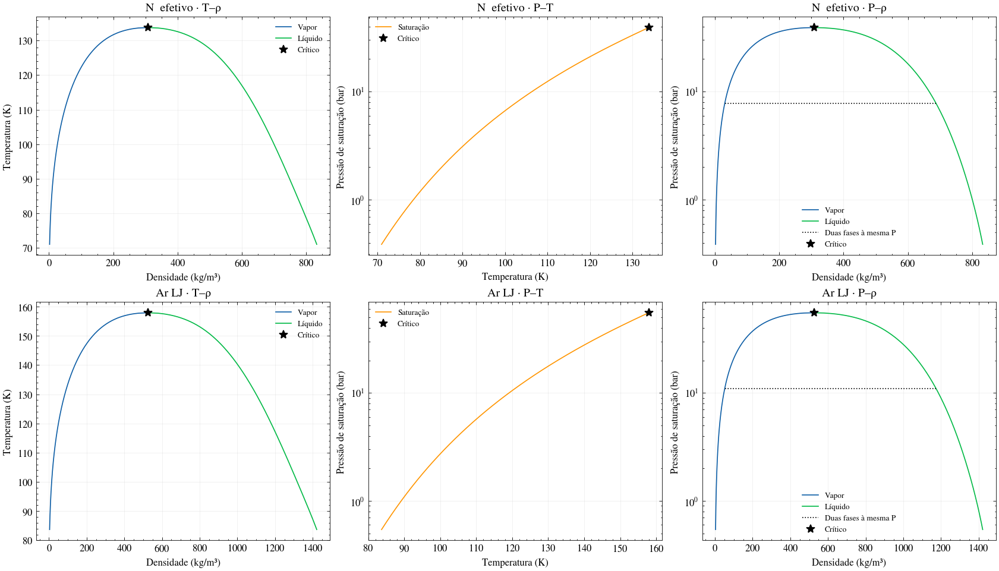

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for linha, (nome, ramos) in enumerate(elv_ex1.items()):
    ax = axes[linha]
    for ramo, cor in [("Vapor", "C0"), ("Líquido", "C1")]:
        t = ramos[ramo]
        ax[0].plot(t["Densidade (kg/m³)"], t["T (K)"], color=cor, label=ramo)
        ax[2].plot(t["Densidade (kg/m³)"], t["Pressão (bar)"], color=cor, label=ramo)
    v = ramos["Vapor"]
    l = ramos["Líquido"].sort_values("T (K)").reset_index(drop=True)
    ax[1].semilogy(v["T (K)"], v["Pressão (bar)"], color="C2", label="Saturação")
    k = len(v)//2
    ax[2].plot([v.iloc[k]["Densidade (kg/m³)"], l.iloc[k]["Densidade (kg/m³)"]],
               [v.iloc[k]["Pressão (bar)"]]*2, "k:", label="Duas fases à mesma P")
    cr = criticos_ex1.iloc[linha]
    ax[0].plot(cr["Densidade crítica (kg/m³)"], cr["Tc (K)"], "k*", ms=9, label="Crítico")
    ax[1].plot(cr["Tc (K)"], cr["Pc (bar)"], "k*", ms=9, label="Crítico")
    ax[2].plot(cr["Densidade crítica (kg/m³)"], cr["Pc (bar)"], "k*", ms=9, label="Crítico")
    ax[0].set(xlabel="Densidade (kg/m³)", ylabel="Temperatura (K)", title=f"{nome} · T–ρ")
    ax[1].set(xlabel="Temperatura (K)", ylabel="Pressão de saturação (bar)", title=f"{nome} · P–T")
    ax[2].set(xlabel="Densidade (kg/m³)", ylabel="Pressão de saturação (bar)", yscale="log", title=f"{nome} · P–ρ")
    for eixo in ax: eixo.legend(frameon=False, fontsize=8)
plt.show()

**Interpretação.** Os dois ramos se encontram no crítico; a pressão de saturação cresce com T. Os parâmetros ε e σ mudam as escalas dimensionais, mas os dois fluidos compartilham a mesma EOS reduzida: confira as duas últimas colunas da tabela. Isso evidencia estados correspondentes e também a limitação do modelo. A EOS não descreve orientação, quadrupolo de N₂ nem congelamento. Um envelope líquido–vapor calculado não é uma validação experimental do campo de força.

**Fim do gabarito 1.**

### 4.2 Da EOS à cDFT: o limite uniforme

Para um fluido uniforme, $\rho(\mathbf r)=\rho_b$ e

$$F[\rho_b]=Vf(\rho_b),\qquad
\frac{\delta F}{\delta\rho(\mathbf r)}=\frac{\partial f}{\partial\rho}\bigg|_{\rho_b}=\mu_{bulk}.$$

Sem campo externo,

$$\frac{\Omega}{V}=f(\rho_b)-\mu\rho_b,$$

e a condição de equilíbrio é justamente $\partial f/\partial\rho=\mu$. A cDFT troca o escalar $\rho_b$ pelo campo $\rho(\mathbf r)$, mas deve recuperar essa EOS quando o campo volta a ser uniforme.


## 5. As equações essenciais e os modelos



### 5.1 Potencial grande-canônico

| Termo | Expressão matemática do termo | Papel físico | No PyDFTlj |
|---|---|---|---|
| Ideal | $$F^{id}[\rho]=k_BT\int\rho(\mathbf r)\{\ln[\rho(\mathbf r)\Lambda^3]-1\}\,d\mathbf r$$ | Entropia de translação | `Fid` |
| Excesso | $$F^{exc}[\rho]=F^{hs}[\rho]+F^{att}[\rho]$$ | Exclusão de volume e atração | `Fhs, Flj` |
| Sólido–fluido | $$\int V_{ext}(\mathbf r)\rho(\mathbf r)\,d\mathbf r$$ | Geometria e química do adsorvente | `Vext` |
| Reservatório | $$-\mu\int\rho(\mathbf r)\,d\mathbf r$$ | Troca de partículas com o bulk | `mu, rhob` |


$$\Omega[\rho]=F^{id}[\rho]+F^{exc}[\rho]+\int[V_{ext}(\mathbf r)-\mu]\rho(\mathbf r)\,d\mathbf r.$$



### 5.2 Equilíbrio: minimizar Ω

A temperatura, potencial químico e campo externo fixos, o perfil de equilíbrio minimiza o funcional:

$$\rho_{eq}=\underset{\rho\geq0}{\operatorname{arg\,min}}\;\Omega[\rho],\qquad
\left.\frac{\delta\Omega}{\delta\rho(\mathbf r)}\right|_{\rho_{eq}}=0.$$

A estacionariedade produz **Euler–Lagrange** nas regiões acessíveis:

$$k_BT\ln[\rho(\mathbf r)\Lambda^3]+\frac{\delta F^{exc}}{\delta\rho(\mathbf r)}+V_{ext}(\mathbf r)-\mu=0.$$

Com $c^{(1)}(\mathbf r)=-\beta\,\delta F^{exc}/\delta\rho(\mathbf r)$,

$$\rho(\mathbf r)=\Lambda^{-3}\exp[\beta\mu-\beta V_{ext}(\mathbf r)+c^{(1)}(\mathbf r)].$$

Eliminando a contribuição ideal pelo estado bulk:

$$\rho(\mathbf r)=\rho_b\exp[-\beta V_{ext}(\mathbf r)+c^{(1)}(\mathbf r)+\beta\mu^{exc}(\rho_b)].$$

O solver procura um resíduo nulo em $\ln\rho$. **Resíduo pequeno garante estacionariedade, não o mínimo global.** Na seção de histerese compararemos Ω de dois perfis convergidos no mesmo reservatório.

A próxima célula mostra como `compute_force` escreve esse resíduo no código.


In [9]:
# A implementação da equação de Euler–Lagrange cabe em poucas linhas.
print(inspect.getsource(DFT.compute_force))


    def compute_force(self):
        F = -(self.lnrho - self.c1 - self.beta * self.mu + self.beta * self.Vext)
        F[~self.allowed] = 0.0  # Set force to zero in forbidden regions
        return F



### 5.3 Funcionais disponíveis

Uma única string combina as duas partes: `"aWBI+MMFA"`. Sem sufixo atrativo, por exemplo `"WBI"`, o sistema é de esferas duras.

| Parte | Opção | Ideia | Referência / implementação |
|---|---|---|---|
| **Repulsiva · FMT** | `RF` | Rosenfeld original; funções-peso geométricas, limite bulk Percus–Yevick | [Rosenfeld, 1989](https://doi.org/10.1103/PhysRevLett.63.980) |
| **Repulsiva · FMT** | `WBI` | White Bear I; melhora a termodinâmica bulk de esferas duras, associada a Carnahan–Starling | [Roth et al., 2002](https://doi.org/10.1088/0953-8984/14/46/313); [Yu & Wu, 2002](https://doi.org/10.1063/1.1520530) |
| **Repulsiva · FMT** | `WBII` | White Bear II; revisão das funções de densidade para maior consistência termodinâmica | [Hansen-Goos & Roth, 2006](https://doi.org/10.1088/0953-8984/18/37/002) |
| **Repulsiva · FMT** | `aRF`, `aWBI`, `aWBII` | Variantes assimétricas: dependência do campo vetorial via $\xi$; mantêm o limite homogêneo das respectivas bases | [Ramo `startswith('a')` em `dft.py`](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/pydftlj/dft.py); família FMT acima |
| **Atrativa · LJ** | `MFA` | Convolução quadrática de campo médio; kernel com separação WCA; EOS bulk própria de campo médio | [Weeks–Chandler–Andersen, 1971](https://doi.org/10.1063/1.1674820); chamada explícita abaixo |
| **Atrativa · LJ** | `WDA` | Excesso atrativo avaliado em densidade ponderada, obtido da EOS LJ menos a referência HS | [Shen, Ji & Lu, 2013](https://doi.org/10.1063/1.4808160) |
| **Atrativa · LJ** | `MMFA` | Campo médio com kernel BH e correção em densidade ponderada; recupera a EOS LJ adotada | [Soares, Barreto & Tavares, 2021](https://doi.org/10.1016/j.fluid.2021.113095) |

WDA e MMFA recuperam a EOS LJ/MBWR utilizada pelo pacote; MFA não tem a mesma EOS bulk. Veja [Johnson, Zollweg & Gubbins, 1993](https://doi.org/10.1080/00268979300100411).


### 5.4 Consistência EOS–funcional em uma figura

No campo uniforme, a consistência exige

$$\beta\mu^{exc}(\rho_b)=-\left.c^{(1)}(\mathbf r)\right|_{\rho=\rho_b}.$$

Compararemos `s.beta*s.muexc` com `-s.c1.mean()`: ambos adimensionais. O sinal negativo é essencial. A diagonal representa igualdade; WDA e MMFA quase coincidem porque recuperam a mesma EOS. Usaremos símbolos e anotações distintos sem deslocar os dados.

Os cabeçalhos da tabela serão escritos por extenso para funcionar também onde o HTML do pandas não renderiza LaTeX. Os eixos usam notação matemática.


Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³
Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³
Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³


,Funcional,Potencial químico de excesso / kBT,Menos correlação direta uniforme,Diferença
0,WBI+MFA,-1.414004,-1.414004,-0.000000
1,WBI+WDA,-1.049361,-1.049382,-0.000021
2,WBI+MMFA,-1.049361,-1.049382,-0.000021


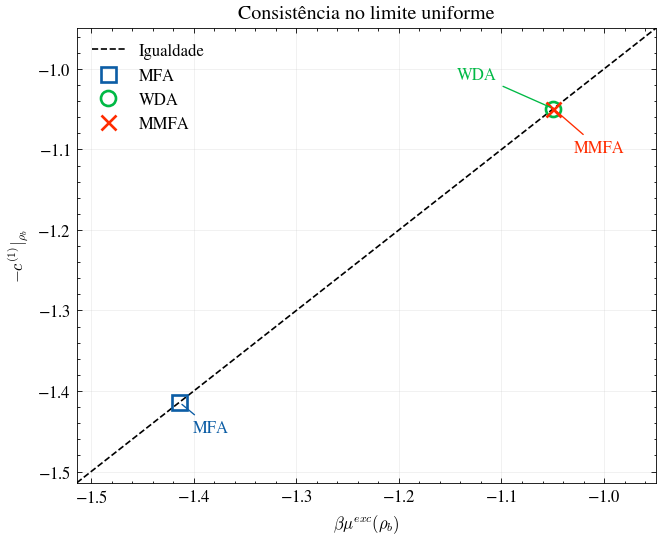

In [10]:
comparacao = []

for modelo in ["WBI+MFA", "WBI+WDA", "WBI+MMFA"]:
    s = DFT(functional=modelo, device=DEVICE_1D)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=3.5)
    s.set_gridsize(gridsize=0.5)
    s.set_geometry(lengths=6.0)
    s._from_ase = False  # geometria manual na v1.0.3
    s.set_external_potential(np.zeros(s.Ngrid, dtype=np.float32))
    s.set_temperature(kT=1.35)
    s.set_bulk_density(rhob=0.20)
    s.set_initial_condition(model="bulk")

    mu_eos = s.beta * float(s.muexc)
    mu_func = -float(s.c1.mean())
    comparacao.append([modelo, mu_eos, mu_func, mu_func - mu_eos])

consistencia = pd.DataFrame(
    comparacao,
    columns=["Funcional", "Potencial químico de excesso / kBT", "Menos correlação direta uniforme", "Diferença"],
)
display(consistencia.style.format(precision=6))


fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
lim = [consistencia[["Potencial químico de excesso / kBT", "Menos correlação direta uniforme"]].min().min() - 0.1,
       consistencia[["Potencial químico de excesso / kBT", "Menos correlação direta uniforme"]].max().max() + 0.1]
ax.plot(lim, lim, "k--", lw=1, label="Igualdade")

# WDA e MMFA quase coincidem: círculo vazado e cruz revelam os dois pontos.
estilos = [("s", "C0", (8, -18)), ("o", "C1", (-58, 18)), ("x", "C3", (12, -26))]
for (_, linha), (marcador, cor, offset) in zip(consistencia.iterrows(), estilos):
    nome = linha["Funcional"].split("+")[1]
    ax.plot(linha["Potencial químico de excesso / kBT"], linha["Menos correlação direta uniforme"],
            marker=marcador, color=cor, ms=9, mfc="none", mew=1.6, ls="none", label=nome)
    ax.annotate(nome, (linha["Potencial químico de excesso / kBT"], linha["Menos correlação direta uniforme"]),
                xytext=offset, textcoords="offset points", color=cor,
                arrowprops={"arrowstyle": "-", "color": cor, "lw": 0.8})
ax.set(xlabel=r"$\beta\mu^{exc}(\rho_b)$", ylabel=r"$-c^{(1)}|_{\rho_b}$",
       xlim=lim, ylim=lim, title="Consistência no limite uniforme")
ax.legend(frameon=False, loc="upper left")
plt.show()


# Parte B — Adsorção 1D em carbono



## 6. Potencial externo: parâmetros antes do solver

Para uma parede plana,

$$V_S(z)=\epsilon_w\left[\frac25\left(\frac{\sigma_w}{z}\right)^{10}
-\left(\frac{\sigma_w}{z}\right)^4
-\frac{\sigma_w^4}{3\Delta(z+0.61\Delta)^3}\right].$$

$\epsilon_w$ controla principalmente a profundidade; $\sigma_w$ desloca a região repulsiva e o mínimo. Para uma fenda, somamos $V_S(z)+V_S(H-z)$.

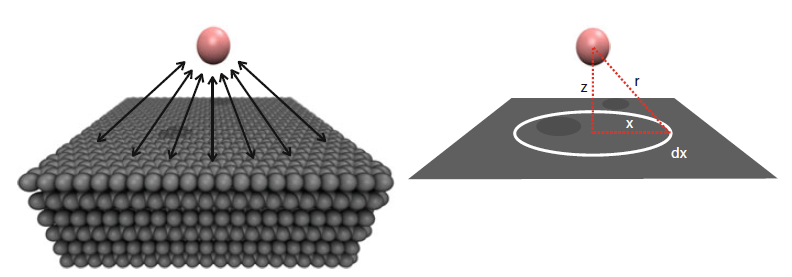

À esquerda, a molécula interage com muitos átomos distribuídos em camadas. À direita, substituímos a soma na camada por uma integração sobre anéis, com $r^2=z^2+x^2$ e elemento de área $2\pi x\,dx$. Integrar o LJ 12–6 no plano produz os termos **10–4**; a contribuição das camadas mais profundas é aproximada pelo termo **3**. Essa média lateral remove a corrugação atômica e produz $V_S(z)$.

Para carbono, o prefator é $\epsilon_w=2\pi\rho_s\Delta\epsilon_{sf}\sigma_{sf}^2$. A imagem foi fornecida pelo docente; a derivação é de [Steele, 1973](https://doi.org/10.1016/0039-6028(73)90264-1). Agora variaremos energia e tamanho para reconhecer seus efeitos no potencial.


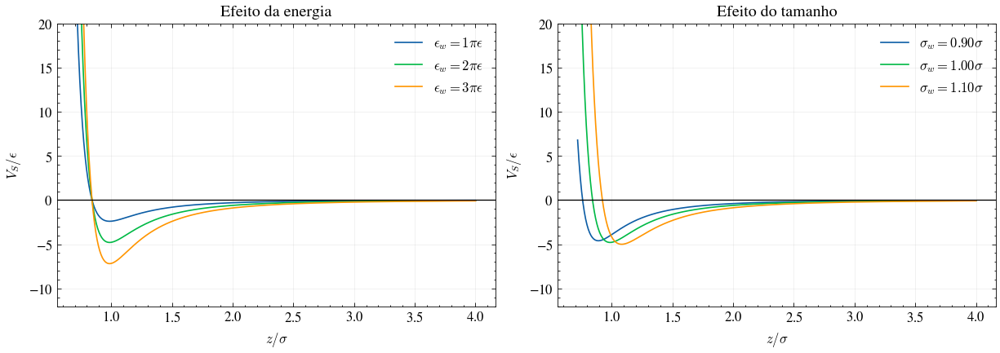

In [11]:
def steele(z, epsilon_w=2*np.pi, sigma_w=1.0, delta=1/np.sqrt(2)):
    return epsilon_w * (
        0.4 * (sigma_w/z)**10 - (sigma_w/z)**4
        - sigma_w**4 / (3*delta*(z + 0.61*delta)**3)
    )

z_teste = np.linspace(0.72, 4.0, 600)
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.6), constrained_layout=True)

for fator in [1.0, 2.0, 3.0]:
    ax[0].plot(z_teste, steele(z_teste, epsilon_w=fator*np.pi), label=fr"$\epsilon_w={fator:g}\pi\epsilon$")
for sigma_w in [0.90, 1.00, 1.10]:
    ax[1].plot(z_teste, steele(z_teste, sigma_w=sigma_w), label=fr"$\sigma_w={sigma_w:.2f}\sigma$")

for eixo in ax:
    eixo.axhline(0, color="k", lw=0.8)
    eixo.set(xlabel=r"$z/\sigma$", ylabel=r"$V_S/\epsilon$", ylim=(-12, 20))
    eixo.legend(frameon=False)
ax[0].set_title("Efeito da energia")
ax[1].set_title("Efeito do tamanho")
plt.show()


Construímos agora uma fenda isolada de suas imagens periódicas por regiões proibidas. A função será reutilizada ao trocar funcional e largura.


In [12]:
def criar_fenda(H, modelo="WBI+MMFA", dz=0.025):
    """Fenda 0<z<H, isolada das imagens periódicas por um buffer."""
    cutoff = buffer = 5.0
    s = DFT(functional=modelo, device=DEVICE_1D)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=cutoff)
    s.set_gridsize(gridsize=dz)
    s.set_geometry(lengths=H + 2*buffer)
    s._from_ase = False

    z = np.squeeze(s.X) - buffer
    dentro = (z > dz/2) & (z < H - dz/2)
    V = np.full_like(z, np.inf, dtype=np.float32)
    V[dentro] = steele(z[dentro]) + steele(H - z[dentro])

    s.set_external_potential(V.reshape(s.Ngrid))
    s.set_temperature(kT=1.2)
    s.set_bulk_density(rhob=0.5925)
    s.set_initial_condition(model="bulk")
    return s, z


Grid defined!
Lgrid = (np.float32(13.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 13.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (520, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.008125001  A³
Grid defined!
Lgrid = (np.float32(17.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (680, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.010625  A³
Grid defined!
Lgrid = (np.float32(30.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 30.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (1200, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.01875  A³


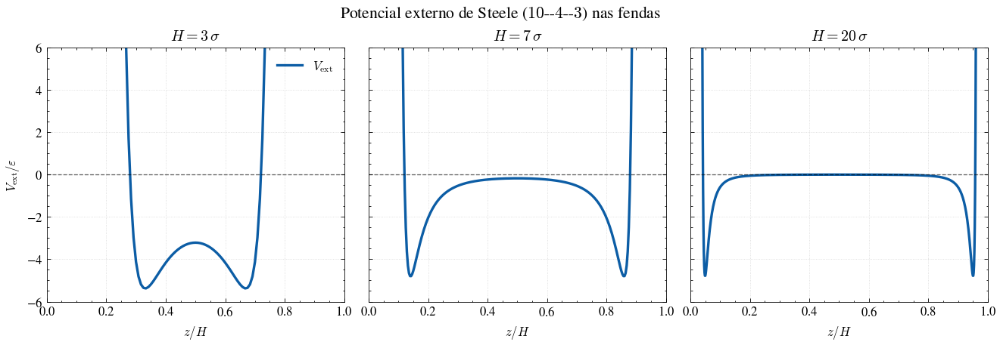

In [13]:
Hs = [3.0, 7, 20]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.8), constrained_layout=True, sharey=True)

for ax, H in zip(axes, Hs):
    s, z = criar_fenda(H)
    V = np.squeeze(s.Vext)

    # Select only the interior of the pore
    dentro = (z >= 0) & (z <= H)

    ax.plot(z[dentro] / H, V[dentro], color="C0", lw=2, label=r"$V_{\mathrm{ext}}$")

    ax.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
    ax.set(
        title=fr"$H = {H:g}\,\sigma$",
        xlabel=r"$z/H$",
        xlim=(0, 1),
        ylim=(-6.0, 6.0)
    )
    ax.grid(True, ls=":", alpha=0.5)

axes[0].set_ylabel(r"$V_{\mathrm{ext}} / \varepsilon$")
axes[0].legend(frameon=False)
fig.suptitle(r"Potencial externo de Steele ($10\text{--}4\text{--}3$) nas fendas", fontsize=13)

plt.savefig("v6_potencial_por_largura.png", dpi=220, bbox_inches="tight")
plt.show()

## 7. MFA, WDA e MMFA versus GCMC — um único gráfico

Mudaremos apenas `functional`: a geometria, o reservatório e o potencial serão os mesmos.

A fenda tem picos intensos de densidade. Começar Anderson diretamente do bulk pode produzir um passo excessivo. Por isso fazemos duas etapas explícitas: **FIRE com passo pequeno aproxima o perfil; Anderson termina a solução**. O perfil final deve satisfazer `atol=1e-8`, `rtol=1e-4` para todos os modelos — não relaxamos a tolerância para incluir MFA.

FIRE nessa primeira etapa é uma preparação e não precisa já ter convergido. A tabela registra as iterações das duas etapas e o erro final de Anderson.


**Sobre a origem dos pontos:** o cabeçalho dos arquivos do repositório cita [Snook & van Megen, *Solvation forces in simple dense fluids. I*, 1980](https://doi.org/10.1063/1.439489), que utiliza Monte Carlo no ensemble grande-canônico (**GCMC**). O sufixo `GEMC` foi mantido nos nomes dos arquivos por compatibilidade; não significa Gibbs Ensemble Monte Carlo nesse conjunto. O exemplo original também os legenda apenas como “MC”.


In [14]:
modelos = ["WBI+MFA", "WBI+WDA", "WBI+MMFA"]
solucoes, linhas = {}, []

for modelo in modelos:
    s, z = criar_fenda(H=7.5, modelo=modelo)
    inicio = time.perf_counter()

    # 1. Aproximação conservadora: evita o salto inicial para densidades excessivas.
    fire = Optimizer.create(
        "fire", s, mode="fire", dt=0.002, dt_max=0.02,
        atol=1e-8, rtol=1e-4, max_iter=3000,
    )
    fire.run()

    # 2. Correção final, sem reinicializar a densidade preparada por FIRE.
    opt = Optimizer.create(
        "anderson", s, alpha=0.10, regularization=1e-6,
        atol=1e-8, rtol=1e-4, max_iter=15000,
    )
    erro, n_iter = opt.run()
    linhas.append([modelo, fire.Niter, n_iter, time.perf_counter()-inicio, erro, opt.converged])
    if not opt.converged:
        raise RuntimeError(f"{modelo} não convergiu: Erro={erro:.3e}; {opt.stop_reason}")
    solucoes[modelo] = (s, z)

convergencia_1d = pd.DataFrame(
    linhas, columns=["Funcional", "Iterações FIRE", "Iterações Anderson", "Tempo (s)", "Erro", "Convergiu"]
)
display(convergencia_1d.style.format({"Tempo (s)": "{:.3f}", "Erro": "{:.2e}"}))


Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³
Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³
Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³


,Funcional,Iterações FIRE,Iterações Anderson,Tempo (s),Erro,Convergiu
0,WBI+MFA,3000,5,9.325,5.50e-01,True
1,WBI+WDA,937,3,6.080,9.37e-01,True
2,WBI+MMFA,1967,80,13.618,9.02e-01,True


Carregamos os pontos de GCMC e desenhamos os três perfis convergidos em um único gráfico. O sufixo histórico do arquivo permanece inalterado.


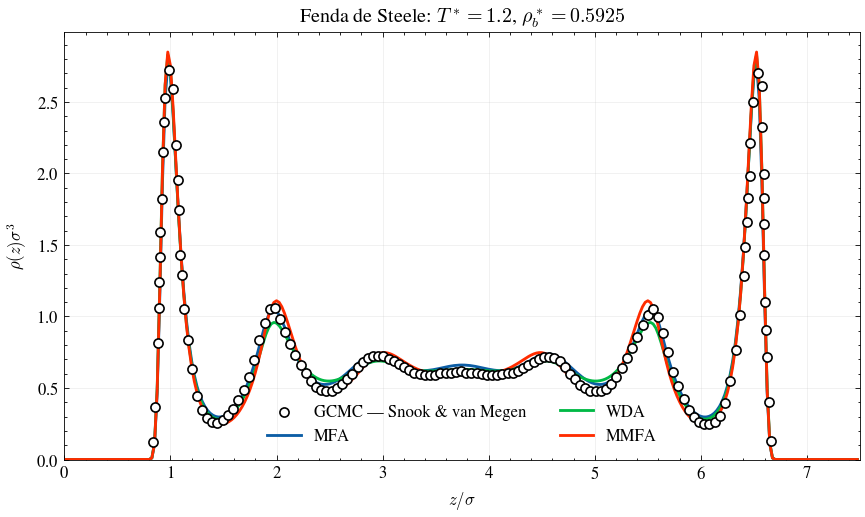

In [15]:
arquivo_mc = dados / "lj-slitpore-steele-H7.5-GEMC.dat"
if not arquivo_mc.exists():
    urlretrieve(
        f"{RAW}/examples/data/MC/lj-slitpore-steele-T1.2-rhob0.5925-H7.5-GEMC.dat",
        arquivo_mc,
    )
mc = np.loadtxt(arquivo_mc)

fig, ax = plt.subplots(figsize=(7.2, 4.3), constrained_layout=True)
ax.scatter(mc[:, 0], mc[:, 1], s=30, facecolors="white", edgecolors="k", label="GCMC — Snook & van Megen", zorder=4)

cores = {"WBI+MFA": "C0", "WBI+WDA": "C1", "WBI+MMFA": "C3"}
for modelo, (s, z) in solucoes.items():
    dentro = (z >= 0) & (z <= 7.5)
    rho_z = np.squeeze(s.rho.detach().cpu().numpy())
    ax.plot(z[dentro], rho_z[dentro], color=cores[modelo], lw=1.7,
            label=modelo.split("+")[1])

ax.set(xlabel=r"$z/\sigma$", ylabel=r"$\rho(z)\sigma^3$",
       xlim=(0, 7.5), ylim=(0, None), title=r"Fenda de Steele: $T^*=1.2$, $\rho_b^*=0.5925$")
ax.legend(frameon=False, ncol=2)
plt.savefig("v6_Steele_modelos_GCMC.png", dpi=220, bbox_inches="tight")
plt.show()


## 8. O centro do poro é bulk?

Não necessariamente. As paredes e as correlações podem atravessar todo o poro. Para tornar a tendência legível, usamos sete larguras entre $3\sigma$ e $12\sigma$ e mostramos quatro perfis representativos.

Os casos $H=1.8\sigma$ e $2.0\sigma$ ficam fora do percurso principal: nesta versão, a combinação de confinamento extremo, FMT singular próximo de $n_3=1$ e precisão `float32` pode exigir continuação e salvaguardas que desviariam o foco da aula. Isso é uma limitação numérica explícita, não um resultado físico.


In [16]:
larguras = [3.0, 4.0, 5.0, 6.0, 7.5, 9.0, 12.0]
perfis, resumo = {}, []

for H in larguras:
    s, z = criar_fenda(H, modelo="WBI+MMFA")
    # O mesmo procedimento em duas etapas do estudo anterior.
    fire = Optimizer.create("fire", s, mode="fire", dt=0.002, dt_max=0.02,
                            atol=1e-8, rtol=1e-4, max_iter=3000)
    fire.run()
    opt = Optimizer.create("anderson", s, alpha=0.10, regularization=1e-6,
                           atol=1e-8, rtol=1e-4, max_iter=15000)
    erro, n_iter = opt.run()
    if not opt.converged:
        raise RuntimeError(f"H={H:g}: Erro={erro:.3e}; {opt.stop_reason}")

    rho_z = np.squeeze(s.rho.detach().cpu().numpy())
    perfis[H] = (z, rho_z)
    rho_centro = float(np.interp(H/2, z, rho_z))
    resumo.append([H, rho_centro, rho_centro/float(s.rhob), fire.Niter+n_iter])

centro = pd.DataFrame(resumo, columns=["H/sigma", "Densidade central", "Razão centro/bulk", "Iterações"])
display(centro.style.format({"Densidade central": "{:.5f}", "Razão centro/bulk": "{:.3f}"}))


Grid defined!
Lgrid = (np.float32(13.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 13.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (520, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.008125001  A³
Grid defined!
Lgrid = (np.float32(14.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 14.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (560, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.00875  A³
Grid defined!
Lgrid = (np.float32(15.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 15.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (600, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.009375  A³
Grid defined!
Lgrid = (np.float32(16.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 16.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (640, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.010000001  A³
Gri

,H/sigma,Densidade central,Razão centro/bulk,Iterações
0,3.000000,0.08985,0.152,327
1,4.000000,1.78580,3.014,349
2,5.000000,0.32235,0.544,417
3,6.000000,0.96947,1.636,666
4,7.500000,0.59922,1.011,2042
5,9.000000,0.56862,0.960,3086
6,12.000000,0.61366,1.036,380


Compararemos quatro perfis na coordenada z/H. Acrescentamos GCMC em H/σ = 3, 4 e 7,5; não há arquivo equivalente para H/σ = 12 no conjunto utilizado.


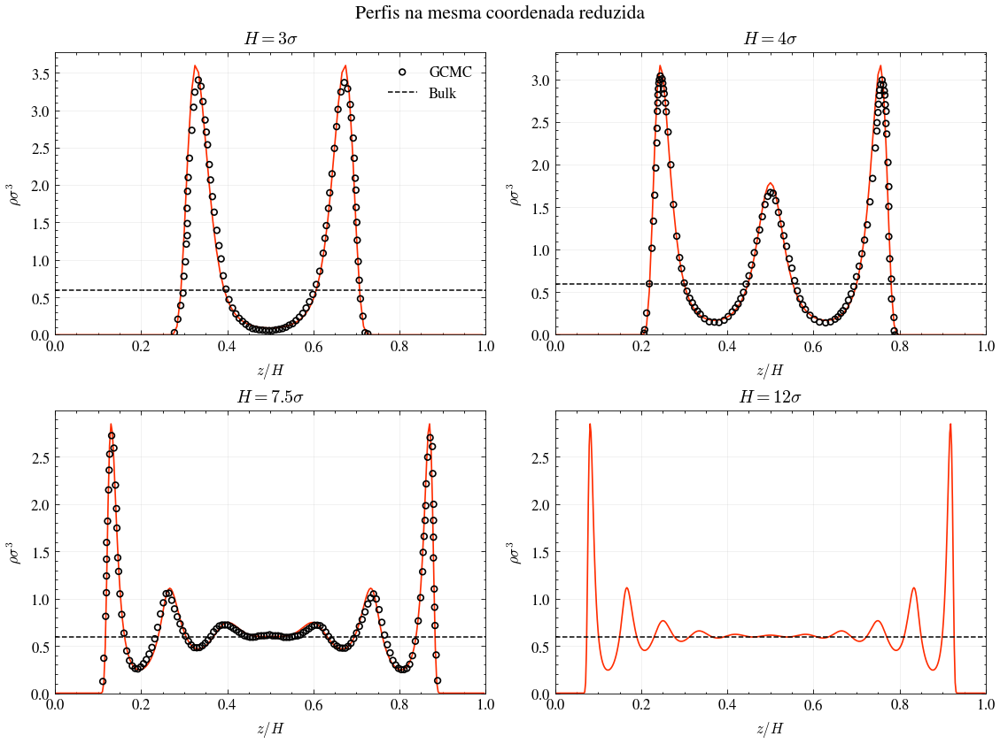

In [17]:
# Há pontos de GCMC para estas larguras na mesma condição termodinâmica.
mc_por_H = {}
for H in [3.0, 4.0, 7.5]:
    nome = f"lj-slitpore-steele-T1.2-rhob0.5925-H{H:.1f}-GEMC.dat"
    arquivo = dados / nome
    if not arquivo.exists():
        urlretrieve(f"{RAW}/examples/data/MC/{nome}", arquivo)
    mc_por_H[H] = np.loadtxt(arquivo)

fig, axes = plt.subplots(2, 2, figsize=(9.4, 7.0), constrained_layout=True)
for ax, H in zip(axes.flat, [3.0, 4.0, 7.5, 12.0]):
    z, rho_z = perfis[H]
    dentro = (z >= 0) & (z <= H)
    ax.plot(z[dentro]/H, rho_z[dentro], color="C3")
    if H in mc_por_H:
        mc = mc_por_H[H]
        ax.scatter(mc[:, 0]/H, mc[:, 1], s=16, facecolors="none",
                   edgecolors="k", label="GCMC", zorder=3)
    ax.axhline(0.5925, color="k", ls="--", lw=0.9, label="Bulk")
    ax.set(title=fr"$H={H:g}\sigma$", xlabel=r"$z/H$", ylabel=r"$\rho\sigma^3$",
           xlim=(0, 1), ylim=(0, None))
axes[0, 0].legend(frameon=False)
fig.suptitle("Perfis na mesma coordenada reduzida", fontsize=13)
plt.savefig("v6_perfis_por_largura.png", dpi=220, bbox_inches="tight")
plt.show()


O gráfico seguinte acompanha a densidade central relativa ao bulk. A aproximação pode oscilar com o número de camadas; não esperamos uma tendência monotônica.


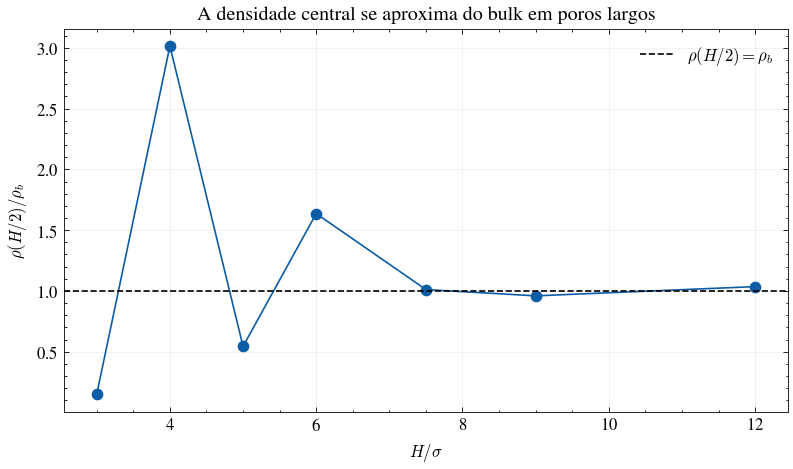

In [18]:
fig, ax = plt.subplots(figsize=(6.6, 3.9), constrained_layout=True)
ax.plot(centro["H/sigma"], centro["Razão centro/bulk"], "o-", color="C0")
ax.axhline(1, color="k", ls="--", lw=1, label=r"$\rho(H/2)=\rho_b$")
ax.set(xlabel=r"$H/\sigma$", ylabel=r"$\rho(H/2)/\rho_b$",
       title="A densidade central se aproxima do bulk em poros largos")
ax.legend(frameon=False)
plt.show()


### 8.1 Checkpoint 1D

Você já sabe trocar o funcional, alterar o potencial de parede, configurar o solver e verificar convergência. Para adaptar o exemplo, mude **uma escolha por vez** e guarde o benchmark anterior.


## 9. Isoterma 1D: N₂ em carbono a 100 K e histerese

Aqui uma isoterma deixa de ser uma lista de cálculos independentes. Seguiremos o perfil convergido ao **aumentar** a pressão e, depois, ao **diminuí-la**. Mínimos locais diferentes podem produzir um laço de histerese.

Usamos um N₂ **efetivo de um sítio**, sem orientação nem quadrupolo. Parâmetros: $\sigma=3{,}615$ Å, $\epsilon/k_B=101{,}5$ K; cruzamentos com carbono $\sigma_{sf}=3{,}494$ Å, $\epsilon_{sf}/k_B=53{,}22$ K, $\rho_s=0{,}114$ Å⁻³ e $\Delta=3{,}35$ Å. São os parâmetros LJ–MC discutidos por [Ravikovitch et al., Langmuir (2000), Tabela 1](https://doi.org/10.1021/la991011c), empregados aqui com o funcional do PyDFTlj — não uma reprodução da NLDFT daquele artigo.

Escolhemos $H=7{,}5\sigma$, dentro da faixa sugerida. O modelo serve para discutir preenchimento capilar; calibração quantitativa de N₂ real requer validação adicional.



### 9.1 O reservatório abaixo da temperatura crítica

A EOS pode ter múltiplas densidades para a mesma pressão. Primeiro determinaremos coexistência por $\mu(\rho_v,T)=\mu(\rho_l,T)$ e $P(\rho_v,T)=P(\rho_l,T)$. Na varredura, a raiz será sempre buscada **no ramo vapor**, abaixo de $P_{sat}$.


In [19]:
from scipy.optimize import root, brentq

sigma, epsilon, T = 3.615, 101.5, 100.0  # N2 efetivo: Å, K, K
eos_n2 = LJEOS(sigma=sigma, epsilon=epsilon)

def coexistencia(x):
    rv, rl = torch.tensor(x/sigma**3, dtype=torch.float64)
    return [float(eos_n2.mu(rv, T)-eos_n2.mu(rl, T))/epsilon,
            float(eos_n2.p(rv, T)-eos_n2.p(rl, T))*sigma**3/epsilon]

elv = root(coexistencia, np.array([0.02, 0.72]))  # Chutes de densidade reduzida.
rho_v, rho_l = elv.x / sigma**3
if not elv.success or not 0 < rho_v < rho_l:
    raise RuntimeError("A coexistência bulk não foi encontrada; reveja os chutes.")
psat = float(eos_n2.p(torch.tensor(rho_v, dtype=torch.float64), T)) * K_A3_para_bar
print(f"Psat do modelo: {psat:.4f} bar; T* = {T/epsilon:.4f}")
print(f"Densidades reduzidas: vapor = {rho_v*sigma**3:.5f}; líquido = {rho_l*sigma**3:.5f}")


Psat do modelo: 6.6538 bar; T* = 0.9852
Densidades reduzidas: vapor = 0.02653; líquido = 0.71072


Construiremos a fenda em unidades dimensionais. O potencial de cada parede usa os parâmetros cruzados de N₂–carbono. O buffer isola as imagens periódicas, como no exemplo reduzido.

**Para caber na aula:** calculamos somente 1–3 bar, com refinamento local entre 1,725 e 1,975 bar. Mantemos a malha espacial, o funcional e a tolerância. A varredura anterior tinha 89 pressões; agora são 30. Picard usa `alpha=0.03` (antes 0,02), validado neste caso, e continua a solução anterior. Isso reduz trabalho sem trocar o procedimento de seguir mínimos locais por um solver que possa mudar de ramo. Para estudo quantitativo, refine a pressão junto aos saltos e ao cruzamento de Ω.


In [20]:
H = 7.5 * sigma      # Distância entre planos externos de carbono.
buffer = 5 * sigma
n2 = DFT(functional="aWBI+MMFA", device=DEVICE_1D)
n2.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=28.0134, cut_off=5*sigma)
n2.set_gridsize(0.04*sigma)
n2.set_geometry(lengths=H + 2*buffer)
n2._from_ase = False
z = np.squeeze(n2.X) - buffer

sigma_sf, epsilon_sf = 3.494, 53.22
delta, rho_s = 3.35, 0.114
prefator = 2*np.pi*rho_s*delta*epsilon_sf*sigma_sf**2
dentro = (z > 0.02*sigma) & (z < H - 0.02*sigma)
V = np.full_like(z, np.inf)
V[dentro] = (steele(z[dentro], prefator, sigma_sf, delta)
              + steele(H-z[dentro], prefator, sigma_sf, delta))
n2.set_external_potential(V.reshape(n2.Ngrid))
n2.set_temperature(T)

# Modo aula: apenas 1–3 bar; mais pontos na região de histerese.
p_n2 = np.unique(np.round(np.r_[np.linspace(1.0, 3.0, 21),
                               np.arange(1.725, 1.976, 0.025)], 6))
if not np.all((p_n2 > 0) & (p_n2 < psat)):
    raise ValueError("A faixa de pressão deve permanecer no ramo vapor abaixo de Psat.")
print(f"{len(p_n2)} pressões; {2*len(p_n2)} estados nas duas varreduras")
rho_reservatorio = np.array([
    brentq(lambda r: float(eos_n2.p(torch.tensor(r, dtype=torch.float64), T))
                     * K_A3_para_bar - p, 1e-12, rho_v)
    for p in p_n2
])


Grid defined!
Lgrid = (np.float32(63.2625), np.float32(0.1446), np.float32(0.1446))  A
X-axis = [ 0.0 , 63.2625 ] A
Y-axis = [ 0.0 , 0.1446 ] A
Z-axis = [ 0.0 , 0.1446 ] A
Number of gridpoints = (438, 1, 1)
delta =  [0.1446 0.1446 0.1446]  A
Vol = 1.3227658  A³
30 pressões; 60 estados nas duas varreduras


### 9.2 Dois sentidos de varredura

Usaremos Picard com mistura pequena para acompanhar cada ramo local. A adsorção começa diluída; a dessorção começa com um chute denso na maior pressão. O reservatório **continua sendo vapor** nas duas varreduras: o chute líquido é apenas uma densidade inicial dentro do poro.

Em 1D, reportamos $\Gamma=N/A= \int\rho(z)dz$ em moléculas/nm² e $\beta\Omega\sigma^2/A$. A área numérica é `dV/delta[0]`; dividir por ela elimina a espessura transversal artificial do objeto 1D. O excesso usa o volume geométrico AH, explicitamente.


In [21]:
ramos = []
inicio_isoterma = time.perf_counter()
for nome, indices, chute in [
    ("Adsorção", range(len(p_n2)), 1e-6),
    ("Dessorção", range(len(p_n2)-1, -1, -1), rho_l),
]:
    n2.set_bulk_density(chute)
    n2.set_initial_condition("bulk")
    for passo, j in enumerate(indices, start=1):
        n2.set_bulk_density(rho_reservatorio[j])
        n2.update_system()
        opt = Optimizer.create("picard", n2, alpha=0.03,
                               atol=1e-8, rtol=1e-4, max_iter=18000)
        opt.run()
        if not opt.converged:
            raise RuntimeError(f"{nome}, P={p_n2[j]:.4f} bar: {opt.stop_reason}")
        if passo == 1 or passo % 5 == 0 or passo == len(p_n2):
            print(f"{nome}: {passo}/{len(p_n2)} · P={p_n2[j]:.3f} bar · {opt.Niter} iterações", flush=True)
        area = float(n2.dV/n2.delta[0])
        gamma = float(n2.Nabs)/area
        omega = float(n2.Omega)*sigma**2/(T*area)
        ramos.append([nome, p_n2[j], gamma*100,
                      (gamma-rho_reservatorio[j]*H)*100, omega, opt.Niter, opt.error])

iso_n2 = pd.DataFrame(ramos, columns=["Ramo", "Pressão (bar)", "N/A (nm⁻²)",
                                     "Excesso/A (nm⁻²)", "Omega reduzido por área", "Iterações", "Erro"])
iso_n2.to_csv("v6_isoterma_N2_100K.csv", index=False)
display(iso_n2.groupby("Ramo").agg(Pontos=("Erro", "size"), Erro_maximo=("Erro", "max")))

print(f"Tempo total: {time.perf_counter()-inicio_isoterma:.1f} s")


Adsorção: 1/30 · P=1.000 bar · 488 iterações
Adsorção: 5/30 · P=1.400 bar · 271 iterações
Adsorção: 10/30 · P=1.750 bar · 250 iterações
Adsorção: 15/30 · P=1.875 bar · 333 iterações
Adsorção: 20/30 · P=2.000 bar · 3135 iterações
Adsorção: 25/30 · P=2.500 bar · 137 iterações
Adsorção: 30/30 · P=3.000 bar · 119 iterações
Dessorção: 1/30 · P=3.000 bar · 395 iterações
Dessorção: 5/30 · P=2.600 bar · 130 iterações
Dessorção: 10/30 · P=2.100 bar · 153 iterações
Dessorção: 15/30 · P=1.900 bar · 106 iterações
Dessorção: 20/30 · P=1.775 bar · 194 iterações
Dessorção: 25/30 · P=1.500 bar · 284 iterações
Dessorção: 30/30 · P=1.000 bar · 278 iterações


,Pontos,Erro_maximo
Ramo,,
Adsorção,30,0.999488
Dessorção,30,0.999335


Tempo total: 127.3 s


### 9.3 Qual dos perfis é mais estável?

Na mesma pressão, temperatura, geometria e convenção de μ, comparamos Ω das duas soluções convergidas. A menor Ω identifica a mais estável **entre as soluções encontradas**. Coexistência requer igualdade de Ω; o salto de uma varredura marca perda de persistência do ramo e não determina sozinho a pressão de equilíbrio.

Vamos mostrar a isoterma, Ω versus pressão e a diferença $\Omega_{des}-\Omega_{ads}$. A diferença facilita ver o cruzamento das curvas. A resolução em pressão e a tolerância devem ser refinadas perto dele.


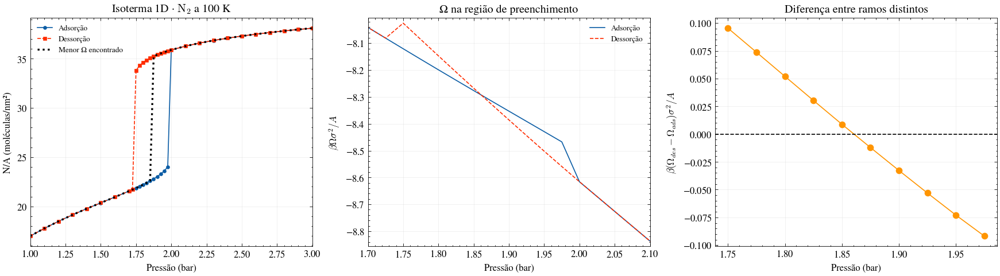

Cruzamento estimado: 1.8606 bar (P/Psat = 0.2796)


In [22]:
ads = iso_n2.query("Ramo == 'Adsorção'").sort_values("Pressão (bar)")
des = iso_n2.query("Ramo == 'Dessorção'").sort_values("Pressão (bar)")
p = ads["Pressão (bar)"].to_numpy()
g_ads, g_des = ads["N/A (nm⁻²)"].to_numpy(), des["N/A (nm⁻²)"].to_numpy()
w_ads = ads["Omega reduzido por área"].to_numpy()
w_des = des["Omega reduzido por área"].to_numpy()
distintos = np.abs(g_des-g_ads) > 0.1
delta_omega = w_des-w_ads

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4), constrained_layout=True)
ax[0].plot(p, g_ads, "o-", ms=3, label="Adsorção", color="C0")
ax[0].plot(p, g_des, "s--", ms=3, label="Dessorção", color="C3")
ax[0].plot(p, np.where(w_ads <= w_des, g_ads, g_des), "k:", lw=2, label="Menor Ω encontrado")
ax[0].set(ylabel="N/A (moléculas/nm²)", title=r"Isoterma 1D · $\mathrm{N_2}$ a 100 K", xlim=(1, 3))
ax[1].plot(p, w_ads, color="C0", label="Adsorção")
ax[1].plot(p, w_des, "--", color="C3", label="Dessorção")
ax[1].set(ylabel=r"$\beta\Omega\sigma^2/A$", title="Potencial grande-canônico")
zoom = (p/psat >= 0.25) & (p/psat <= 0.32)
ax[1].set_xlim(p[zoom].min(), p[zoom].max())
ax[1].set_ylim(min(w_ads[zoom].min(), w_des[zoom].min())-0.02,
               max(w_ads[zoom].max(), w_des[zoom].max())+0.02)
ax[1].set_title("Ω na região de preenchimento")
ax[2].plot(p[distintos], delta_omega[distintos], "o-", color="C2")
ax[2].axhline(0, color="k", ls="--", lw=1)
ax[2].set(ylabel=r"$\beta(\Omega_{des}-\Omega_{ads})\sigma^2/A$", title="Diferença entre ramos distintos")
for eixo in ax:
    eixo.set_xlabel("Pressão (bar)")
for eixo in ax[:2]: eixo.legend(frameon=False, fontsize=8)
plt.savefig("v6_histerese_N2.png", dpi=220, bbox_inches="tight")
plt.show()

cruza = np.flatnonzero(distintos[:-1] & distintos[1:] & (delta_omega[:-1]*delta_omega[1:] < 0))
for j in cruza:
    p_eq = p[j] - delta_omega[j]*(p[j+1]-p[j])/(delta_omega[j+1]-delta_omega[j])
    print(f"Cruzamento estimado: {p_eq:.4f} bar (P/Psat = {p_eq/psat:.4f})")
if not len(cruza):
    print("Nenhum cruzamento resolvido entre ramos distintos; refine pressão/tolerância antes de concluir.")


# Exercício 2: Isotermas de Adsorção e Condensação Capilar de Argônio ($\text{Ar}$) a $87\text{ K}$

#### Objetivo
Calcular as isotermas completas de adsorção e dessorção de argônio gasoso ($\text{Ar}$) a $T = 87\text{ K}$ em fendas de largura reduzida $H = 4\,\sigma$ e $H = 10\,\sigma$ na faixa de pressões de baixas pressões até $1\text{ bar}$.

A partir dos perfis de densidade e das curvas termodinâmicas, deve-se:
1. **Traçar as Isotermas de Adsorção e Dessorção:** Identificar os ramos metaestáveis gerados pelo algoritmo de continuação (continuação a partir do estado rarefeito para adsorção e do estado condensado para dessorção).
2. **Utilizar o Potencial Grand Canônico para determinar a isoterma de equilíbrio**
3. **Comparar o Efeito do Confinamento ($H = 4\,\sigma$ vs. $H = 10\,\sigma$):** Analisar como a abertura do poro altera a largura do laço de histerese e a magnitude da queda da pressão de condensação em relação à saturação no seio (*bulk*).

---

#### Procedimento Sugerido
- **Varredura de Pressão:** Construa uma malha fina de pressões na região da transição capilar para garantir boa resolução no cruzamento de $\Omega$.
- **Critério de Equilíbrio:** A transição de primeira ordem verdadeira ocorre no ponto em que $\Omega_{\mathrm{ads}}(P) = \Omega_{\mathrm{des}}(P)$.
- **Gráficos esperados para cada $H$ (em 3 painéis):**
  - **Painel 1:** Isoterma $N/A$ (ou $\Gamma$) vs. $P$, destacando os ramos de adsorção, dessorção e a linha vertical de transição termodinâmica (menor $\Omega$).
  - **Painel 2:** Grande potencial grand-canônico reduzido $\beta\Omega\sigma^2/A$ na vizinhança da condensação capilar.
  - **Painel 3:** Diferença entre ramos $\Delta\Omega = \beta(\Omega_{\mathrm{des}} - \Omega_{\mathrm{ads}})\sigma^2/A$ vs. $P$, destacando o ponto em que cruza zero.

**Dados complementares para execução:** use o Ar LJ do Exercício 1, carbono Steele (σC=3,4 Å; εC/kB=28 K), regra Lorentz–Berthelot, densidade do sólido 0,114 Å⁻³ e Δ=3,35 Å. Calcule Psat pela EOS adotada: se ela for menor que 1 bar, diferencie explicitamente o vapor metaestável acima de Psat. A comparação de Ω é entre os estados encontrados no mesmo reservatório.

#### Gabarito 2 — início do bloco removível

**Pré-requisitos:** importações, fatores de conversão e função `steele()` da seção 6. Tags: `gabarito`, `exercicio-2`.

Complementamos os dados necessários: Ar com σ=3,405 Å, ε/kB=119,8 K; carbono Steele com σC=3,4 Å, εC/kB=28 K, densidade 0,114 Å⁻³ e distância entre camadas Δ=3,35 Å. Os parâmetros cruzados seguem Lorentz–Berthelot. Esta é uma escolha explícita de modelo de parede, não uma propriedade universal de “carbono”.

Primeiro determinaremos **Psat da mesma EOS** e a spinodal do vapor. Para este Ar LJ, Psat em 87 K é cerca de 0,794 bar, menor que o limite solicitado de 1 bar. Conservaremos o ramo vapor até 1 bar para completar a varredura; acima de Psat, o reservatório é **metaestável**. A isoterma global em equilíbrio com o bulk exigiria trocar para a raiz líquida. Essa troca de reservatório não deve ser confundida com a histerese do poro.

In [23]:
from scipy.optimize import root, brentq

sig_ar, eps_ar, T_ar = 3.405, 119.8, 87.0
eos_ar = LJEOS(sigma=sig_ar, epsilon=eps_ar)

def coexistencia_ar(x):
    v, l = torch.tensor(x/sig_ar**3, dtype=torch.float64)
    return [float(eos_ar.mu(v, T_ar)-eos_ar.mu(l, T_ar))/eps_ar,
            float(eos_ar.p(v, T_ar)-eos_ar.p(l, T_ar))*sig_ar**3/eps_ar]

elv_ar = root(coexistencia_ar, np.array([0.002, 0.83]))
rv_ar, rl_ar = elv_ar.x/sig_ar**3
if not elv_ar.success or not 0 < rv_ar < rl_ar:
    raise RuntimeError("Não foi possível determinar a coexistência do Ar.")
psat_ar = float(eos_ar.p(torch.tensor(rv_ar, dtype=torch.float64), T_ar))*K_A3_para_bar
spin_ar = brentq(lambda r: float(eos_ar.dpdrho(torch.tensor(r, dtype=torch.float64), T_ar)),
                 rv_ar, 0.10/sig_ar**3)
p_spin_ar = float(eos_ar.p(torch.tensor(spin_ar, dtype=torch.float64), T_ar))*K_A3_para_bar
print(f"Psat = {psat_ar:.5f} bar; limite da raiz vapor = {p_spin_ar:.3f} bar")

# Escala logarítmica resolve o preenchimento do poro estreito em baixas pressões.
p_ar = np.unique(np.r_[np.geomspace(1e-4, 0.1, 35), np.linspace(0.1, 1.0, 46)])
rb_ar = np.array([brentq(
    lambda r: float(eos_ar.p(torch.tensor(r, dtype=torch.float64), T_ar))*K_A3_para_bar-p,
    1e-14, spin_ar) for p in p_ar])

Psat = 0.79388 bar; limite da raiz vapor = 8.230 bar


A função abaixo monta as duas fendas com o mesmo fluido e campo de força. Apenas H muda. O buffer de 5σ em cada lado separa as imagens periódicas; o passo espacial é 0,04σ. O eixo longitudinal interno é `X`, mesmo que o chamemos de z no problema físico.

In [24]:
def criar_fenda_ar(largura):
    ar = DFT(functional="aWBI+MMFA", device=DEVICE_1D)
    ar.set_fluid_properties(sigma=sig_ar, epsilon=eps_ar, mass=39.948, cut_off=5*sig_ar)
    ar.set_gridsize(0.04*sig_ar)
    ar.set_geometry((largura+10)*sig_ar)
    ar._from_ase = False
    z = ar.X.squeeze()-5*sig_ar
    H = largura*sig_ar
    dentro = (z > 0.02*sig_ar) & (z < H-0.02*sig_ar)
    sig_sf, eps_sf = (sig_ar+3.4)/2, np.sqrt(eps_ar*28.0)
    prefator = 2*np.pi*0.114*3.35*eps_sf*sig_sf**2
    V = np.full_like(z, np.inf)
    V[dentro] = (steele(z[dentro], prefator, sig_sf, 3.35)
                  + steele(H-z[dentro], prefator, sig_sf, 3.35))
    ar.set_external_potential(V.reshape(ar.Ngrid))
    ar.set_temperature(T_ar)
    return ar

Percorremos as mesmas pressões nos dois sentidos. O chute denso da dessorção não muda a raiz vapor do reservatório. Picard com mistura pequena acompanha os mínimos locais; todos os estados precisam satisfazer o critério de convergência antes de serem guardados. O cálculo pode levar alguns minutos.

Além de Γ e Ω, guardamos perfis em pressões selecionadas. Para cada largura, a área numérica é a mesma nas duas varreduras, permitindo comparar $\beta\Omega\sigma^2/A$.

In [25]:
linhas_ar, perfis_ar = [], {}
for largura in [4.0, 10.0]:
    ar = criar_fenda_ar(largura)
    guardar = {int(np.argmin(abs(p_ar-p))) for p in [0.001, 0.1, 1.0]}
    for ramo, indices, chute in [
        ("Adsorção", range(len(p_ar)), 1e-10),
        ("Dessorção", range(len(p_ar)-1, -1, -1), rl_ar),
    ]:
        ar.set_bulk_density(chute)
        ar.set_initial_condition("bulk")
        for j in indices:
            ar.set_bulk_density(rb_ar[j])
            ar.update_system()
            opt_ar = Optimizer.create("picard", ar, alpha=0.01,
                                     atol=1e-8, rtol=1e-4, max_iter=20000)
            opt_ar.run()
            if not opt_ar.converged:
                raise RuntimeError(f"Ar, H={largura:g}σ, P={p_ar[j]:.5g}: {opt_ar.stop_reason}")
            area = float(ar.dV/ar.delta[0])
            linhas_ar.append([largura, ramo, p_ar[j], float(ar.Nabs)/area*100,
                float(ar.Omega)*sig_ar**2/(T_ar*area), opt_ar.Niter, opt_ar.error])
            if j in guardar:
                perfis_ar[largura, ramo, j] = ar.rho.detach().cpu().numpy().squeeze().copy()
        print(f"H={largura:g}σ · {ramo}: {len(p_ar)} estados convergidos", flush=True)

iso_ar = pd.DataFrame(linhas_ar, columns=["H/σ", "Ramo", "Pressão (bar)", "Γ (nm⁻²)",
                                        "Ω reduzido por área", "Iterações", "Erro"])
iso_ar.to_csv("ex2_Ar_87K_isotermas.csv", index=False)
display(iso_ar.groupby(["H/σ", "Ramo"]).agg(Pontos=("Erro", "size"), Erro_máximo=("Erro", "max")))

Grid defined!
Lgrid = (np.float32(47.67), np.float32(0.1362), np.float32(0.1362))  A
X-axis = [ 0.0 , 47.67 ] A
Y-axis = [ 0.0 , 0.1362 ] A
Z-axis = [ 0.0 , 0.1362 ] A
Number of gridpoints = (350, 1, 1)
delta =  [0.1362 0.1362 0.1362]  A
Vol = 0.88429934  A³
H=4σ · Adsorção: 80 estados convergidos
H=4σ · Dessorção: 80 estados convergidos
Grid defined!
Lgrid = (np.float32(68.1), np.float32(0.1362), np.float32(0.1362))  A
X-axis = [ 0.0 , 68.1 ] A
Y-axis = [ 0.0 , 0.1362 ] A
Z-axis = [ 0.0 , 0.1362 ] A
Number of gridpoints = (500, 1, 1)
delta =  [0.1362 0.1362 0.1362]  A
Vol = 1.2632849  A³
H=10σ · Adsorção: 80 estados convergidos
H=10σ · Dessorção: 80 estados convergidos


Pontos  Erro_máximo
H/σ  Ramo                          
4.0  Adsorção       80     0.999734
     Dessorção      80     0.999253
10.0 Adsorção       80     0.999959
     Dessorção      80     0.999892

Para selecionar o ramo de menor Ω, comparamos os estados na **mesma pressão**. Só procuramos cruzamentos onde os perfis têm ocupações distintas (diferença de Γ maior que 0,05 nm⁻²); isso evita classificar ruído entre soluções praticamente iguais como uma transição. Uma mudança de sinal precisa de dois pontos consecutivos com dois ramos distintos.

O cruzamento é interpolado em ln P. É uma estimativa entre pontos: refine a malha de pressão e a tolerância para obter um valor quantitativo. Podem existir múltiplos saltos, incluindo transições de camadas no poro estreito.

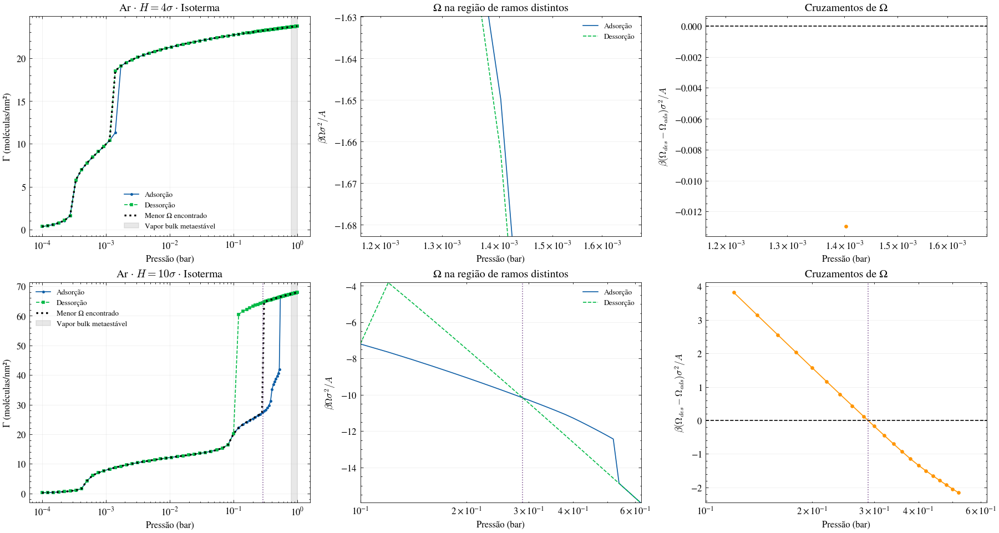

,H/σ,P estimada (bar),P/Psat,P inferior (bar),P superior (bar)
0,10.0,0.288152,0.362969,0.28,0.3


In [26]:
transicoes_ar = []
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, largura in zip(axes, [4.0, 10.0]):
    tabela = iso_ar[iso_ar["H/σ"] == largura]
    a = tabela[tabela["Ramo"] == "Adsorção"].sort_values("Pressão (bar)")
    d = tabela[tabela["Ramo"] == "Dessorção"].sort_values("Pressão (bar)")
    ga, gd = a["Γ (nm⁻²)"].to_numpy(), d["Γ (nm⁻²)"].to_numpy()
    wa, wd = a["Ω reduzido por área"].to_numpy(), d["Ω reduzido por área"].to_numpy()
    dw = wd-wa
    distintos = abs(gd-ga) > 0.05
    ax[0].plot(p_ar, ga, "o-", ms=2, label="Adsorção")
    ax[0].plot(p_ar, gd, "s--", ms=2, label="Dessorção")
    ax[0].plot(p_ar, np.where(wa <= wd, ga, gd), "k:", lw=2, label="Menor Ω encontrado")
    ax[0].axvspan(psat_ar, 1.0, color="0.7", alpha=0.3, label="Vapor bulk metaestável")
    ax[1].plot(p_ar, wa, label="Adsorção")
    ax[1].plot(p_ar, wd, "--", label="Dessorção")
    ax[2].plot(p_ar, np.where(distintos, dw, np.nan), "o-", ms=3, color="C2")
    ax[2].axhline(0, color="k", ls="--", lw=1)
    if distintos.any():
        lo, hi = p_ar[distintos].min()/1.2, p_ar[distintos].max()*1.2
        zoom = (p_ar >= lo) & (p_ar <= hi)
        ax[1].set(xlim=(lo, hi), ylim=(min(wa[zoom].min(), wd[zoom].min())-0.02,
                                      max(wa[zoom].max(), wd[zoom].max())+0.02))
        ax[2].set_xlim(lo, hi)
    muda = distintos[:-1] & distintos[1:] & (dw[:-1]*dw[1:] < 0)
    for j in np.flatnonzero(muda):
        logp = np.log(p_ar[j])-dw[j]*np.log(p_ar[j+1]/p_ar[j])/(dw[j+1]-dw[j])
        peq = np.exp(logp)
        transicoes_ar.append([largura, peq, peq/psat_ar, p_ar[j], p_ar[j+1]])
        for eixo in ax: eixo.axvline(peq, color="C4", ls=":", lw=1)
    ax[0].set(ylabel="Γ (moléculas/nm²)", title=fr"Ar · $H={largura:g}\sigma$ · Isoterma")
    ax[1].set(ylabel=r"$\beta\Omega\sigma^2/A$", title="Ω na região de ramos distintos")
    ax[2].set(ylabel=r"$\beta(\Omega_{des}-\Omega_{ads})\sigma^2/A$", title="Cruzamentos de Ω")
    for eixo in ax: eixo.set(xlabel="Pressão (bar)", xscale="log")
    for eixo in ax[:2]: eixo.legend(frameon=False, fontsize=8)
plt.show()

transicoes_ar = pd.DataFrame(transicoes_ar, columns=["H/σ", "P estimada (bar)", "P/Psat", "P inferior (bar)", "P superior (bar)"])
display(transicoes_ar)
if transicoes_ar.empty:
    print("Nenhum cruzamento resolvido: refine os pontos onde os ramos diferem.")

**Interpretação.** Compare as pressões de transição normalizadas por Psat e a extensão de cada laço, não apenas os saltos de uma varredura. O mínimo de Ω entre dois resultados é a solução mais estável **entre as encontradas**; não demonstra um mínimo global diante de fases não exploradas. Em H=4σ, a estrutura em camadas pode ser mais importante que a descrição macroscópica de condensação capilar. A espessura dos filmes, o campo de força e a discretização também influenciam a comparação.

Acima de Psat, a parte sombreada é uma extensão com vapor metaestável. Esses pontos não entram na identificação de equilíbrio global com o bulk estável. Os perfis selecionados estão em `perfis_ar`; os dados completos, no CSV.

**Fim do gabarito 2.**

# Parte C — De Steele 1D ao carbono atomístico 3D



## 10. CH₄ em uma fenda de carbono construída com ASE

Agora a parede 3D é feita de **átomos de carbono**, e seu potencial é calculado por `calculate_external_potential_lj`, o mesmo método usado depois com a MOF. Não replicamos a expressão de Steele nos planos laterais.

Comparamos a média lateral $\langle\rho(x,y,z)\rangle_{xy}$ da solução 3D com uma solução **1D de Steele**. Fluido, temperatura, reservatório, parâmetros cruzados, densidade superficial de carbono e distância entre camadas são compartilhados.



### 10.1 Parâmetros e correspondência com Steele

Os exemplos da parte B usaram uma parede LJ genérica em unidades reduzidas. Aqui repetimos o procedimento 1D com parâmetros dimensionais de **CH₄–carbono**, para corresponder ao slab físico: CH₄ TraPPE, carbono de `examples/parameters/Steele-forcefield.dat`, grafeno com $a=2,46$ Å e camadas espaçadas por $\Delta=3,35$ Å. Não equiparamos silenciosamente a parede reduzida anterior ao grafite.

$$\sigma_{sf}=\tfrac12(\sigma_f+\sigma_C),\qquad\epsilon_{sf}=\sqrt{\epsilon_f\epsilon_C},\qquad
\rho_A=\frac{N_{C,\mathrm{camada}}}{A},\qquad\rho_s=\frac{\rho_A}{\Delta},\qquad
\epsilon_w=2\pi\rho_A\epsilon_{sf}\sigma_{sf}^2.$$

Construímos seis camadas AB em uma supercélula **ortorrômbica**. A fenda é o espaço entre a última camada e a primeira camada da imagem periódica seguinte. Assim, **um slab por célula produz as duas paredes da fenda**, sem duplicar átomos nas faces. A normal às paredes é o eixo **Z**, e a média lateral usa `axis=(0,1)`.

Referências de implementação: [grafeno no ASE](https://docs.ase-lib.org/_modules/ase/build/surface.html#graphene), [make_supercell](https://docs.ase-lib.org/_modules/ase/build/supercells.html#make_supercell) e [parâmetros de carbono do PyDFTlj](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/parameters/Steele-forcefield.dat).


In [27]:
from ase import Atoms
from ase.build import graphene, make_supercell
from ase.io import write
from ase.visualize.plot import plot_atoms

sigma_c, epsilon_c, mass_c = 3.73, 148.0, 16.043  # CH4: Å, K, u
T_c, p_c = 300.0, 10.0                         # K, bar
a_c, delta_c, ncamadas = 2.46, 3.35, 6
H_c = 7.5*sigma_c
espessura_c = (ncamadas-1)*delta_c
Lz_c = espessura_c + H_c

ff_c = dados / "Steele-forcefield.dat"
if not ff_c.exists():
    urlretrieve(f"{RAW}/examples/parameters/{ff_c.name}", ff_c)
param_c = pd.read_csv(ff_c, sep=r"\s+").set_index("atom").loc["C"]
sigma_sf_c = 0.5*(sigma_c + param_c["sigma/AA"])
epsilon_sf_c = np.sqrt(epsilon_c*param_c["epsilon/kB"])

primitiva = graphene(a=a_c, vacuum=1.0)
primitiva.positions[:, 2] = 0.0
# A combinação inteira dos vetores transforma a célula hexagonal em retangular.
folha = make_supercell(primitiva, [[1,0,0], [1,2,0], [0,0,1]]).repeat((12,7,1))
slab_c = Atoms()
for k in range(ncamadas):
    camada = folha.copy()
    camada.positions[:, 2] = k*delta_c
    if k % 2:  # Empilhamento Bernal AB.
        camada.positions[:, :2] += [a_c/2, a_c*np.sqrt(3)/6]
    slab_c += camada
slab_c.set_cell([folha.cell.lengths()[0], folha.cell.lengths()[1], Lz_c])
slab_c.set_pbc(True)
slab_c.wrap()
assert np.allclose(slab_c.cell.angles(), 90.0)

area_c = np.prod(slab_c.cell.lengths()[:2])
rho_A_c = len(folha)/area_c
rho_s_c = rho_A_c/delta_c
prefator_c = 2*np.pi*rho_A_c*epsilon_sf_c*sigma_sf_c**2
write("slab_carbono_AB.cif", slab_c)
print("Átomos:", len(slab_c), "· célula (Å):", slab_c.cell.lengths())
print(f"rho_A = {rho_A_c:.5f} Å⁻²; rho_s = {rho_s_c:.5f} Å⁻³")
print(f"sigma_sf = {sigma_sf_c:.3f} Å; epsilon_sf = {epsilon_sf_c:.3f} K")
print(f"H = {H_c:.3f} Å; T = {T_c:g} K; P = {p_c:g} bar")


Átomos: 2016 · célula (Å): [29.52       29.82591491 44.725     ]
rho_A = 0.38162 Å⁻²; rho_s = 0.11392 Å⁻³
sigma_sf = 3.565 Å; epsilon_sf = 64.374 K
H = 27.975 Å; T = 300 K; P = 10 bar


### 10.2 Inspecionar a estrutura antes do potencial

A vista superior mostra a rede de carbono; a lateral mostra o slab e a fenda. A periodicidade na direção Z coloca uma nova parede no topo da célula, mesmo que ela não apareça como uma segunda cópia de átomos nesta visualização.


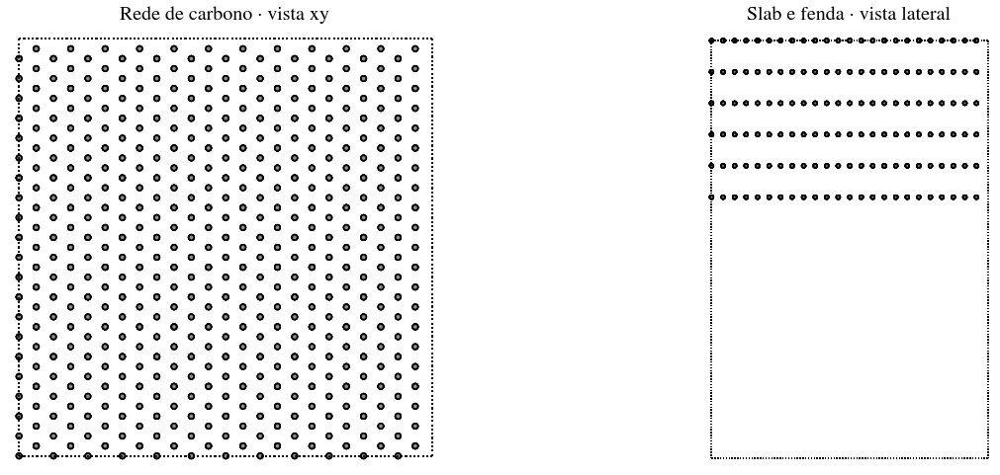

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
for eixo, rotacao, titulo in zip(ax, ["0x,0y,0z", "90x,0y,0z"],
                               ["Rede de carbono · vista xy", "Slab e fenda · vista lateral"]):
    plot_atoms(slab_c, eixo, rotation=rotacao, show_unit_cell=2, radii=0.25)
    eixo.set_title(titulo)
    eixo.set_axis_off()
plt.show()


### 10.3 Potencial atomístico, imagem mínima e cutoff

Usamos `set_geometry_from_ase(slab_c)` e o helper LJ do repositório. Ele aplica imagem mínima nas três direções e soma os pares carbono–CH₄. As FFTs também são periódicas.

$$V^{3D}_{ext}(\mathbf r)=\sum_a 4\epsilon_{sf}\left[\left(\frac{\sigma_{sf}}{r_a^{MIC}}\right)^{12}-\left(\frac{\sigma_{sf}}{r_a^{MIC}}\right)^6\right]\mathbf1_{r_a^{MIC}<r_c}.$$

Escolhemos $r_c=4\sigma_{sf}$ e verificamos $r_c\leq\min(L_x,L_y,L_z)/2$. A supercélula tem tamanho lateral suficiente para satisfazer essa condição; não usamos uma pequena célula primitiva com alcance maior que meia caixa.

**Duas convenções no mesmo argumento do pacote:** durante a soma atomística, `cut_off=4.0` significa $4\sigma_{sf}$. Depois de construir Vext, configuramos `cut_off=5*sigma_c` para o kernel **fluido–fluido**, que recebe um comprimento. Essa segunda chamada não recalcula Vext. Toda essa configuração ocorre antes de `set_temperature`.

A região ocupada pelo sólido é excluída explicitamente, e a mesma exclusão é usada nos controles 1D. Neste exemplo o próprio LJ já a torna inacessível; o código mostra quantos nós internos seriam acessíveis antes da exclusão.

**Como interpretar uma diferença com Steele:** Steele usa camadas contínuas e uma aproximação para o sólido semi-infinito. O slab usa átomos, seis camadas e um cutoff. Para separar essas diferenças, incluímos um controle 1D: as mesmas camadas integradas no plano e truncadas no mesmo alcance.

Para uma camada a distância $h<r_c$, esse controle é a integral do mesmo par LJ no disco acessível:

$$V_{\mathrm{camada}}(h)=2\pi\rho_A\epsilon_{sf}\sigma_{sf}^{2}\left[\frac25\left(\frac{\sigma_{sf}}h\right)^{10}-\left(\frac{\sigma_{sf}}h\right)^4-\frac25\left(\frac{\sigma_{sf}}{r_c}\right)^{10}+\left(\frac{\sigma_{sf}}{r_c}\right)^4\right],$$

com $V_{\mathrm{camada}}=0$ para $h\geq r_c$. Somamos as camadas usando imagem mínima em Z. O resultado deve aproximar a **média lateral do potencial atomístico**, sem pressupor igualdade exata das densidades: resolver cDFT e fazer uma média lateral não são operações intercambiáveis.


In [29]:
CUT_SF_C = 4.0
rc_sf_c = CUT_SF_C*sigma_sf_c
assert rc_sf_c <= 0.5*slab_c.cell.lengths().min(), "Aumente a supercélula lateral."
N_C = np.array([48, 48, 128])
passo_c = np.nextafter((slab_c.cell.lengths()/N_C).astype(np.float32), np.float32(np.inf))

slab_dft = DFT(functional="aWBI+MMFA", device=DEVICE)
slab_dft.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=CUT_SF_C)
slab_dft.set_gridsize(passo_c)
slab_dft.set_geometry_from_ase(slab_c)
with np.errstate(over="ignore"):
    slab_dft.calculate_external_potential_lj(forcefield_path=ff_c)
V_atom_c = slab_dft.Vext.detach().cpu().numpy().copy()  # Campo bruto, antes do teto de V/T.
z_abs_c = slab_dft.z.copy()
z_c = z_abs_c-espessura_c
poro_c = (z_c > 0) & (z_c < H_c)
print("Nós acessíveis dentro do slab antes da exclusão:",
      np.count_nonzero((V_atom_c/T_c < 36.8) & ~poro_c[None,None,:]))
V_calc_c = V_atom_c.copy()
V_calc_c[:, :, ~poro_c] = np.inf
slab_dft.set_external_potential(V_calc_c)
# Agora cut_off é o comprimento do kernel fluido–fluido; Vext fica preservado.
slab_dft.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=5*sigma_c)
slab_dft.set_temperature(T_c)
rho_res_c = float(slab_dft.calculate_rho_from_pbar(np.array([p_c]))[0])

V_steele_c = np.full_like(z_c, np.inf)
V_steele_c[poro_c] = (steele(z_c[poro_c], prefator_c, sigma_sf_c, delta_c)
                      + steele(H_c-z_c[poro_c], prefator_c, sigma_sf_c, delta_c))
V_planos_c = np.zeros_like(z_c)
for z_camada in np.arange(ncamadas)*delta_c:
    h = z_abs_c-z_camada
    h -= Lz_c*np.round(h/Lz_c)
    h = np.maximum(np.abs(h), 1e-6)
    v = prefator_c*(0.4*(sigma_sf_c/h)**10-(sigma_sf_c/h)**4
                    -0.4*(sigma_sf_c/rc_sf_c)**10+(sigma_sf_c/rc_sf_c)**4)
    V_planos_c += np.where(h < rc_sf_c, v, 0.0)
V_planos_c[~poro_c] = np.inf
print(f"Cutoff sólido–fluido: {rc_sf_c:.3f} Å; meia menor caixa: {slab_c.cell.lengths().min()/2:.3f} Å")
print("Malha 3D:", slab_dft.Ngrid, "· rho_b (Å⁻³):", rho_res_c)


Geometry defined from ASE atoms object:
Lx=29.52 A, Ly=29.83 A, Lz=44.73 A
Unit cell Volume = 39378.62 A³
Solid Mass = 24214.18 u
Solid Mass Density = 0.6149 u/A³
Grid defined!
Lgrid = (np.float64(29.52), np.float64(29.825914906336067), np.float64(44.725))  A
X-axis = [ 0.0 , 29.52 ] A
Y-axis = [ 0.0 , 29.825914906336067 ] A
Z-axis = [ 0.0 , 44.725 ] A
Number of gridpoints = (48, 48, 128)
delta =  [0.61500007 0.6213733  0.34941408]  A
Vol = 39378.61858436719  A³
Nós acessíveis dentro do slab antes da exclusão: 0
Cutoff sólido–fluido: 14.260 Å; meia menor caixa: 14.760 Å
Malha 3D: (48, 48, 128) · rho_b (Å⁻³): 0.00024529466597598027


### 10.4 Comparar os potenciais antes das densidades

O primeiro painel compara Steele, a média lateral atomística e as camadas contínuas com o mesmo cutoff. A faixa sombreada mostra a variação lateral do potencial atomístico. O segundo painel é um corte 3D real; a escala foi recortada apenas para visualizar a região de adsorção, sem alterar o campo usado no cálculo.


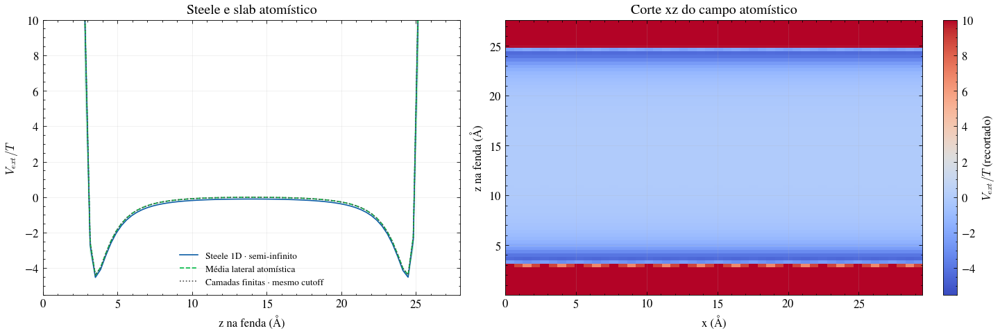

In [30]:
V_media_c = V_atom_c.mean(axis=(0,1))
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.0), constrained_layout=True)
ax[0].plot(z_c[poro_c], V_steele_c[poro_c]/T_c, label="Steele 1D · semi-infinito")
ax[0].plot(z_c[poro_c], V_media_c[poro_c]/T_c, "--", label="Média lateral atomística")
ax[0].plot(z_c[poro_c], V_planos_c[poro_c]/T_c, ":", color="0.3", label="Camadas finitas · mesmo cutoff")
ax[0].fill_between(z_c[poro_c], V_atom_c.min(axis=(0,1))[poro_c]/T_c,
                    V_atom_c.max(axis=(0,1))[poro_c]/T_c, color="C1", alpha=0.15)
ax[0].set(xlim=(0,H_c), ylim=(-5.5,10), xlabel="z na fenda (Å)", ylabel=r"$V_{ext}/T$",
          title="Steele e slab atomístico")
ax[0].legend(frameon=False, fontsize=8)
im = ax[1].imshow(np.clip(V_atom_c[:, slab_dft.Ngrid[1]//2, :][:,poro_c].T/T_c, -5.5, 10),
                   origin="lower", aspect="auto", extent=(0,slab_c.cell.lengths()[0],z_c[poro_c].min(),z_c[poro_c].max()),
                   cmap="coolwarm", vmin=-5.5, vmax=10)
ax[1].set(xlabel="x (Å)", ylabel="z na fenda (Å)", title="Corte xz do campo atomístico")
fig.colorbar(im, ax=ax[1], label=r"$V_{ext}/T$ (recortado)")
plt.show()


### 10.5 Resolver a cDFT 1D e 3D

As três soluções usam `aWBI+MMFA`, $T=300$ K, $P=10$ bar, o mesmo cutoff fluido–fluido, a mesma malha na direção normal e a mesma tolerância. O perfil atomístico é resolvido em 3D, partindo do bulk. Não usamos a solução 1D como chute.

Para comparar quantidades adsorvidas, calculamos $N/A$, e não N, pois a área artificial do objeto 1D não é a área do slab. Mantemos o controle de camadas finitas como diagnóstico da diferença entre o slab e Steele.


In [31]:
resultados_c, resumo_c = {}, []
for nome, V_1d in [("Steele 1D", V_steele_c), ("Camadas finitas 1D", V_planos_c), ("Slab atomístico 3D", None)]:
    if V_1d is None:
        sistema_c = slab_dft
    else:
        sistema_c = DFT(functional="aWBI+MMFA", device=DEVICE_1D)
        sistema_c.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=5*sigma_c)
        sistema_c.set_gridsize(float(slab_dft.delta[2]))
        sistema_c.set_geometry(Lz_c)
        sistema_c._from_ase = False
        sistema_c.set_external_potential(V_1d.reshape(sistema_c.Ngrid))
        sistema_c.set_temperature(T_c)
    sistema_c.set_bulk_density(rho_res_c)
    sistema_c.set_initial_condition("bulk")
    opt_c = Optimizer.create("picard", sistema_c, alpha=0.20,
                            atol=1e-7, rtol=1e-4, max_iter=2000)
    inicio = time.perf_counter()
    opt_c.run()
    if not opt_c.converged:
        raise RuntimeError(f"{nome}: {opt_c.stop_reason}; erro={opt_c.error:.3g}")
    rho_c = sistema_c.rho.detach().cpu().numpy().copy()
    media_c = rho_c.mean(axis=(0,1)) if V_1d is None else rho_c.squeeze()
    area_num = (np.prod(sistema_c.Ngrid[:2])*sistema_c.delta[0]*sistema_c.delta[1]
                if V_1d is None else sistema_c.dV/sistema_c.delta[0])
    gamma_c = float(sistema_c.Nabs)/float(area_num)*100  # moléculas/nm²
    resultados_c[nome] = {"media": media_c, "rho": rho_c, "Gamma": gamma_c}
    resumo_c.append([nome, gamma_c, opt_c.Niter, opt_c.error, time.perf_counter()-inicio])
display(pd.DataFrame(resumo_c, columns=["Modelo de parede", "N/A (nm⁻²)", "Iterações", "Erro", "Tempo (s)"]))


Grid defined!
Lgrid = (np.float32(44.725), np.float32(0.34941408), np.float32(0.34941408))  A
X-axis = [ 0.0 , 44.725 ] A
Y-axis = [ 0.0 , 0.34941408 ] A
Z-axis = [ 0.0 , 0.34941408 ] A
Number of gridpoints = (128, 1, 1)
delta =  [0.34941408 0.34941408 0.34941408]  A
Vol = 5.460484  A³
Grid defined!
Lgrid = (np.float32(44.725), np.float32(0.34941408), np.float32(0.34941408))  A
X-axis = [ 0.0 , 44.725 ] A
Y-axis = [ 0.0 , 0.34941408 ] A
Z-axis = [ 0.0 , 0.34941408 ] A
Number of gridpoints = (128, 1, 1)
delta =  [0.34941408 0.34941408 0.34941408]  A
Vol = 5.460484  A³


,Modelo de parede,N/A (nm⁻²),Iterações,Erro,Tempo (s)
0,Steele 1D,3.719819,37,0.813411,0.185530
1,Camadas finitas 1D,3.371301,36,0.941511,0.179534
2,Slab atomístico 3D,3.375890,36,0.941039,0.410068


### 10.6 Comparar perfis e interpretar as diferenças

A linha tracejada é a média da densidade 3D. A proximidade com o controle de camadas finitas indica quanto da diferença em relação a Steele vem do alcance das interações e da representação semi-infinita. A corrugação atomística pode produzir diferenças adicionais.

**Exercício:** aumente `CUT_SF_C` e a supercélula lateral juntos, respeitando o teste de imagem mínima. Aumente também o número de camadas se necessário. Refaça a configuração inteira e observe a aproximação a Steele. Refinar apenas a malha não recupera uma cauda de interação omitida.


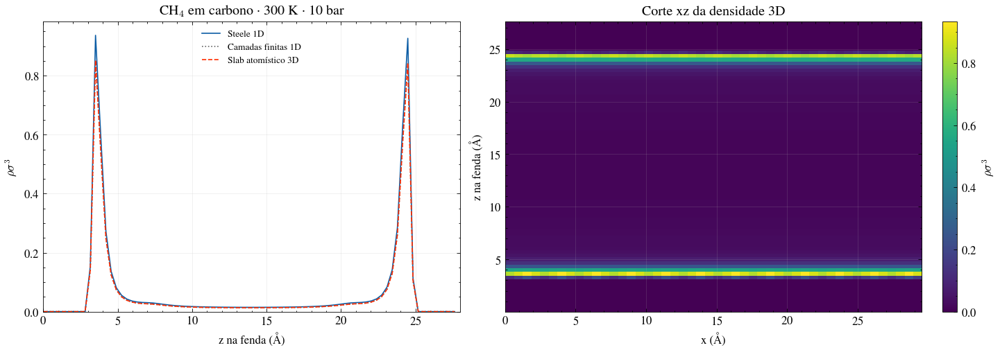

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)
for (nome, resultado), estilo, cor in zip(resultados_c.items(), ["-", ":", "--"], ["C0","0.4","C3"]):
    ax[0].plot(z_c[poro_c], resultado["media"][poro_c]*sigma_c**3, estilo, color=cor, label=nome)
ax[0].set(xlabel="z na fenda (Å)", ylabel=r"$\rho\sigma^3$", xlim=(0,H_c), ylim=(0,None),
          title=r"CH$_4$ em carbono · 300 K · 10 bar")
ax[0].legend(frameon=False, fontsize=8)
rho_slab_c = resultados_c["Slab atomístico 3D"]["rho"]
im = ax[1].imshow(rho_slab_c[:, rho_slab_c.shape[1]//2, :][:,poro_c].T*sigma_c**3,
                   origin="lower", aspect="auto", extent=(0,slab_c.cell.lengths()[0],z_c[poro_c].min(),z_c[poro_c].max()),
                   cmap="viridis")
ax[1].set(xlabel="x (Å)", ylabel="z na fenda (Å)", title="Corte xz da densidade 3D")
fig.colorbar(im, ax=ax[1], label=r"$\rho\sigma^3$")
plt.savefig("v6_carbono_Steele_slab.png", dpi=220, bbox_inches="tight")
plt.show()


# Parte D — CH₄ em IRMOF-1 a partir de um CIF



## 11. Estrutura, campo de força e potencial externo

O CIF descreve sítios atômicos. O campo de força fornece $\sigma_s$ e $\epsilon_s$. O helper do pacote aplica Lorentz–Berthelot,

$$\sigma_{sf}=\frac{\sigma_s+\sigma_f}{2},\qquad
\epsilon_{sf}=\sqrt{\epsilon_s\epsilon_f},$$

e soma a interação LJ de cada átomo em cada ponto da malha. Trocar TraPPE altera a EOS e os cruzamentos; trocar DREIDING por UFF altera apenas o sólido–fluido. O pacote não inclui eletrostática nem moléculas multisítio.


**Célula ortogonal obrigatória:** `set_geometry_from_ase` rejeita CIFs com ângulos diferentes de 90°. Não basta alterar os ângulos no arquivo: uma transformação válida precisa preservar a estrutura e pode exigir uma supercélula ortogonal equivalente.



### 11.1 Escolha do campo de força

- **Fluido:** o CH₄ TraPPE-UA é um sítio LJ com massa molecular. Um modelo N₂ de dois sítios e quadrupolo não pode ser transferido integralmente para este pacote.
- **Sólido:** DREIDING e UFF são pontos de partida. A tabela do helper é indexada por elemento; ela não distingue automaticamente hibridização, ambiente químico ou tipos diferentes do mesmo elemento.
- **Cruzamentos:** registre se usa Lorentz–Berthelot ou parâmetros cruzados ajustados. Para regras específicas, construa `Vext` explicitamente e use `set_external_potential`.
- **Comparação:** mantenha CIF, temperatura, funcional, cutoff e malha ao trocar o campo de força. Valide densidade/estrutura, volume acessível e isotermas com a mesma definição de excesso da referência.
- **Limitações físicas:** cargas, quadrupolos, moléculas orientacionais e flexibilidade do sólido não estão representados. Nenhum conjunto de parâmetros LJ recupera automaticamente esses efeitos.

A próxima célula lê o CIF e os dados de referência e restaura os parâmetros de CH₄, pois o exemplo anterior usou N₂.


In [33]:
sigma, epsilon, mass = 3.73, 148.0, 16.043  # CH4: Å, K, u

from ase.io import read
from ase.io.cube import write_cube
from ase.visualize import view
from ase.visualize.plot import plot_atoms
import py3Dmol

remotos = {
    "IRMOF-1.cif": "examples/structures/IRMOF-1.cif",
    "DREIDING-forcefield.dat": "examples/parameters/DREIDING-forcefield.dat",
    "UFF-forcefield.dat": "examples/parameters/UFF-forcefield.dat",
    "H2andCH4-MOFandZIF-isotherm-Zhou2007.xls": "examples/data/experimental/H2andCH4-MOFandZIF-isotherm-Zhou2007.xls",
    "CH4-MOF-isotherm-Keskin2016.xls": "examples/data/experimental/CH4-MOF-isotherm-Keskin2016.xls",
}
for nome, remoto in remotos.items():
    destino = dados / nome
    if not destino.exists():
        urlretrieve(f"{RAW}/{remoto}", destino)

estrutura = read(dados / "IRMOF-1.cif")
print("Fórmula:", estrutura.get_chemical_formula())
print("Átomos:", len(estrutura))
print("Célula (Å):", estrutura.cell.lengths())
print("Ângulos:", estrutura.cell.angles())


Fórmula: C192H96O104Zn32
Átomos: 424
Célula (Å): [25.86584 25.86584 25.86584]
Ângulos: [90. 90. 90.]


Projetamos a estrutura nos três planos para reconhecer átomos, canais e simetrias antes de olhar o potencial externo.


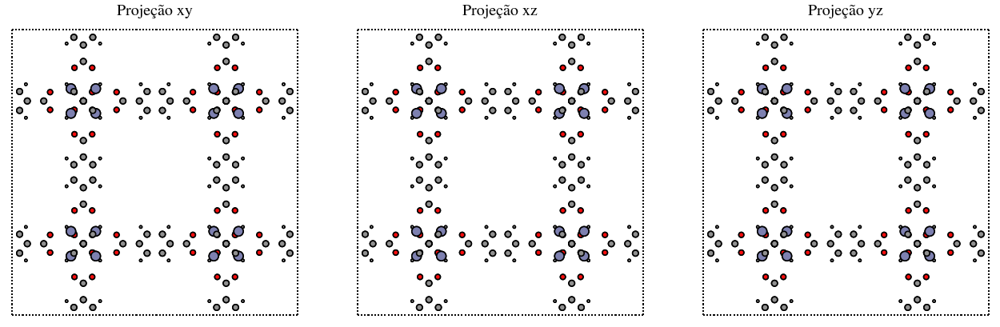

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(10.8, 3.4), constrained_layout=True)
for eixo, rotacao, titulo in zip(
    ax,
    ["0x,0y,0z", "90x,0y,0z", "0x,90y,0z"],
    ["Projeção xy", "Projeção xz", "Projeção yz"],
):
    plot_atoms(estrutura, eixo, rotation=rotacao, show_unit_cell=2, radii=0.35)
    eixo.set_title(titulo)
    eixo.set_axis_off()
plt.show()


### 11.2 Estrutura interativa com ASE

Arraste para girar e use a roda para aproximar. Aqui vemos **átomos e ligações**; logo veremos $V_{ext}(\mathbf r)$, um campo escalar derivado deles.


In [35]:
view(estrutura, viewer="x3d")


A tabela compara os parâmetros cruzados CH₄–sólido de DREIDING e UFF para os elementos presentes no CIF. Escolha o campo antes de construir Vext.


In [36]:
FORCEFIELD = "DREIDING"  # troque por "UFF" e reconstrua Vext
ff_path = dados / f"{FORCEFIELD}-forcefield.dat"
elementos = sorted(set(estrutura.get_chemical_symbols()))

tabelas = []
for nome in ["DREIDING", "UFF"]:
    ff = pd.read_csv(dados / f"{nome}-forcefield.dat", sep=r"\s+")
    ff = ff[ff["atom"].isin(elementos)].copy()
    ff["sigma_sf (Å)"] = 0.5 * (sigma + ff["sigma/AA"])
    ff["epsilon_sf (K)"] = np.sqrt(epsilon * ff["epsilon/kB"])
    ff.insert(0, "Campo", nome)
    tabelas.append(ff[["Campo", "atom", "sigma_sf (Å)", "epsilon_sf (K)"]])

display(pd.concat(tabelas).sort_values(["atom", "Campo"]).rename(columns={"atom": "Elemento", "sigma_sf (Å)": "Sigma sf (Å)", "epsilon_sf (K)": "Epsilon sf (K)"}).style.format({
    "Sigma sf (Å)": "{:.3f}", "Epsilon sf (K)": "{:.2f}"
}))


,Campo,Elemento,Sigma sf (Å),Epsilon sf (K)
1,DREIDING,C,3.601,84.16
1,UFF,C,3.580,88.43
0,DREIDING,H,3.288,33.65
0,UFF,H,3.151,57.24
3,DREIDING,O,3.382,84.42
3,UFF,O,3.424,66.85
9,DREIDING,Zn,3.887,64.00
5,UFF,Zn,3.096,96.10


### 11.3 Como a estrutura vira um campo escalar

Para cada sítio do CIF, `calculate_external_potential_lj` lê símbolo e posição, busca os parâmetros, aplica Lorentz–Berthelot e soma o LJ em cada nó. Uma segunda soma, com uma sonda He, define o volume acessível.

$$V_{ext}(\mathbf r)=\sum_{a\in\mathrm{célula}}u_{sf,a}\!\left(\lVert\Delta\mathbf r_a^{MIC}\rVert\right).$$

**Convenção de imagem mínima (MIC).** O código substitui cada componente da separação por

$$\Delta r_{a,\alpha}^{MIC}=r_\alpha-R_{a,\alpha}-L_\alpha\,\operatorname{round}\!\left(\frac{r_\alpha-R_{a,\alpha}}{L_\alpha}\right),\qquad \alpha=x,y,z.$$

Isso seleciona a imagem periódica mais próxima de **cada átomo da célula**, em vez de somar explicitamente todas as réplicas do cristal. O helper aplica periodicidade nas três direções, sem consultar individualmente `atoms.pbc`; definir `pbc=False` no ASE não o transforma em um cálculo de superfície isolada. As convoluções por FFT da cDFT também são periódicas. Na fenda, regiões proibidas e um buffer separam os poros; na MOF, queremos a estrutura periódica.

**Somente células ortorrômbicas (ângulos de 90°).** A redução por componente pressupõe eixos ortogonais; `set_geometry_from_ase` rejeita ângulos diferentes de 90°. Não altere apenas os ângulos do CIF. É preciso uma representação ortogonal equivalente, quando existir, com posições cartesianas alinhadas aos eixos da caixa. Células triclínicas exigem outra implementação da geometria e das convoluções.

**Imagem mínima não é uma soma periódica completa.** Para que um potencial truncado tenha no máximo uma imagem relevante por átomo, a condição usual é

$$r_c\leq\tfrac12\min(L_x,L_y,L_z).$$

Se o alcance desejado ultrapassar esse limite, aumente a célula com uma supercélula válida ou use uma soma explícita de imagens. Refinar a malha não corrige imagens ausentes.

**Atenção ao commit usado:** o kernel fluido–fluido recebe `cut_off` como comprimento, mas `aux.lj_potential` trunca em `cut_off * sigma_sf`. Assim, `cut_off=14` não significa alcance sólido–fluido de 14 Å. A célula abaixo calcula os alcances efetivos e testa a condição MIC. Mantemos a convenção do notebook original para preservar sua comparação com a MOF; se ela exceder meia caixa, o resultado corresponde à soma de imagens mínimas implementada, e não a uma soma completa até aquele alcance. Essa limitação deve acompanhar a interpretação quantitativa.

O helper constrói `Vext[i,j,k]` com NumPy na CPU; a GPU atua principalmente nas convoluções FFT. O mesmo campo será amostrado em 32³, 64³ e 128³. Cortes terão planos e escala de cores comuns. O cálculo principal conserva 28³ pontos com `dx=L/28`, enquanto a extensão da seção 14 compara também perfis e isotermas refinados.


In [37]:
# Alcance sólido–fluido realmente usado pelo helper neste commit.
ff_mic = pd.read_csv(ff_path, sep=r"\s+")
ff_mic = ff_mic[ff_mic["atom"].isin(elementos)].copy()
ff_mic["Sigma sf (Å)"] = 0.5*(sigma+ff_mic["sigma/AA"])
ff_mic["Alcance sf (Å)"] = 14.0*ff_mic["Sigma sf (Å)"]
ff_mic["Meia menor caixa (Å)"] = 0.5*estrutura.cell.lengths().min()
ff_mic["MIC cobre o alcance?"] = ff_mic["Alcance sf (Å)"] <= ff_mic["Meia menor caixa (Å)"]
display(ff_mic[["atom", "Sigma sf (Å)", "Alcance sf (Å)",
                "Meia menor caixa (Å)", "MIC cobre o alcance?"]])
if not ff_mic["MIC cobre o alcance?"].all():
    print("Convenção original mantida: há imagens além da mínima dentro do alcance nominal.")


,atom,Sigma sf (Å),Alcance sf (Å),Meia menor caixa (Å),MIC cobre o alcance?
0,H,3.288210,46.03494,12.93292,False
1,C,3.601495,50.42093,12.93292,False
3,O,3.381575,47.34205,12.93292,False
9,Zn,3.887340,54.42276,12.93292,False


Convenção original mantida: há imagens além da mínima dentro do alcance nominal.


In [38]:
T = 300.0          # K
rcut = 14.0        # Convenção numérica original; mantida na comparação e no cálculo
L = float(estrutura.cell.lengths()[0])
campos = {}

for N in [32, 64, 128]:
    dx = float(np.nextafter(np.float32(L/N), np.float32(np.inf)))
    grade = DFT(functional="aWBI+MMFA", device=DEVICE)
    grade.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=mass, cut_off=rcut)
    grade.set_gridsize(gridsize=dx)
    grade.set_geometry_from_ase(estrutura)
    grade.calculate_external_potential_lj(forcefield_path=ff_path)

    campos[N] = {
        "betaV": grade.Vext.detach().cpu().numpy().copy() / T,
        "x": grade.x.copy(), "y": grade.y.copy(), "z": grade.z.copy(), "dx": dx,
    }
    del grade
    gc.collect()


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (32, 32, 32)
delta =  [0.8083076 0.8083076 0.8083076]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (64, 64, 64)
delta =  [0.4041538 0.4041538 0.4041538]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (128, 128, 128)
delta =  [0.2020769 0.2020769 0.2020769]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Vamos desenhar os mesmos cortes xy, xz e yz nas três resoluções. A escala de cores comum permite comparar a discretização dos bordos.


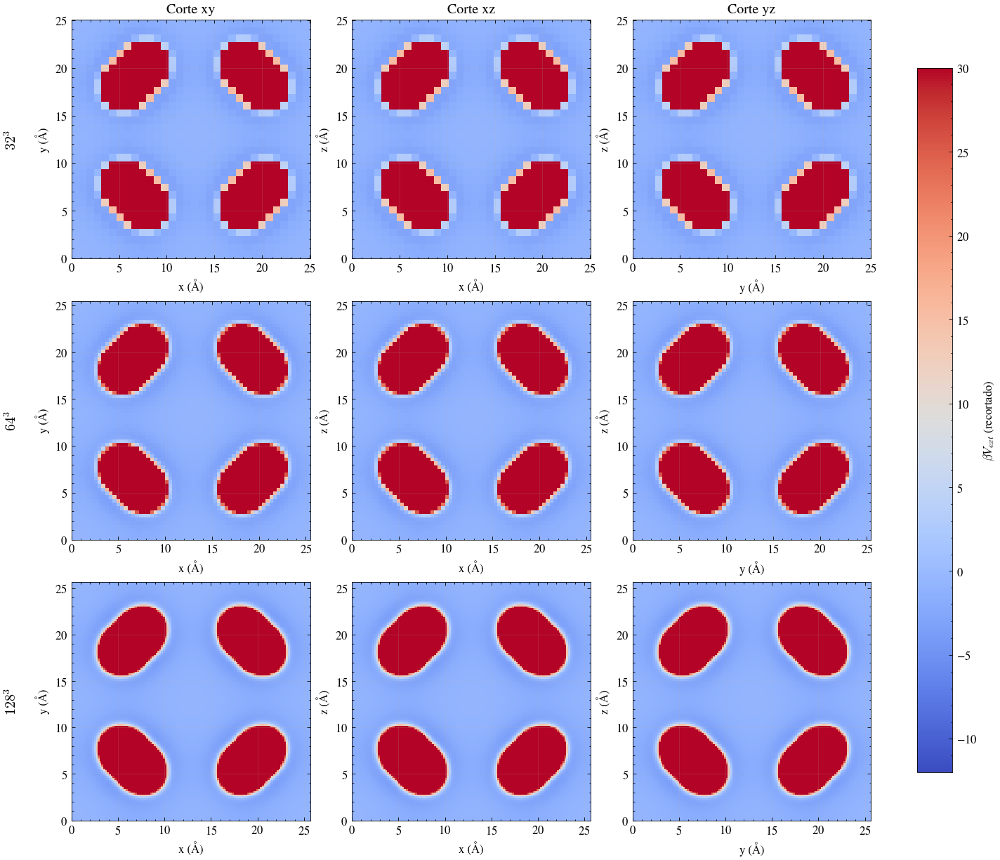

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(11.8, 10.2), constrained_layout=True)
planos = ["Corte xy", "Corte xz", "Corte yz"]

for linha, N in enumerate([32, 64, 128]):
    g = campos[N]
    campo = g["betaV"]
    i, j, k = [n//2 for n in campo.shape]
    cortes = [
        (campo[:, :, k].T, [g["x"].min(), g["x"].max(), g["y"].min(), g["y"].max()], "x (Å)", "y (Å)"),
        (campo[:, j, :].T, [g["x"].min(), g["x"].max(), g["z"].min(), g["z"].max()], "x (Å)", "z (Å)"),
        (campo[i, :, :].T, [g["y"].min(), g["y"].max(), g["z"].min(), g["z"].max()], "y (Å)", "z (Å)"),
    ]
    for coluna, (corte, extent, xlabel, ylabel) in enumerate(cortes):
        im = axes[linha, coluna].imshow(
            np.clip(corte, -12, 30), origin="lower", extent=extent,
            cmap="coolwarm", vmin=-12, vmax=30, interpolation="nearest", aspect="equal",
        )
        if linha == 0:
            axes[linha, coluna].set_title(planos[coluna])
        axes[linha, coluna].set(xlabel=xlabel, ylabel=ylabel)
    axes[linha, 0].annotate(fr"${N}^3$", (-0.25, 0.5), xycoords="axes fraction",
                            ha="center", va="center", rotation=90, fontsize=12)

fig.colorbar(im, ax=axes, label=r"$\beta V_{ext}$ (recortado)", shrink=0.88)
plt.savefig("v6_Vext_32_64_128.png", dpi=220, bbox_inches="tight")
plt.show()


Montamos um objeto independente com **28³ pontos**, usando `dx=L/28` (com proteção de arredondamento). Na versão anterior, `dx=0.25*sigma` produzia 28 pontos cujo período numérico era 26,11 Å, enquanto o CIF mede 25,86584 Å. O ajuste faz o período das FFTs coincidir com a célula usada pela imagem mínima. É uma correção de discretização; 28³ continua sendo uma malha de aula, sujeita a estudo de convergência.


In [40]:
# O período das FFTs deve fechar exatamente a célula do CIF.
N_MOF = 28
L_mof = float(estrutura.cell.lengths()[0])
dx = float(np.nextafter(np.float32(L_mof/N_MOF), np.float32(np.inf)))
dft = DFT(functional="aWBI+MMFA", device=DEVICE)
dft.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=mass, cut_off=rcut)
dft.set_gridsize(gridsize=dx)
dft.set_geometry_from_ase(estrutura)
dft.calculate_external_potential_lj(forcefield_path=ff_path)
betaV = dft.Vext.detach().cpu().numpy().copy() / T
dft.set_temperature(kT=T)

print("Malha DFT:", dft.Ngrid)
print(f"Espaçamento: {dft.delta[0]:.4f} Å")
print(f"Volume acessível ao He: {dft.Vpore:.2f} Å³/célula")
print(f"Fração de vazio de He: {dft.helium_fraction:.4f}")


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (28, 28, 28)
delta =  [0.9237801 0.9237801 0.9237801]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Malha DFT: (28, 28, 28)
Espaçamento: 0.9238 Å
Volume acessível ao He: 14004.96 Å³/célula
Fração de vazio de He: 0.8093


### 11.4 Estrutura molecular versus isosuperfície de potencial

O `.cube` combina átomos e campo 3D. Mostramos dois valores em células separadas para que você possa alterá-los sem reconstruir o potencial.


In [41]:
arquivo_vext = f"Vext_CH4_IRMOF1_{FORCEFIELD}.cube"
with open(arquivo_vext, "w") as arq:
    write_cube(arq, estrutura, data=betaV)

def mostrar_cube(caminho, isoval, cor, opacidade=0.55):
    texto = Path(caminho).read_text(encoding="utf-8")
    v = py3Dmol.view(width=800, height=500)
    v.addModel(texto, "cube")
    v.setStyle({"stick": {"radius": 0.10}, "sphere": {"scale": 0.22}})
    v.addVolumetricData(texto, "cube", {
        "isoval": float(isoval), "color": cor, "opacity": opacidade,
    })
    v.zoomTo()
    return v


Primeira isosuperfície: uma região atrativa com Vext/T = −2. Altere apenas o isovalor para explorar outros níveis sem recalcular o campo.


In [42]:
# Região atrativa: experimente -1, -2 ou -4.
mostrar_cube(arquivo_vext, isoval=-2.0, cor="blue")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Segunda isosuperfície: Vext/T = 10 destaca o contorno repulsivo. Compare com a estrutura molecular e com a superfície atrativa.


In [43]:
# Região repulsiva/excluída: experimente 5, 10 ou 20.
mostrar_cube(arquivo_vext, isoval=10.0, cor="red", opacidade=0.28)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 12. Um perfil de densidade 3D

A pressão fixa o reservatório pela EOS. Em seguida, Anderson resolve a equação de Euler–Lagrange. Só interpretaremos o campo se `converged=True`.


In [44]:
p = 10.0 # bar
rho_b = float(dft.calculate_rho_from_pbar(np.array([p]))[0])
dft.set_bulk_density(rho_b)
dft.set_initial_condition(model="bulk")

opt = Optimizer.create(
    "anderson", dft, alpha=0.10, history_size=6,
    atol=1e-8, rtol=1e-4, max_iter=15000,
)
inicio = time.perf_counter()
erro, n_iter = opt.run()
tempo = time.perf_counter() - inicio

display(pd.DataFrame([{
    "Pressão (bar)": p, "Densidade bulk (moléculas/Å³)": rho_b,
    "Iterações": n_iter, "Tempo (s)": tempo,
    "Erro": erro, "Convergiu": opt.converged,
}]).style.format({"Densidade bulk (moléculas/Å³)": "{:.4e}", "Tempo (s)": "{:.1f}", "Erro": "{:.2e}"}))

if not opt.converged:
    raise RuntimeError(f"Perfil 3D não convergiu: {opt.stop_reason}")


,Pressão (bar),Densidade bulk (moléculas/Å³),Iterações,Tempo (s),Erro,Convergiu
0,10.000000,2.4529e-04,8,0.4,8.17e-01,True


Extraímos três cortes da densidade em escala logarítmica. A barra de cores pertence apenas a esses mapas.


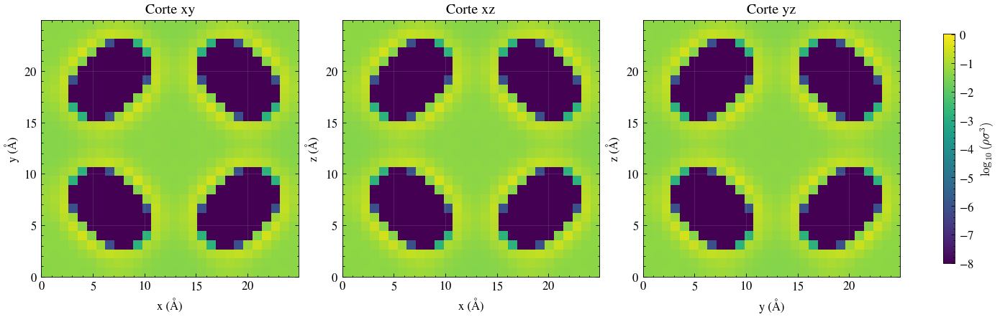

In [45]:
rho_3d = dft.rho.detach().cpu().numpy()
rho_star = rho_3d * sigma**3
i, j, k = [n//2 for n in rho_3d.shape]
logrho = np.log10(np.maximum(rho_star, 1e-10))
vmax = float(np.quantile(logrho[dft.allowed.cpu().numpy()], 0.995))

fig, ax = plt.subplots(1, 3, figsize=(11.6, 3.7), constrained_layout=True)
cortes = [
    (logrho[:, :, k].T, [dft.x.min(), dft.x.max(), dft.y.min(), dft.y.max()], "xy", "x (Å)", "y (Å)"),
    (logrho[:, j, :].T, [dft.x.min(), dft.x.max(), dft.z.min(), dft.z.max()], "xz", "x (Å)", "z (Å)"),
    (logrho[i, :, :].T, [dft.y.min(), dft.y.max(), dft.z.min(), dft.z.max()], "yz", "y (Å)", "z (Å)"),
]
for eixo, (corte, extent, plano, xlabel, ylabel) in zip(ax, cortes):
    im = eixo.imshow(corte, origin="lower", extent=extent, cmap="viridis",
                     vmin=-8, vmax=vmax, interpolation="nearest", aspect="equal")
    eixo.set(title=f"Corte {plano}", xlabel=xlabel, ylabel=ylabel)
fig.colorbar(im, ax=ax, label=r"$\log_{10}(\rho\sigma^3)$", shrink=0.85)
plt.savefig("v6_densidade_3D_cortes.png", dpi=220, bbox_inches="tight")
plt.show()


A média no plano xy produz um observável diferente dos cortes. Vamos representá-la separadamente e comparar com o bulk.


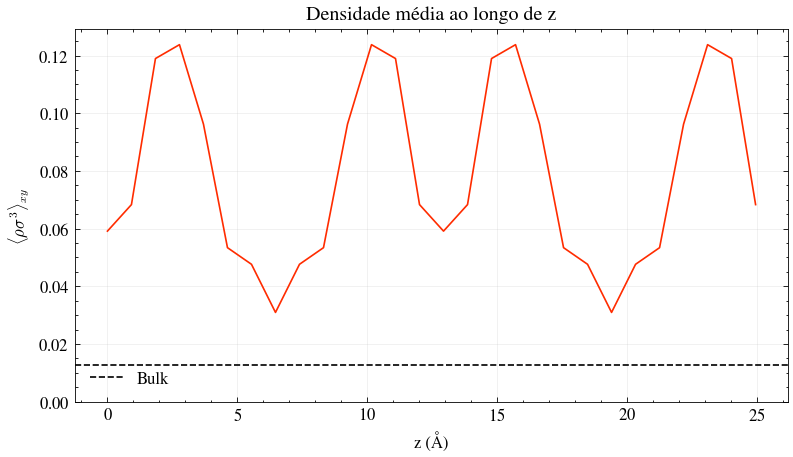

In [46]:
# A média em xy é um observável diferente dos cortes: por isso ganha sua própria figura.
rho_media = rho_star.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(6.6, 3.8), constrained_layout=True)
ax.plot(dft.z, rho_media, color="C3")
ax.axhline(rho_b*sigma**3, color="k", ls="--", label="Bulk")
ax.set(xlabel="z (Å)", ylabel=r"$\langle\rho\sigma^3\rangle_{xy}$",
       title="Densidade média ao longo de z", ylim=(0, None))
ax.legend(frameon=False)
plt.show()


### 12.1 Isodensidade em dois níveis

Uma isosuperfície baixa mostra regiões difusas e conectividade; uma alta destaca apenas os sítios de maior ocupação.


In [47]:
arquivo_rho = f"rho_CH4_IRMOF1_{p:g}bar.cube"
with open(arquivo_rho, "w") as arq:
    write_cube(arq, estrutura, data=rho_3d)

rho_pos = rho_3d[(rho_3d > 1e-12) & np.isfinite(rho_3d)]
iso_baixa, iso_alta = np.quantile(rho_pos, [0.75, 0.95])
print(f"Isovalores: baixo={iso_baixa:.4g}; alto={iso_alta:.4g} moléculas/Å³")


Isovalores: baixo=0.003616; alto=0.009587 moléculas/Å³


Um valor baixo de isodensidade revela regiões difusas e possíveis conexões entre cavidades.


In [48]:
mostrar_cube(arquivo_rho, isoval=iso_baixa, cor="cyan", opacidade=0.45)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Um valor mais alto realça apenas os sítios de maior ocupação. A densidade não foi recalculada: apenas o nível da superfície mudou.


In [49]:
mostrar_cube(arquivo_rho, isoval=iso_alta, cor="orange", opacidade=0.60)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 13. Isoterma de adsorção até 900 bar

Usamos **todos os 44 pontos originais, de 0,001 a 900 bar**, sem cortar a curva em 100 bar. Para controlar o solver e verificar cada ponto, escrevemos o laço de continuação explicitamente com `DFT` e `Optimizer` do repositório.

A densidade convergida é o chute da pressão seguinte; o **histórico de Anderson é novo em cada pressão**. Começamos com `alpha=0.10`, `regularization=1e-6`. Uma tentativa malsucedida é descartada e a próxima restaura o último estado válido com mistura menor. Não passamos um perfil NaN para a pressão seguinte.

A rotina de conveniência `calculate_isotherm` continua sendo demonstrada no estudo de malhas da seção 14. O laço explícito é útil quando você precisa ajustar configurações, interromper falhas e exportar diagnósticos sem interpretar logs arredondados.

$$N_{abs}=\int\rho(\mathbf r)d\mathbf r,\qquad N_{exc}=N_{abs}-\rho_b V_{pore}^{He}.$$

**Limite físico:** chegar a 900 bar com resíduo convergido não comprova independência de malha nem validade quantitativa do modelo nessa faixa. A convenção MIC/cutoff do caso MOF permanece a descrita na seção 11.


In [50]:
# Retoma os passos menores usados no notebook original para a continuação entre pressões.
pressoes = np.r_[
    [0.001, 0.01],
    np.arange(0.1, 1.0, 0.1),
    np.arange(1.0, 10.0, 1.0),
    np.arange(10.0, 100.0, 10.0),
    np.arange(100.0, 200.0, 20.0),
    np.arange(250.0, 500.0, 50.0),
    np.arange(500.0, 1000.0, 100.0),
]
P_MAX_MOF = 900.0  # O percurso principal inclui a faixa completa.
pressoes = pressoes[pressoes <= P_MAX_MOF]
exportar = [p for p in [10.0, 100.0] if p <= P_MAX_MOF]
nome_iso = f"isoterma_CH4_IRMOF1_300K_{FORCEFIELD}"
print(f"{len(pressoes)} pressões entre {pressoes[0]:g} e {pressoes[-1]:g} bar")


44 pressões entre 0.001 e 900 bar


Percorremos as pressões em ordem crescente. A tabela de diagnóstico registra o erro sem arredondamento intermediário, o número total de iterações e a mistura que convergiu. Só guardamos observáveis após a convergência.


In [51]:
linhas_iso, linhas_diag = [], []
rhos_mof = dft.calculate_rho_from_pbar(pressoes)
inicio = time.perf_counter()
for j, (pressao_mof, rb_mof) in enumerate(zip(pressoes, rhos_mof)):
    dft.set_bulk_density(float(rb_mof))
    if j == 0:
        dft.set_initial_condition("bulk")
    ultimo_estado = dft.state.detach().clone()
    iter_total = 0
    for mistura in [0.10, 0.05, 0.01]:
        with torch.no_grad():
            dft.state.copy_(ultimo_estado)
        dft.apply_update()
        opt_mof = Optimizer.create("anderson", dft, alpha=mistura, history_size=6,
                                   regularization=1e-6, start_iteration=2,
                                   atol=1e-8, rtol=1e-4, max_iter=3000)
        opt_mof.run()
        iter_total += opt_mof.Niter
        if opt_mof.converged:
            break
    if not opt_mof.converged:
        raise RuntimeError(f"MOF: P={pressao_mof:g} bar; {opt_mof.stop_reason}. "
                           "Estado inválido descartado: reveja malha, passos de pressão e solver.")
    nabs_mof = float(dft.Nabs)
    nexc_mof = nabs_mof-float(rb_mof)*float(dft.Vpore)
    linhas_iso.append([pressao_mof, rb_mof, nabs_mof, nexc_mof,
                       1000*nabs_mof/float(dft.mss), 1000*nexc_mof/float(dft.mss)])
    linhas_diag.append([pressao_mof, iter_total, opt_mof.error, mistura, opt_mof.converged])
    if np.any(np.isclose(pressao_mof, exportar)):
        caminho = f"density_profile_{nome_iso}_P={pressao_mof:.2f}bar.cube"
        with open(caminho, "w") as arq:
            write_cube(arq, estrutura, data=dft.rho.detach().cpu().numpy())
    if (j+1) % 10 == 0 or j == len(pressoes)-1:
        print(f"MOF: {j+1}/{len(pressoes)} · {pressao_mof:g} bar · erro={opt_mof.error:.3g}", flush=True)

iso = pd.DataFrame(linhas_iso, columns=["Pressure (bar)", "Bulk Density (molecules/AA3)",
                   "Absolute adsorption (molecules/uc)", "Excess adsorption (molecules/uc)",
                   "Absolute adsorption (mol/kg)", "Excess adsorption (mol/kg)"])
diagnostico = pd.DataFrame(linhas_diag, columns=["Pressão (bar)", "Iterações", "Erro", "Alpha", "Convergiu"])
iso.to_csv(f"{nome_iso}.dat", index=False)
diagnostico.to_csv(f"{nome_iso}_diagnostico.csv", index=False)
print(f"Isoterma até {iso['Pressure (bar)'].max():g} bar em {time.perf_counter()-inicio:.1f} s")


MOF: 10/44 · 0.8 bar · erro=0.252
MOF: 20/44 · 9 bar · erro=0.689
MOF: 30/44 · 100 bar · erro=0.839
MOF: 40/44 · 500 bar · erro=0.88
MOF: 44/44 · 900 bar · erro=0.759
Isoterma até 900 bar em 4.5 s


A primeira tabela mostra a convergência de cada pressão; a segunda contém a adsorção absoluta e em excesso. A verificação final exige todos os pontos solicitados e erro menor que 1, incluindo 900 bar.


In [52]:
assert len(iso) == len(pressoes) and np.isclose(iso["Pressure (bar)"].iloc[-1], P_MAX_MOF)
assert diagnostico["Convergiu"].all() and (diagnostico["Erro"] < 1).all()
assert np.isfinite(iso.to_numpy()).all()
display(diagnostico.style.format({"Pressão (bar)": "{:.4g}", "Erro": "{:.3e}", "Alpha": "{:.2f}"}))
colunas = ["Pressure (bar)", "Bulk Density (molecules/AA3)",
           "Absolute adsorption (mol/kg)", "Excess adsorption (mol/kg)"]
display(iso[colunas].style.format(precision=5))


,Pressão (bar),Iterações,Erro,Alpha,Convergiu
0,0.001,3,1.103e-02,0.10,True
1,0.01,3,9.794e-02,0.10,True
2,0.1,9,4.229e-02,0.10,True
3,0.2,3,7.894e-01,0.10,True
4,0.3,3,3.539e-01,0.10,True
5,0.4,3,1.948e-01,0.10,True
6,0.5,3,8.221e-02,0.10,True
7,0.6,3,2.322e-01,0.10,True
8,0.7,3,1.446e-01,0.10,True
9,0.8,3,2.518e-01,0.10,True


,Pressure (bar),Bulk Density (molecules/AA3),Absolute adsorption (mol/kg),Excess adsorption (mol/kg)
0,0.00100,0.00000,0.00043,0.00038
1,0.01000,0.00000,0.00434,0.00379
2,0.10000,0.00000,0.04342,0.03793
3,0.20000,0.00000,0.08690,0.07591
4,0.30000,0.00001,0.13035,0.11387
5,0.40000,0.00001,0.17379,0.15181
6,0.50000,0.00001,0.21730,0.18983
7,0.60000,0.00001,0.26089,0.22792
8,0.70000,0.00002,0.30432,0.26585
9,0.80000,0.00002,0.34784,0.30386


Vamos comparar adsorção absoluta e em excesso com os dados disponíveis, mantendo unidades e convenções consistentes.


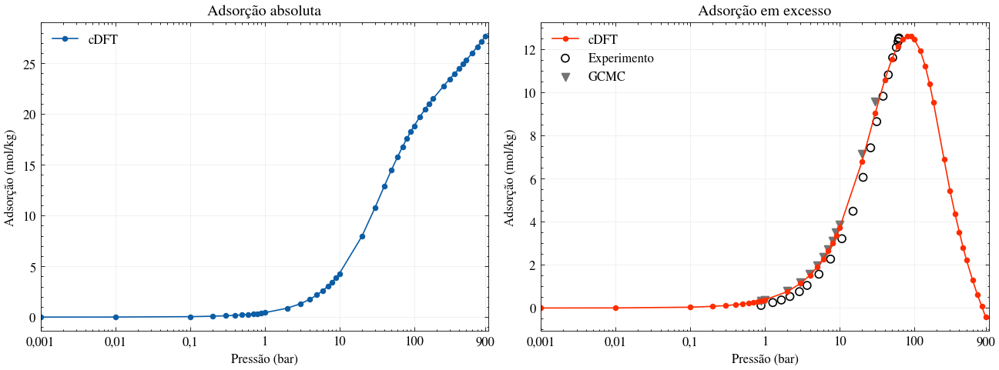

In [53]:
zhou = pd.read_excel(dados / "H2andCH4-MOFandZIF-isotherm-Zhou2007.xls", sheet_name="CH4-MOF5")
keskin = pd.read_excel(dados / "CH4-MOF-isotherm-Keskin2016.xls", sheet_name="IRMOF-1")

# Zhou fornece % em massa; convertemos para mol/kg de adsorvente.
w = zhou["Nexc(%wt)-300K"] / 100
zhou_molkg = (1000/mass) * w/(1-w)

fig, ax = plt.subplots(1, 2, figsize=(10.8, 4.0), sharex=True, constrained_layout=True)
ax[0].plot(iso["Pressure (bar)"], iso["Absolute adsorption (mol/kg)"],
           "o-", ms=3.5, color="C0", label="cDFT")
ax[1].plot(iso["Pressure (bar)"], iso["Excess adsorption (mol/kg)"],
           "o-", ms=3.5, color="C3", label="cDFT")
ax[1].scatter(zhou["Pexc(bar)-300K"], zhou_molkg,
              facecolors="none", edgecolors="k", label="Experimento")
ax[1].scatter(keskin["Pressure (bar)"], keskin["Excess adsorption (mmol/g)"],
              marker="v", color="0.45", label="GCMC")

for eixo in ax:
    eixo.set_xscale("log")
    eixo.set_xlim(pressoes[0], P_MAX_MOF*1.1)
    eixo.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 900],
                    labels=["0,001", "0,01", "0,1", "1", "10", "100", "900"])
    eixo.set(xlabel="Pressão (bar)", ylabel="Adsorção (mol/kg)")
    eixo.legend(frameon=False)
ax[0].set_title("Adsorção absoluta")
ax[1].set_title("Adsorção em excesso")
plt.savefig("v6_isoterma_CH4_IRMOF1.png", dpi=220, bbox_inches="tight")
plt.show()


Os campos das pressões selecionadas já foram exportados. Listaremos os arquivos para que você possa abri-los no visualizador ou reutilizá-los.


In [54]:
# Os perfis pedidos foram exportados; não os repetiremos em novos gráficos.
for arquivo in sorted(Path(".").glob(f"density_profile_{nome_iso}_*.cube")):
    print(arquivo)


density_profile_isoterma_CH4_IRMOF1_300K_DREIDING_P=10.00bar.cube
density_profile_isoterma_CH4_IRMOF1_300K_DREIDING_P=100.00bar.cube


# Parte E — Extensões físicas e numéricas


## 14. Extensão: perfis e isotermas da MOF em três malhas

Agora não refinamos apenas o desenho de Vext: resolveremos a cDFT em **32³, 64³ e 128³**, com o mesmo CIF, campo de força, temperatura e pressões. O custo cresce bastante; execute este bloco fora do percurso básico se necessário.

**Escopo da comparação:** 0,001–10 bar. Nos ensaios locais, a malha 32³ apresentou instabilidade a partir de 20 bar com as configurações testadas, mesmo com mistura menor. A isoterma ampla anterior permanece na malha de aula 28³ com período ajustado ao CIF. Não extrapole a conclusão de independência de malha para 900 bar. A ausência de convergência do solver não é evidência de uma transição física.

O código captura os logs sem imprimir cada pressão. Em seguida, confere a convergência e guarda o perfil final, a 10 bar. Uma única tabela resume custo e resolução; os dados completos ficam em arquivos.


In [55]:
p_malha = np.geomspace(0.001, 10.0, 12)  # Mesmas pressões nas três malhas.
malhas = {}
custos = []
for N in [32, 64, 128]:
    inicio = time.perf_counter()
    log = StringIO()
    with redirect_stdout(log):
        grade = DFT(functional="aWBI+MMFA", device=DEVICE)
        grade.set_fluid_properties(sigma=3.73, epsilon=148.0, mass=16.043, cut_off=14.0)
        # nextafter evita obter N+1 por arredondamento ao definir o passo.
        dx = np.nextafter(np.float32(estrutura.cell.lengths()[0]/N), np.float32(np.inf))
        grade.set_gridsize(float(dx))
        grade.set_geometry_from_ase(estrutura)
        with np.errstate(over="ignore"):  # +inf no núcleo LJ será tratado como região proibida.
            grade.calculate_external_potential_lj(forcefield_path=dados / f"{FORCEFIELD}-forcefield.dat")
        grade.set_temperature(300.0)
        nome = f"v6_malha_{N}"
        grade.calculate_isotherm(p_malha, filename=nome)
    Path(nome + ".log").write_text(log.getvalue(), encoding="utf-8")
    # O helper imprime pressão, bulk, Nabs, iterações e erro normalizado.
    estados = []
    for linha in log.getvalue().splitlines():
        campos = linha.split()
        if len(campos) == 5:
            try: estados.append([float(x) for x in campos])
            except ValueError: pass
    erros = np.asarray(estados)[:, -1] if estados else np.array([])
    if "Warning: convergence failed" in log.getvalue() or len(erros) != len(p_malha) or not np.isfinite(erros).all() or (erros > 1).any():
        raise RuntimeError(f"Malha {N}³: veja {nome}.log antes de comparar resultados.")
    iso = pd.read_csv(nome + ".dat")
    rho = grade.rho.detach().cpu().numpy()
    malhas[N] = {"Iso": iso, "Rho": rho, "L": grade.Lgrid,
                 "Z": grade.Z[0, 0, :].copy(), "Rhob": grade.rhob}
    custos.append([N, float(grade.delta[0]), time.perf_counter()-inicio, float(grade.Nabs)])
    del grade
    gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()

display(pd.DataFrame(custos, columns=["N", "Passo (Å)", "Tempo total (s)", "Nabs a 10 bar"]))


,N,Passo (Å),Tempo total (s),Nabs a 10 bar
0,32,0.808308,2.175252,26.622459
1,64,0.404154,6.719196,26.296618
2,128,0.202077,68.697193,26.259630


### 14.1 Os mesmos cortes de densidade a 10 bar

Cada linha é uma malha e cada coluna é um plano. Usamos os mesmos limites e a mesma escala logarítmica, sem interpolação visual. Refinamento que apenas alisa um bordo não basta: compare também integrais e isotermas.


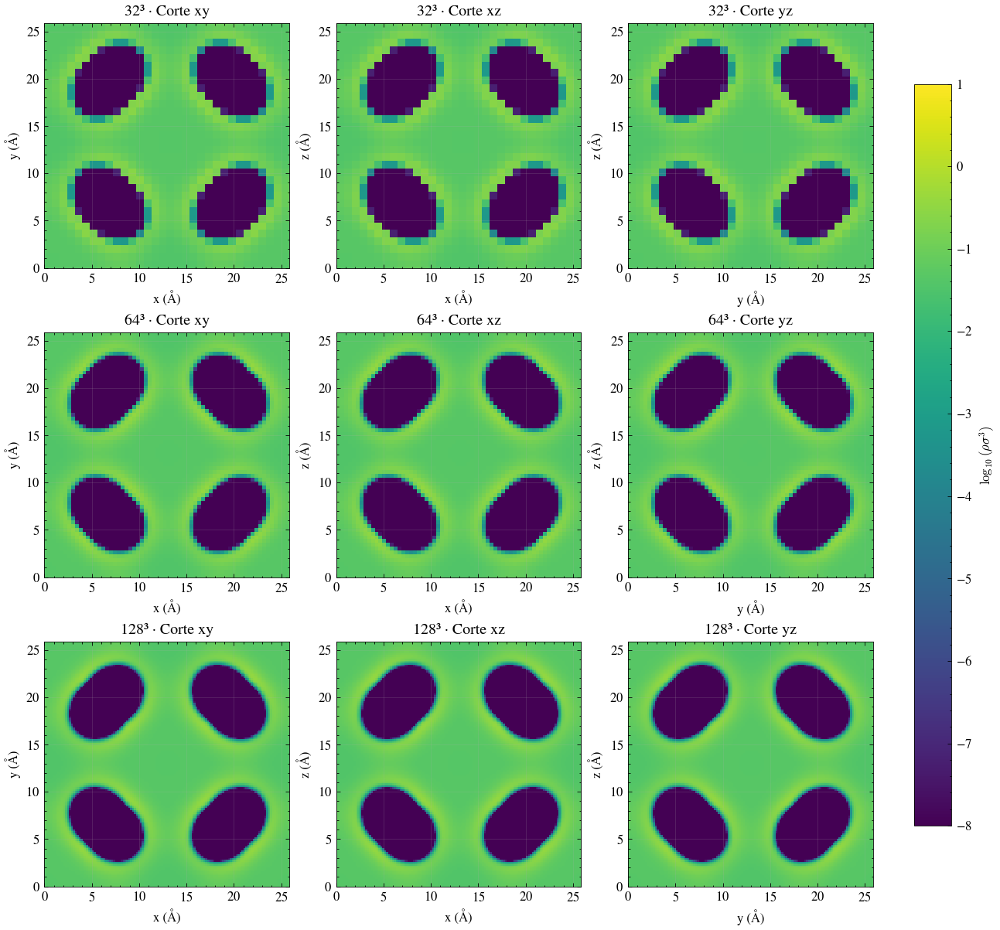

In [56]:
fig, ax = plt.subplots(3, 3, figsize=(10.8, 10), constrained_layout=True)
for linha, (N, resultado) in enumerate(malhas.items()):
    rho = resultado["Rho"] * 3.73**3
    L = resultado["L"]
    cortes = [rho[:, :, N//2], rho[:, N//2, :], rho[N//2, :, :]]
    for coluna, (corte, plano, i, j) in enumerate(zip(cortes, ["xy", "xz", "yz"], [0,0,1], [1,2,2])):
        mapa = ax[linha, coluna].imshow(np.log10(np.maximum(corte.T, 1e-8)),
            origin="lower", extent=(0, L[i], 0, L[j]), vmin=-8, vmax=1,
            cmap="viridis", interpolation="nearest")
        ax[linha, coluna].set(title=f"{N}³ · Corte {plano}", xlabel=f"{plano[0]} (Å)", ylabel=f"{plano[1]} (Å)")
fig.colorbar(mapa, ax=ax, label=r"$\log_{10}(\rho\sigma^3)$", shrink=0.85)
plt.show()


A média no plano xy fica em uma figura própria. Já as isotermas usam três painéis com limites comuns; a curva 128³ tracejada serve como referência numérica, não como solução exata.


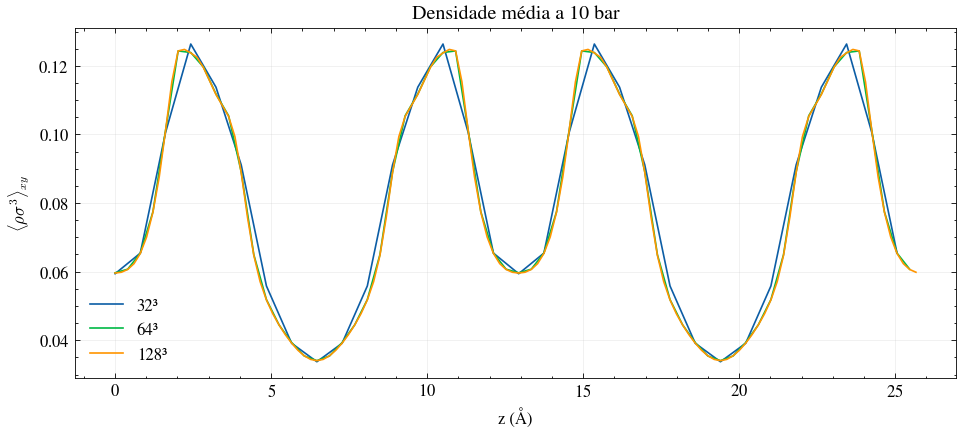

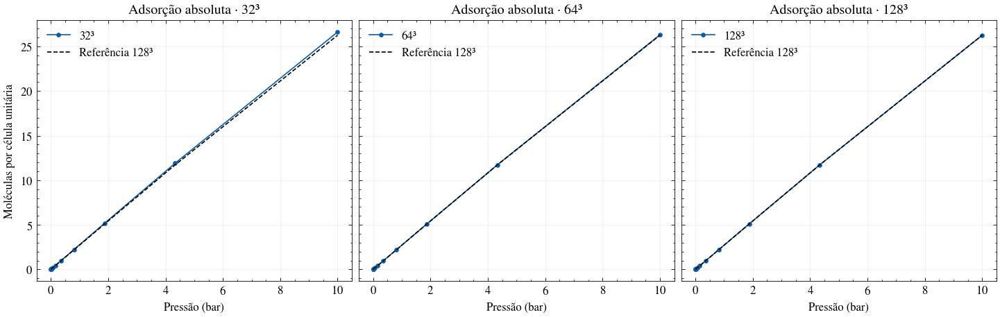

In [57]:
fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
for N, resultado in malhas.items():
    ax.plot(resultado["Z"], resultado["Rho"].mean(axis=(0,1))*3.73**3, label=f"{N}³")
ax.set(xlabel="z (Å)", ylabel=r"$\langle\rho\sigma^3\rangle_{xy}$", title="Densidade média a 10 bar")
ax.legend(frameon=False)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True)
ref = malhas[128]["Iso"]
for eixo, (N, resultado) in zip(ax, malhas.items()):
    iso = resultado["Iso"]
    eixo.plot(iso["Pressure (bar)"], iso["Absolute adsorption (molecules/uc)"], "o-", ms=3, label=f"{N}³")
    eixo.plot(ref["Pressure (bar)"], ref["Absolute adsorption (molecules/uc)"], "k--", lw=1, label="Referência 128³")
    eixo.set(xlabel="Pressão (bar)", title=f"Adsorção absoluta · {N}³")
    eixo.legend(frameon=False)
ax[0].set_ylabel("Moléculas por célula unitária")
plt.show()


### Exercício 3: Adsorção de CH₄ em carbono amorfo a 200 K

#### Objetivo
Calcular a adsorção de metano em uma estrutura atomística tridimensional de carbono amorfo, relacionando a heterogeneidade do potencial externo à distribuição espacial do fluido e às isotermas.

Utilize o CIF **`aCarbon-Bhatia-id001.cif`**, disponível no repositório. Inspire-se no [Example6–Adsorption3D_CH4_on_aCarbon_Bathia](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example6-Adsorption3D_CH4_on_aCarbon_Bathia.ipynb), mantendo a temperatura deste exercício em **200 K**.

A partir da estrutura e dos resultados, deve-se:

1. **Caracterizar o adsorvente:** Ler o CIF com ASE, verificar dimensões e ângulos da célula, visualizar a estrutura e informar o volume acessível à sonda He e sua fração de vazio.
2. **Construir o potencial externo:** Aplicar os parâmetros sólido–fluido e representar cortes de Vext/T nos planos xy, xz e yz. Explicar por que esse campo não pode ser substituído diretamente por uma fenda de Steele com uma única largura.
3. **Calcular a isoterma:** Resolver a cDFT por continuação entre 0,001 e 100 bar. Representar adsorção absoluta e em excesso em moléculas/célula unitária e converter para mol/kg de adsorvente.
4. **Interpretar a ocupação dos poros:** Comparar cortes de densidade a 0,01, 1 e 100 bar com escala de cores comum, relacionando os sítios inicialmente ocupados ao campo externo. Exportar ao menos um campo `.cube`.
5. **Avaliar a qualidade do cálculo:** Registrar funcional, malha, cutoff, dispositivo, tolerâncias e convergência. Distinguir convergência do solver de independência de malha e validação física.

---

#### Parâmetros e condições

| Escolha | Valor / orientação |
|---|---|
| Fluido | CH₄ TraPPE-UA: σ=3,73 Å; ε/kB=148 K; massa=16,043 u |
| Sólido | `aCarbon-Bhatia-id001.cif`; parâmetros de carbono de `DREIDING-forcefield.dat` |
| Cruzamentos | Lorentz–Berthelot, conforme o helper do pacote |
| Temperatura | 200 K |
| Funcional do gabarito | `aRF+MMFA`; explicitar a diferença em relação ao `aWBI+MMFA` do exemplo original |
| Malha inicial | `gridsize=0.25*sigma`; verificar o número de nós retornado |
| Pressões | 41 pontos logarítmicos de 0,001 a 100 bar |
| Adsorção em excesso | $N_{exc}=N_{abs}-\rho_b V_{pore}^{He}$, com He na mesma temperatura |

#### Procedimento sugerido

- Siga o workflow estrutura → campo externo → temperatura → reservatório → chute → solver.
- Use um objeto independente daquele da MOF para não sobrescrever seus resultados.
- Reutilize a densidade convergida ao aumentar a pressão e interrompa a análise se aparecer um estado não convergido.
- Mantenha limites e escala de cores iguais ao comparar os mapas de densidade.
- Discuta como a tortuosidade e a distribuição de ambientes locais diferenciam esse material de um slit-pore idealizado.

**Atenção à referência:** o Example6 e seu arquivo GCMC são de **300 K**, não de 200 K. Não sobreponha esses dados à isoterma de 200 K como se fossem uma validação. Uma comparação quantitativa requer repetir temperatura, funcional, cutoffs, estrutura e demais convenções.

#### Referências

- Estrutura e procedimento: [PyDFTlj — Example6](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example6-Adsorption3D_CH4_on_aCarbon_Bathia.ipynb).
- CH₄ TraPPE-UA: Martin & Siepmann (1998), [DOI](https://doi.org/10.1021/jp972543+).
- DREIDING: Mayo, Olafson & Goddard (1990), [DOI](https://doi.org/10.1021/j100389a010).


#### Gabarito 3 — início do bloco removível

**Pré-requisitos:** importações da seção 1; os arquivos são baixados abaixo sem depender do cálculo da MOF. Tags: `gabarito`, `exercicio-3`.

Usamos a estrutura e os parâmetros do Example6, mas **T=200 K**. O gabarito adota `aRF+MMFA`: nos ensaios a 200 K, as configurações tentadas de `aWBI+MMFA` apresentaram instabilidades. Trocar a parte FMT muda a aproximação física, não é apenas alterar o solver; por isso a escolha está visível no enunciado. Não apresentamos os resultados como reprodução quantitativa do Example6.

Primeiro carregamos o CIF e os parâmetros. O hash do commit em `RAW` fixa a versão dos arquivos. Os nomes próprios deste exercício preservam o objeto e os resultados da MOF.

In [58]:
from ase.io import read
from ase.io.cube import write_cube
from ase.visualize import view

dados_ex3 = Path("dados_ex3")
dados_ex3.mkdir(exist_ok=True)
for nome, pasta in [("aCarbon-Bhatia-id001.cif", "structures"),
                    ("DREIDING-forcefield.dat", "parameters")]:
    destino = dados_ex3 / nome
    if not destino.exists():
        urlretrieve(f"{RAW}/examples/{pasta}/{nome}", destino)

carbono_ex3 = read(dados_ex3 / "aCarbon-Bhatia-id001.cif")
param_ex3 = pd.read_csv(dados_ex3 / "DREIDING-forcefield.dat", sep=r"\s+").set_index("atom").loc["C"]
print("Estrutura:", carbono_ex3.get_chemical_formula())
print("Dimensões (Å):", carbono_ex3.cell.lengths())
print("Ângulos (graus):", carbono_ex3.cell.angles())
display(param_ex3.to_frame("Carbono · DREIDING"))
if not np.allclose(carbono_ex3.cell.angles(), 90):
    raise ValueError("O pacote exige uma célula ortogonal.")

Estrutura: C1166
Dimensões (Å): [29.5 29.8 30.2]
Ângulos (graus): [90. 90. 90.]


,Carbono · DREIDING
sigma/AA,3.47299
epsilon/kB,47.85620
mass/u,12.01070


A visualização interativa mostra a estrutura discreta de carbono. Gire o sólido para observar a irregularidade dos canais; a figura seguinte mostrará o campo escalar derivado desses átomos.

In [59]:
display(view(carbono_ex3, viewer="x3d"))

Construímos agora Vext e o objeto de cDFT. Mantemos o **valor numérico `cut_off=14` do Example6**. No commit fixado, o helper atomístico aplica imagem mínima e testa `r > cut_off*sigma_sf`, enquanto o kernel fluido–fluido recebe um comprimento. Portanto, esse valor não representa simplesmente um corte esférico de 14 Å em ambas as interações. Essa convenção deve ser revista antes de uma aplicação quantitativa; aqui ela está registrada para manter a base do exemplo de referência.

O campo é construído antes de `set_temperature()`. A temperatura determina a máscara acessível e o volume de He. A malha inicial é aproximadamente 32³, não um teste de independência de malha.

In [72]:
sig_ex3, eps_ex3, T_ex3 = 3.73, 148.0, 300.0
carb = DFT(functional="aRF+MMFA", device=DEVICE)
carb.set_fluid_properties(sigma=sig_ex3, epsilon=eps_ex3, mass=16.043, cut_off=14.0)
carb.set_gridsize(0.25*sig_ex3)
carb.set_geometry_from_ase(carbono_ex3)
with np.errstate(over="ignore"):  # O núcleo LJ pode atingir +inf; será uma região proibida.
    carb.calculate_external_potential_lj(forcefield_path=dados_ex3 / "DREIDING-forcefield.dat")
carb.set_temperature(T_ex3)
campo_ex3 = carb.Vext.detach().cpu().numpy()/T_ex3
print("Malha:", carb.Ngrid)
print(f"Volume da célula: {carb.Volbox:.2f} Å³")
print(f"Volume de He a {T_ex3:g} K: {carb.Vpore:.2f} Å³; fração: {carb.helium_fraction:.4f}")
with open("ex3_carbono_Vext_sobre_T.cube", "w") as arq:
    write_cube(arq, carbono_ex3, data=campo_ex3)

Geometry defined from ASE atoms object:
Lx=29.50 A, Ly=29.80 A, Lz=30.20 A
Unit cell Volume = 26548.82 A³
Solid Mass = 14004.83 u
Solid Mass Density = 0.5275 u/A³
Grid defined!
Lgrid = (np.float64(29.5), np.float64(29.8), np.float64(30.2))  A
X-axis = [ 0.0 , 29.5 ] A
Y-axis = [ 0.0 , 29.8 ] A
Z-axis = [ 0.0 , 30.2 ] A
Number of gridpoints = (32, 32, 33)
delta =  [0.9325 0.9325 0.9325]  A
Vol = 26548.82  A³
Malha: (32, 32, 33)
Volume da célula: 26548.82 Å³
Volume de He a 300 K: 19328.62 Å³; fração: 0.7280


Os três cortes centrais têm a mesma escala de Vext/T. Valores negativos favorecem a ocupação; regiões fortemente positivas representam exclusão. O recorte na escala de cores serve só à visualização, sem alterar o campo resolvido.

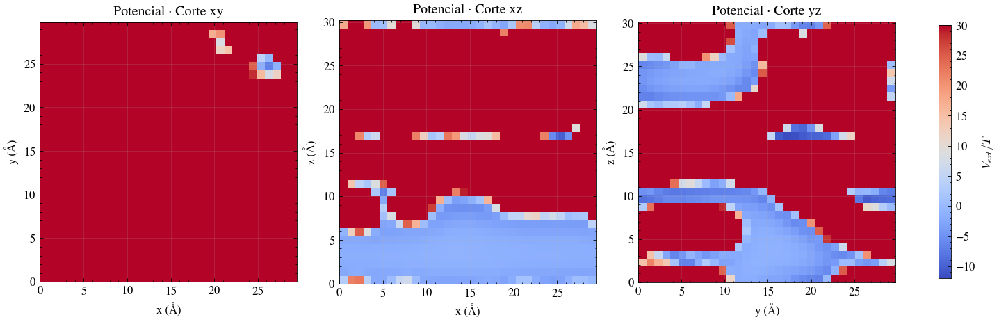

In [73]:
nx, ny, nz = carb.Ngrid
lx, ly, lz = carbono_ex3.cell.lengths()
cortes_ex3 = [campo_ex3[:, :, nz//2], campo_ex3[:, ny//2, :], campo_ex3[nx//2, :, :]]
extensoes_ex3 = [(0,lx,0,ly), (0,lx,0,lz), (0,ly,0,lz)]
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for eixo, campo, plano, limites in zip(ax, cortes_ex3, ["xy", "xz", "yz"], extensoes_ex3):
    im = eixo.imshow(campo.T, origin="lower", extent=limites, cmap="coolwarm",
                     vmin=-12, vmax=30, interpolation="nearest")
    eixo.set(title=f"Potencial · Corte {plano}", xlabel=f"{plano[0]} (Å)", ylabel=f"{plano[1]} (Å)")
fig.colorbar(im, ax=ax, label=r"$V_{ext}/T$", shrink=0.8)
plt.show()

A isoterma começa de um **chute não uniforme**: a resposta de gás ideal ao campo, limitada inicialmente a $0{,}5/\sigma^3$. Esse limite vale apenas para o chute; não restringe as densidades procuradas pelo solver. Ele reduz o salto inicial para os sítios mais atrativos.

Depois usamos Picard e continuação em pressão. A tabela resume convergência e adsorção, e os arquivos preservam todos os pontos. O excesso usa o volume de He; mol/kg é numericamente igual a mmol/g. Não se divide a adsorção absoluta pelo volume da caixa para obter uma quantidade por massa.

In [74]:
p_ex3 = np.geomspace(0.001, 100.0, 41)
rb_ex3 = carb.calculate_rho_from_pbar(p_ex3)
carb.set_bulk_density(float(rb_ex3[0]))
carb.set_initial_condition("bulk")
chute_ex3 = torch.clamp(carb.rhob*torch.exp(-carb.beta*carb.Vext), min=1e-16, max=0.5/sig_ex3**3)
carb.state[:] = torch.log(chute_ex3)
carb.apply_update()

linhas_ex3, densidades_ex3 = [], {}
for j, (ponto, rb) in enumerate(zip(p_ex3, rb_ex3)):
    carb.set_bulk_density(float(rb))
    carb.update_system()
    opt_ex3 = Optimizer.create("picard", carb, alpha=0.03,
                               atol=1e-7, rtol=1e-4, max_iter=5000)
    opt_ex3.run()
    if not opt_ex3.converged:
        raise RuntimeError(f"Carbono a {ponto:.4g} bar: {opt_ex3.stop_reason}; erro={opt_ex3.error:.3g}")
    nabs = float(carb.Nabs)
    nexc = nabs-float(rb)*float(carb.Vpore)
    linhas_ex3.append([ponto, nabs, nexc, 1000*nabs/float(carb.mss),
                       1000*nexc/float(carb.mss), opt_ex3.Niter, opt_ex3.error])
    if np.any(np.isclose(ponto, [0.01, 1.0, 100.0])):
        densidades_ex3[float(ponto)] = carb.rho.detach().cpu().numpy().copy()
        with open(f"ex3_carbono_rho_{ponto:g}bar.cube", "w") as arq:
            write_cube(arq, carbono_ex3, data=densidades_ex3[float(ponto)])
    if (j+1) % 10 == 0 or j == len(p_ex3)-1:
        print(f"Carbono: {j+1}/{len(p_ex3)} · {ponto:.4g} bar · erro={opt_ex3.error:.3g}", flush=True)

iso_ex3 = pd.DataFrame(linhas_ex3, columns=["Pressão (bar)", "N absoluto", "N excesso",
    "Absoluta (mol/kg)", "Excesso (mol/kg)", "Iterações", "Erro"])
iso_ex3.to_csv("ex3_CH4_carbono_200K.csv", index=False)
display(iso_ex3.iloc[[0,8,16,24,32,40]].round(4))
print(f"Convergência: {len(iso_ex3)}/{len(p_ex3)} pontos; maior erro = {iso_ex3['Erro'].max():.4f}")

Carbono: 10/41 · 0.01334 bar · erro=0.979
Carbono: 20/41 · 0.2371 bar · erro=0.986
Carbono: 30/41 · 4.217 bar · erro=0.996
Carbono: 40/41 · 74.99 bar · erro=0.99
Carbono: 41/41 · 100 bar · erro=0.99


,Pressão (bar),N absoluto,N excesso,Absoluta (mol/kg),Excesso (mol/kg),Iterações,Erro
0,0.001,0.1609,0.1604,0.0115,0.0115,204,0.9732
8,0.010,1.4764,1.4717,0.1054,0.1051,180,0.9886
16,0.100,9.4190,9.3723,0.6726,0.6692,186,0.9761
24,1.000,35.9123,35.4449,2.5643,2.5309,193,0.9946
32,10.000,93.3968,88.6556,6.6689,6.3304,204,0.9881
40,100.000,152.1431,98.0979,10.8636,7.0046,218,0.9896


Convergência: 41/41 pontos; maior erro = 1.0000


As isotermas absoluta e em excesso têm significados diferentes. Mesmo que N absoluto cresça, o excesso pode passar por um máximo porque o termo subtraído $\rho_b V_{pore}^{He}$ também aumenta. As escalas linear e logarítmica de pressão mostram regiões diferentes da mesma isoterma.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


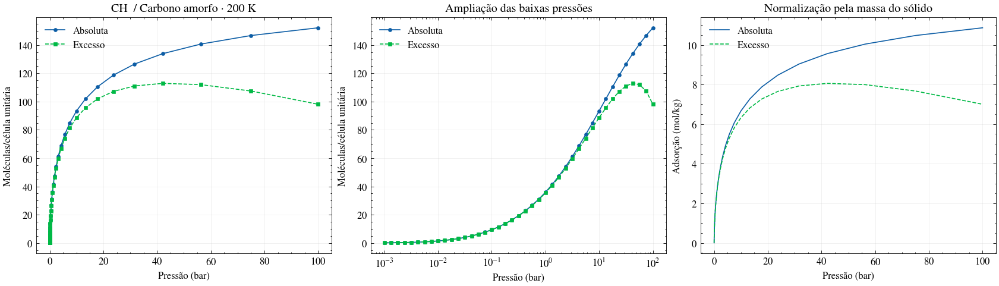

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for eixo in ax[:2]:
    eixo.plot(iso_ex3["Pressão (bar)"], iso_ex3["N absoluto"], "o-", ms=3, label="Absoluta")
    eixo.plot(iso_ex3["Pressão (bar)"], iso_ex3["N excesso"], "s--", ms=3, label="Excesso")
    eixo.set(xlabel="Pressão (bar)", ylabel="Moléculas/célula unitária")
    eixo.legend(frameon=False)
ax[0].set_title("CH₄ / Carbono amorfo · 300 K")
ax[1].set(xscale="log", title="Ampliação das baixas pressões")
ax[2].plot(iso_ex3["Pressão (bar)"], iso_ex3["Absoluta (mol/kg)"], label="Absoluta")
ax[2].plot(iso_ex3["Pressão (bar)"], iso_ex3["Excesso (mol/kg)"], "--", label="Excesso")
ax[2].set(xlabel="Pressão (bar)", ylabel="Adsorção (mol/kg)", title="Normalização pela massa do sólido")
ax[2].legend(frameon=False)
plt.show()

Cada linha abaixo corresponde a uma pressão e cada coluna a um corte central. A escala comum de $\log_{10}(\rho\sigma^3)$ evita aparentes diferenças causadas por reescalonamento automático. As regiões ocupadas primeiro devem ser relacionadas aos vales de Vext, embora a interação fluido–fluido também altere o perfil. Use os `.cube` exportados para examinar o campo completo.

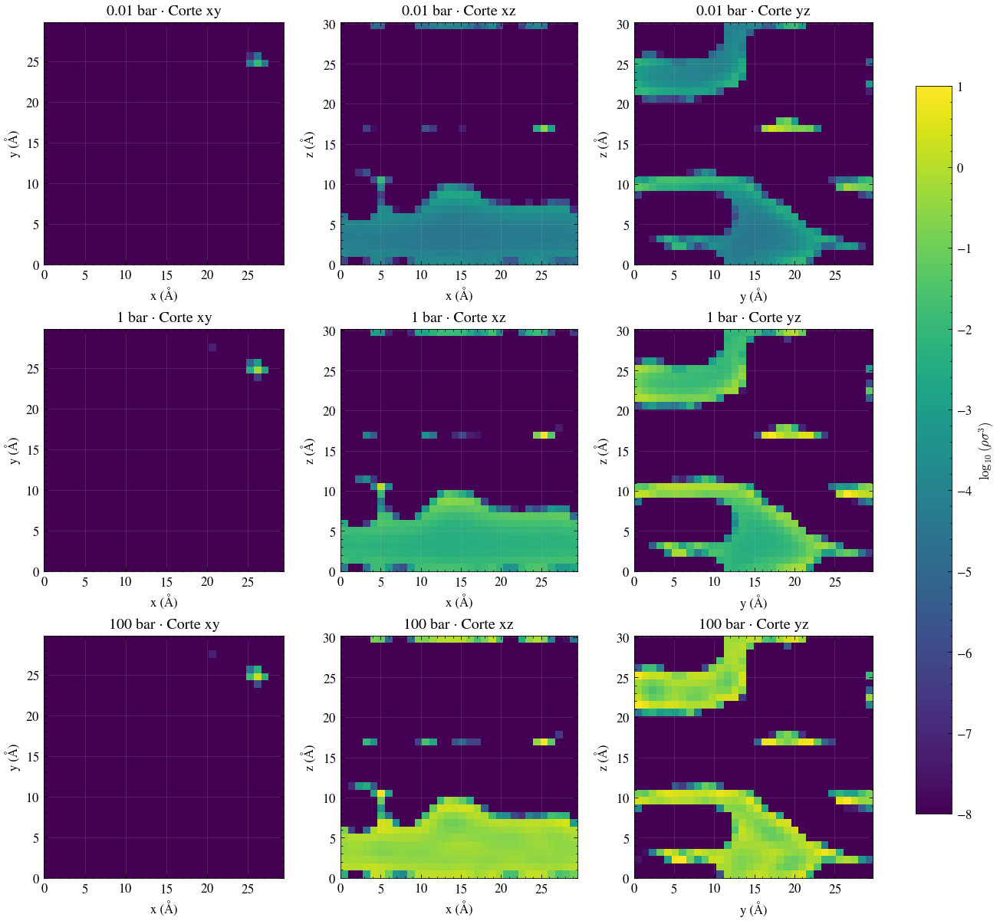

In [76]:
fig, axes = plt.subplots(3, 3, figsize=(11, 10), constrained_layout=True)
for linha, (pressao, rho_carb) in enumerate(densidades_ex3.items()):
    campo = np.log10(np.maximum(rho_carb*sig_ex3**3, 1e-8))
    cortes = [campo[:, :, nz//2], campo[:, ny//2, :], campo[nx//2, :, :]]
    for eixo, corte, plano, limites in zip(axes[linha], cortes, ["xy", "xz", "yz"], extensoes_ex3):
        im = eixo.imshow(corte.T, origin="lower", extent=limites, cmap="viridis",
                         vmin=-8, vmax=1, interpolation="nearest")
        eixo.set(title=f"{pressao:g} bar · Corte {plano}", xlabel=f"{plano[0]} (Å)", ylabel=f"{plano[1]} (Å)")
fig.colorbar(im, ax=axes, label=r"$\log_{10}(\rho\sigma^3)$", shrink=0.85)
plt.show()

**Interpretação e limites.** O carbono amorfo gera uma distribuição de ambientes locais, não duas paredes equivalentes. Um perfil médio pode esconder sítios muito diferentes; os cortes e os campos 3D ajudam a reconhecê-los. A fração de vazio de He depende da sonda, do campo de força e da temperatura e não coincide necessariamente com uma porosidade geométrica.

A resolução acima é uma referência didática para esta malha e para `aRF+MMFA`. Não foi demonstrada independência de malha, cutoff ou funcional. Para comparar com o GCMC do repositório, seria necessário calcular a 300 K e auditar essas mesmas convenções; o presente resultado de 200 K não realiza essa validação. Uma comparação DREIDING/UFF também exigiria reconstruir Vext e repetir a isoterma inteira.

**Fim do gabarito 3.**

## 15. Extensão: RDF de Lennard–Jones pelo método da partícula teste

Uma aplicação diferente da mesma maquinaria: fixamos uma partícula LJ no centro da caixa e usamos sua interação como potencial externo. No fluido homogêneo,

$$V_{ext}(r)=u_{LJ}(r),\qquad g(r)=\rho(r)/\rho_b.$$

Não calculamos a RDF a partir de trajetórias. Resolvemos a resposta de equilíbrio ao campo de uma partícula. Esse procedimento é uma aproximação quando o funcional é aproximado.

Reproduzimos o primeiro estado de [Example4–RadialDistributionFunction](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example4-RadialDistributionFunction.ipynb): $T^*=2{,}934$ e $\rho_b^*=0{,}450$, com WBI+MFA, WBI+WDA e WBI+MMFA. Os pontos são de **dinâmica molecular (MD)** de [Verlet (1968)](https://doi.org/10.1103/PhysRev.165.201), como indica o exemplo original — apesar de estarem na pasta `MC`.

Usamos caixa $12\sigma$, cutoff $5\sigma$ e malha 64³ para a exploração inicial. Para aproximação à resolução do exemplo original (passo $0{,}1\sigma$), use N=128 e verifique novamente a convergência. O arquivo também contém o estado $T^*=2{,}888$, $\rho_b^*=0{,}850$; deixamos sua exploração como exercício, não como caso já validado nesta seção.

**Correção numérica desta revisão:** o erro `RDF MMFA: Non-finite energy or residual` foi reproduzido com Picard. Usamos ABC-FIRE para os três funcionais, conforme a estratégia do exemplo original, agora pela API `Optimizer.create`. No teste em CPU, as três soluções convergiram na malha 64³ com as tolerâncias abaixo, sem modificar as equações do pacote. Convergência em uma malha não substitui a verificação de resolução.


In [63]:
N = 64
T_rdf, rho_rdf = 2.934, 0.450  # Unidades reduzidas: sigma = epsilon = 1.
arquivo_rdf = dados / "MCdata-radialdistribution-lennardjones-Verlet1968.xls"
if not arquivo_rdf.exists():
    urlretrieve(f"{RAW}/examples/data/MC/{arquivo_rdf.name}", arquivo_rdf)
md_rdf = pd.read_excel(arquivo_rdf, sheet_name=f"rhob={rho_rdf:.3f}")
perfis_rdf, resumo_rdf = {}, []
for modelo in ["MFA", "WDA", "MMFA"]:
    with redirect_stdout(StringIO()):
        s = DFT(functional="WBI+"+modelo, device=DEVICE)
        s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=5.0)
        s.set_gridsize(12.0/N)
        s.set_geometry(lengths=(12.0, 12.0, 12.0))
        s._from_ase = False
    R = np.sqrt((s.X-6)**2 + (s.Y-6)**2 + (s.Z-6)**2)
    r = np.maximum(R, 0.5)  # Evita divisão por zero no núcleo já inacessível.
    V = np.where(R < 5, 4*(r**-12-r**-6), 0.0)
    s.set_external_potential(V)
    s.set_temperature(T_rdf)
    s.set_bulk_density(rho_rdf)
    s.set_initial_condition("bulk")
    # ABC-FIRE: estratégia do exemplo original, usando a API atual.
    # O Picard da versão anterior gerava NaN no MMFA neste mesmo estado.
    opt = Optimizer.create("fire", s, mode="abc-fire", alpha=0.15,
                           dt=0.01, dt_max=0.10,
                           atol=1e-7, rtol=1e-4, max_iter=2500)
    if DEVICE == "cuda": torch.cuda.synchronize()
    inicio = time.perf_counter()
    opt.run()
    if DEVICE == "cuda": torch.cuda.synchronize()
    resumo_rdf.append([modelo, opt.Niter, opt.error, opt.converged, time.perf_counter()-inicio])
    if not opt.converged:
        raise RuntimeError(f"RDF {modelo}: {opt.stop_reason}; erro={opt.error:.3e}")
    print(f"RDF {modelo}: {opt.Niter} iterações; erro={opt.error:.3g}", flush=True)
    # Um corte radial reproduz a extração do exemplo original (sem alargar picos por bins).
    x = np.squeeze(s.X[:, N//2, N//2]) - 6
    g = s.rho[:, N//2, N//2].detach().cpu().numpy()/rho_rdf
    perfis_rdf[modelo] = (x[x >= 0], g[x >= 0])

display(pd.DataFrame(resumo_rdf, columns=["Modelo", "Iterações", "Erro", "Convergiu", "Tempo (s)"]))


RDF MFA: 83 iterações; erro=0.996
RDF WDA: 71 iterações; erro=0.629
RDF MMFA: 71 iterações; erro=0.668


,Modelo,Iterações,Erro,Convergiu,Tempo (s)
0,MFA,83,0.996153,True,0.467785
1,WDA,71,0.628868,True,0.723367
2,MMFA,71,0.668479,True,0.732428


Vamos comparar $g(r)$ com MD e com o limite $g(r)\to1$ longe da partícula fixa. A posição, altura e amortecimento dos picos são mais informativos que um único erro agregado. Diferenças remanescentes incluem aproximação funcional, resolução, cutoff e condições do dado de referência.


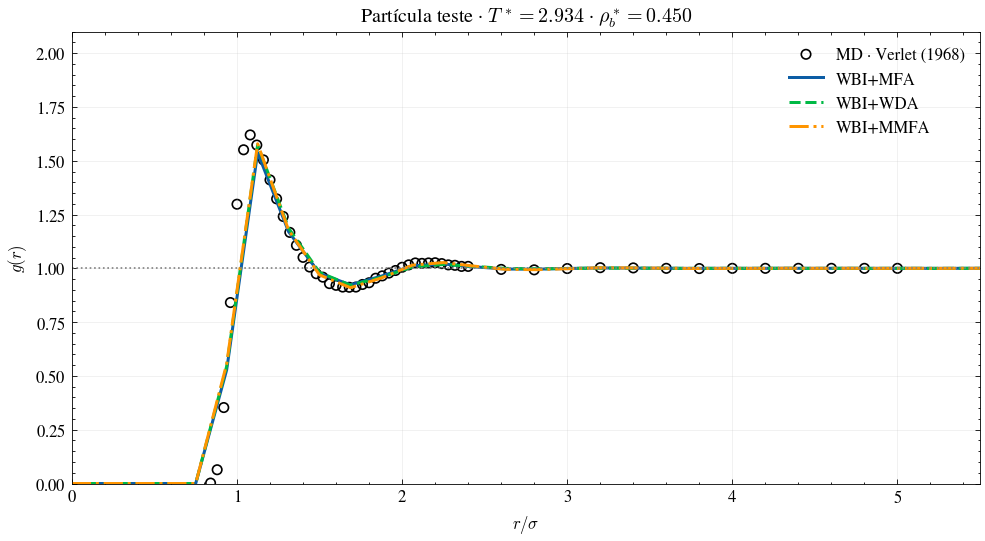

In [64]:
fig, ax = plt.subplots(figsize=(8.2, 4.5), constrained_layout=True)
ax.scatter(md_rdf["r"], md_rdf[f"KT={T_rdf:.3f}"], facecolors="none", edgecolors="k", s=32, label="MD · Verlet (1968)")
for (modelo, (r, g)), estilo in zip(perfis_rdf.items(), ["-", "--", "-."]):
    ax.plot(r, g, estilo, lw=1.8, label="WBI+"+modelo)
ax.axhline(1, color="0.5", ls=":", lw=1)
ax.set(xlim=(0, 5.5), ylim=(0, 2.1), xlabel=r"$r/\sigma$", ylabel=r"$g(r)$",
       title=fr"Partícula teste · $T^*={T_rdf:.3f}$ · $\rho_b^*={rho_rdf:.3f}$")
ax.legend(frameon=False)
plt.show()


# Parte F — Troubleshooting e desempenho


## 16. Limites e diagnóstico



### 16.1 O modelo deste curso não inclui

- Misturas, moléculas multisítio ou orientações;
- Cargas, quadrupolos e eletrostática;
- Associação, ligações de hidrogênio e flexibilidade do sólido;
- Células não ortogonais.



### 16.2 Problemas comuns

| Sintoma | Ação |
|---|---|
| Método antigo `Set_...` ou argumento `ndim` | Use a API `snake_case` da v1.0.3 |
| `float` sem método `.round()` | Não use `get_fluid_density_information()`; formate com `f"{float(x):.3f}"` |
| Solver oscila | Reduza `alpha`, use continuação; compare os métodos na seção 17 |
| RDF MMFA com `NaN` em Picard | Use o ABC-FIRE da seção 15; não aceite o perfil da iteração que falhou |
| Isoterma 1D lenta | Use a faixa 1–3 bar e continuação da seção 9; acompanhe o progresso |
| `NaN` em $H<3\sigma$ | Trate como caso avançado; refine a estratégia, não apenas `max_iter` |
| CUDA sem memória ou indisponível | Use CPU ou malha menor; meça o custo na seção 18 |
| py3Dmol vazio | Altere o isovalor ou use os cortes Matplotlib |
| Isoterma converge mas é irreal | Audite unidades, parâmetros, funcional, cutoff e definição de excesso |

Convergência numérica é necessária; validação física continua indispensável.


**Malha e pressão:** a seção 13 chega a 900 bar, mas a convergência do solver não garante independência de malha nessa faixa. A extensão 32³/64³/128³ mantém um estudo separado em baixa pressão.

**Overflow no núcleo LJ:** a soma atomística em float32 pode produzir +∞ junto aos átomos do sólido. `set_temperature` classifica essas regiões como proibidas. Isso é diferente de um NaN no resíduo do solver, que invalida o resultado.


## 17. Otimizadores: comparação no slab atomístico 3D

Retomamos **o mesmo sistema 3D da seção 10**, a 300 K e 10 bar, e restauramos a densidade bulk antes de cada método. Fluido, slab, campo, malha, reservatório e tolerâncias são iguais. O custo de construir o slab e Vext fica fora do cronômetro.

Picard usa agora `alpha=0.20`. Anderson usa `alpha=0.10`, histórico de seis vetores e regularização de $10^{-6}$. ABC-FIRE usa mistura inicial 0,50 e passos 0,05–0,10. Os parâmetros foram ajustados para este caso, e não são recomendações universais.

$$\mathrm{Erro}=\frac{1}{\sqrt N}\left\|\frac{R_i}{\mathrm{atol}+\mathrm{rtol}|\ln\rho_i|}\right\|_2<1.$$

Os gráficos usam **todos os valores registrados, sem suavização ou remoção de iterações**. Um pequeno retorno do resíduo em FIRE pode ocorrer por sua dinâmica inercial; isso é diferente dos grandes picos/divergências da comparação anterior. A tabela também permite verificar que os três métodos chegam à mesma quantidade adsorvida.


In [65]:
solver_3d = slab_dft
solver_3d.set_bulk_density(rho_res_c)
solver_3d.set_initial_condition("bulk")
estado_inicial = solver_3d.state.detach().clone()
solver_3d.update_system()  # Aquecimento das FFTs antes de medir os métodos.


Resolveremos exatamente o mesmo perfil inicial com os três otimizadores. Guardaremos erro, Ω, tempo e número de iterações para a comparação.


In [66]:
metodos = {
    "Picard": ("picard", {"alpha": 0.20}),
    "Anderson": ("anderson", {"alpha": 0.10, "history_size": 6, "regularization": 1e-6}),
    "ABC-FIRE": ("fire", {"mode": "abc-fire", "alpha": 0.50, "dt": 0.05, "dt_max": 0.10}),
}

resumo, historicos, energias = [], {}, {}
for nome, (algoritmo, parametros) in metodos.items():
    # Mesma condição inicial para uma comparação justa.
    with torch.no_grad():
        solver_3d.state.copy_(estado_inicial)
    solver_3d.apply_update()

    opt = Optimizer.create(
        algoritmo, solver_3d, **parametros,
        atol=1e-7, rtol=1e-4, max_iter=2000,
    )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    inicio = time.perf_counter()
    erro, n_iter = opt.run()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    tempo = time.perf_counter() - inicio

    resumo.append([nome, n_iter, tempo, erro, opt.converged, opt.stop_reason, float(solver_3d.Nabs)])
    historicos[nome] = opt.error_log.copy()
    energias[nome] = (np.asarray(opt.energy_log)/epsilon_c).tolist()

benchmark_solver = pd.DataFrame(
    resumo, columns=["Método", "Iterações", "Tempo (s)", "Erro final", "Convergiu", "Motivo", "Nabs"]
)
display(benchmark_solver.style.format({"Tempo (s)": "{:.3f}", "Erro final": "{:.2e}"}))


,Método,Iterações,Tempo (s),Erro final,Convergiu,Motivo,Nabs
0,Picard,36,0.377,9.41e-01,True,Convergence criterion reached,29.723406
1,Anderson,9,0.326,3.51e-01,True,Convergence criterion reached,29.739162
2,ABC-FIRE,57,2.604,8.82e-01,True,Convergence criterion reached,29.723835


Os gráficos mostram resíduo, Ω e tempo. Um patamar de energia pode aparecer antes de o resíduo satisfazer a tolerância.


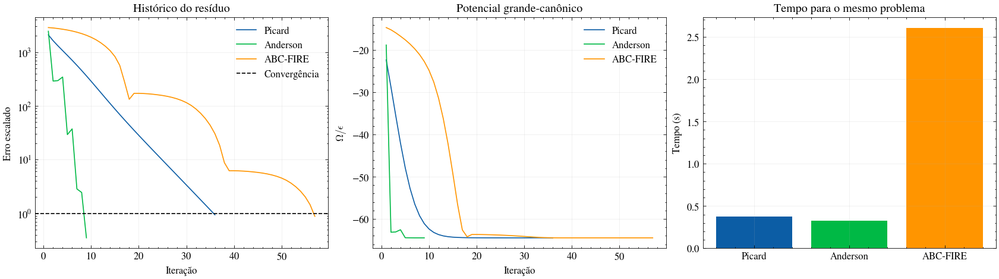

In [67]:
fig, ax = plt.subplots(1, 3, figsize=(14.0, 3.9), constrained_layout=True)
for nome, erros in historicos.items():
    it = np.arange(1, len(erros)+1)
    ax[0].semilogy(it, erros, label=nome)
    ax[1].plot(np.arange(1, len(energias[nome])+1), energias[nome], label=nome)
ax[0].axhline(1, color="k", ls="--", lw=1, label="Convergência")
ax[0].set(xlabel="Iteração", ylabel="Erro escalado", title="Histórico do resíduo")
ax[1].set(xlabel="Iteração", ylabel=r"$\Omega/\epsilon$", title="Potencial grande-canônico")
for eixo in ax[:2]:
    eixo.legend(frameon=False)
ax[2].bar(benchmark_solver["Método"], benchmark_solver["Tempo (s)"], color=["C0", "C1", "C2"])
ax[2].set(ylabel="Tempo (s)", title="Tempo para o mesmo problema")
for barra, convergiu in zip(ax[2].patches, benchmark_solver["Convergiu"]):
    if not convergiu:
        barra.set_hatch("//")
        ax[2].annotate("Falhou", (barra.get_x()+barra.get_width()/2, barra.get_height()),
                       ha="center", va="bottom", fontsize=8)
plt.show()


## 18. CPU ou GPU? Meça a mudança de escala

**Sem GPU disponível?** Todos os exemplos podem ser executados em CPU; comece por malhas pequenas e guarde seus resultados.

Uma FFT curta em 1D ocupa pouco a GPU. Lançamento de kernels, sincronizações e transferências podem custar mais que o cálculo; o solver também lê escalares na CPU a cada iteração. Por isso, uma GPU não precisa vencer o exemplo anterior.

Agora resolveremos um **problema cDFT 3D completo**, com campo periódico suave e malhas **32³, 64³ e 128³**, todas incluídas por padrão. Duplicar N multiplica o número de pontos por oito. Usaremos o mesmo funcional, estado, chute, tolerância e solver em ambos os dispositivos.

O campo suave facilita a convergência e isola o custo das convoluções. Configuração e aquecimento ficam fora do cronômetro; três repetições geram uma mediana. O objetivo é observar o comportamento no hardware disponível, não garantir previamente um speedup.


In [68]:
def criar_benchmark_3d(N, device):
    s = DFT(functional="aWBI+MMFA", device=device)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=3.5)
    s.set_gridsize(8.0/N)
    s.set_geometry(lengths=(8.0, 8.0, 8.0))
    s._from_ase = False
    V = 0.1 * (np.cos(2*np.pi*s.X/8) + np.cos(2*np.pi*s.Y/8) + np.cos(2*np.pi*s.Z/8))
    s.set_external_potential(V)
    s.set_temperature(1.5)
    s.set_bulk_density(0.10)
    s.set_initial_condition("bulk")
    return s

print("Threads PyTorch na CPU:", torch.get_num_threads())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Indisponível")


Threads PyTorch na CPU: 1
GPU: Tesla T4


Vamos cronometrar somente a resolução. Cada repetição começa do bulk. As verificações de convergência e Nabs evitam comparar tempos de soluções diferentes. Este bloco é uma extensão e pode levar alguns minutos na CPU.


In [69]:
dispositivos = ["cpu"] + (["cuda"] if torch.cuda.is_available() else [])
registros = []
N_BENCH = [32, 64, 128]  # Comparação completa, inclusive em CPU.
for N in N_BENCH:
    for device in dispositivos:
        with redirect_stdout(StringIO()):
            s = criar_benchmark_3d(N, device)
        s.update_system()  # Aquecimento das FFTs antes da medição.
        for repeticao in range(3):
            s.set_initial_condition("bulk")
            opt = Optimizer.create("anderson", s, alpha=0.10, regularization=1e-6,
                                   atol=1e-7, rtol=1e-4, max_iter=2000)
            if device == "cuda": torch.cuda.synchronize()
            inicio = time.perf_counter()
            opt.run()
            if device == "cuda": torch.cuda.synchronize()
            registros.append([N, device, time.perf_counter()-inicio,
                              opt.Niter, opt.error, opt.converged, float(s.Nabs)])
        del opt, s
        gc.collect()
        if device == "cuda": torch.cuda.empty_cache()

bench = pd.DataFrame(registros, columns=["N", "Dispositivo", "Tempo (s)",
                                        "Iterações", "Erro", "Convergiu", "Nabs"])
resumo_gpu = bench.groupby(["N", "Dispositivo"], as_index=False).agg(
    Tempo_s=("Tempo (s)", "median"), Iteracoes=("Iterações", "median"),
    Erro=("Erro", "max"), Convergiu=("Convergiu", "all"), Nabs=("Nabs", "median"))
display(resumo_gpu.style.format({"Tempo_s": "{:.3f}", "Erro": "{:.2e}", "Nabs": "{:.5f}"}))

if "cuda" in dispositivos:
    nabs_por_device = resumo_gpu.pivot(index="N", columns="Dispositivo", values="Nabs")
    diferenca_nabs = abs(nabs_por_device["cpu"]-nabs_por_device["cuda"]) / abs(nabs_por_device["cpu"])
    print("Diferença relativa de Nabs (CPU/GPU):")
    display(diferenca_nabs.rename("Diferença relativa").to_frame())


,N,Dispositivo,Tempo_s,Iteracoes,Erro,Convergiu,Nabs
0,32,cpu,0.252,9.000000,8.85e-01,True,51.68807
1,32,cuda,0.091,8.000000,6.13e-02,True,51.69235
2,64,cpu,1.895,9.000000,9.77e-01,True,51.68346
3,64,cuda,0.140,8.000000,2.96e-02,True,51.69154
4,128,cpu,23.994,10.000000,9.28e-01,True,51.68383
5,128,cuda,0.761,8.000000,1.45e-01,True,51.69398


Diferença relativa de Nabs (CPU/GPU):


,Diferença relativa
N,
32,0.000083
64,0.000156
128,0.000196


O gráfico à esquerda mostra o custo do solver conforme a malha cresce. À direita, o speedup é a razão entre medianas, apenas onde todos os cálculos convergiram. Em uma sessão sem CUDA, teremos somente a referência CPU.


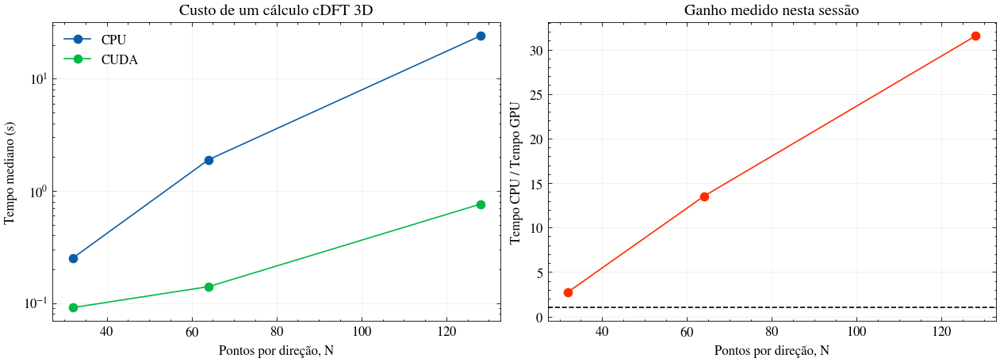

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for device in dispositivos:
    t = resumo_gpu.query("Dispositivo == @device and Convergiu")
    ax[0].plot(t["N"], t["Tempo_s"], "o-", label=device.upper())
ax[0].set(xlabel="Pontos por direção, N", ylabel="Tempo mediano (s)",
          yscale="log", title="Custo de um cálculo cDFT 3D")
ax[0].legend(frameon=False)
tempos_gpu = resumo_gpu[resumo_gpu["Convergiu"]].pivot(index="N", columns="Dispositivo", values="Tempo_s")
if "cuda" in tempos_gpu:
    ax[1].plot(tempos_gpu.index, tempos_gpu["cpu"]/tempos_gpu["cuda"], "o-", color="C3")
    ax[1].axhline(1, color="k", ls="--", lw=1)
else:
    ax[1].text(0.5, 0.5, "Ative GPU no Colab para medir o speedup", transform=ax[1].transAxes, ha="center", wrap=True)
ax[1].set(xlabel="Pontos por direção, N", ylabel="Tempo CPU / Tempo GPU", title="Ganho medido nesta sessão")
plt.show()


# Parte G — Aplicação à pesquisa


## 19. Para adaptar à sua pesquisa

Antes de trocar o CIF e apertar “Run all”, registre:

| Decisão | Pergunta mínima |
|---|---|
| adsorvato | um sítio LJ representa a molécula nesta faixa de $T,p$? |
| sólido | a estrutura é rígida, periódica e ortogonal? |
| campo de força | há parâmetros para todos os elementos e uma regra de combinação defensável? |
| funcional | MFA, WDA ou MMFA muda a conclusão? |
| malha/cutoff | o observável converge quando são refinados? |
| solver | o erro é menor que 1 e o estado independe do chute? |
| adsorção | absoluta ou excesso? Qual volume de referência? |

Outras possibilidades dos exemplos do repositório incluem paredes duras, cilindros, função de distribuição radial, outros MOFs/ZIFs e carbonos amorfos.


### 19.1 Checklist final

- [ ] Commit do código registrado;
- [ ] Unidades e parâmetros com referência;
- [ ] EOS e funcional coerentes no limite uniforme;
- [ ] Campo de força e regra de combinação documentados;
- [ ] Malha, cutoff e solver testados;
- [ ] `converged=True` e erro final reportado;
- [ ] Adsorção absoluta/excesso definida;
- [ ] Comparação com simulação ou experimento independente;
- [ ] Limitações que podem alterar a conclusão discutidas.

Se você consegue explicar esta linha, está pronto para adaptar o cálculo:

```text
fluido → malha → geometria → Vext → T → bulk → chute → solver → perfil/isoterma
```


### 19.2 Verificação desta revisão

A revisão 6 foi testada localmente em CPU. Os parâmetros e resultados verificados aparecem nas saídas das células; versões e número de threads estão registrados no início.

- Slab ASE de carbono, imagem mínima, soma LJ e três controles de densidade: Steele 1D, camadas finitas 1D e slab atomístico 3D.
- Isoterma da MOF com 44 pressões, incluindo 900 bar, e diagnóstico de convergência por ponto.
- Picard, Anderson e ABC-FIRE no mesmo slab 3D, sempre partindo do bulk e mostrando históricos sem suavização.
- Benchmark CPU em 32³, 64³ e 128³. A curva GPU é calculada automaticamente quando CUDA está disponível.

Não houve teste desta revisão em GPU nem diretamente na interface do Colab. Cada título está agora em uma célula de texto própria, sem outro título na mesma célula, para evitar que o sumário do Colab agrupe seção e subseção. Os estudos inalterados de RDF, N₂ e isotermas finas da MOF não foram integralmente reexecutados nesta revisão.


### 19.3 Referências essenciais

1. E. do A. Soares, A. G. Barreto e F. W. Tavares, *Fluid Phase Equilibria* (2023), 113887. [DOI](https://doi.org/10.1016/j.fluid.2023.113887)
2. Y. Rosenfeld, *Physical Review Letters* 63 (1989), 980. [DOI](https://doi.org/10.1103/PhysRevLett.63.980)
3. Y.-X. Yu e J. Wu, *Journal of Chemical Physics* 117 (2002), 10156. [DOI](https://doi.org/10.1063/1.1520530)
4. H. Hansen-Goos e R. Roth, *Journal of Physics: Condensed Matter* 18 (2006), 8413. [DOI](https://doi.org/10.1088/0953-8984/18/37/002)
5. R. Roth et al., *Journal of Physics: Condensed Matter* 14 (2002), 12063. [DOI](https://doi.org/10.1088/0953-8984/14/46/313)
6. G. Shen, X. Ji e X. Lu, *Journal of Chemical Physics* 138 (2013), 224706. [DOI](https://doi.org/10.1063/1.4808160)
7. E. do A. Soares, A. G. Barreto e F. W. Tavares, *Fluid Phase Equilibria* 542–543 (2021), 113095. [DOI](https://doi.org/10.1016/j.fluid.2021.113095)
8. J. K. Johnson, J. A. Zollweg e K. E. Gubbins, *Molecular Physics* 78 (1993), 591. [DOI](https://doi.org/10.1080/00268979300100411)
9. W. A. Steele, *Surface Science* 36 (1973), 317. [DOI](https://doi.org/10.1016/0039-6028(73)90264-1)
10. M. G. Martin e J. I. Siepmann, TraPPE-UA, *J. Phys. Chem. B* 102 (1998), 2569. [DOI](https://doi.org/10.1021/jp972543+)
11. S. L. Mayo, B. D. Olafson e W. A. Goddard, DREIDING, *J. Phys. Chem.* 94 (1990), 8897. [DOI](https://doi.org/10.1021/j100389a010)
12. A. K. Rappé et al., UFF, *JACS* 114 (1992), 10024. [DOI](https://doi.org/10.1021/ja00051a040)
13. D. G. Anderson, *Journal of the ACM* 12 (1965), 547. [DOI](https://doi.org/10.1145/321296.321305)
14. E. Bitzek et al., FIRE, *Physical Review Letters* 97 (2006), 170201. [DOI](https://doi.org/10.1103/PhysRevLett.97.170201)

Código e exemplos: [PyDFTlj](https://github.com/elvissoares/PyDFTlj), licença GPL-3.0.

15. I. K. Snook e W. van Megen, *Solvation forces in simple dense fluids. I* (1980). [DOI](https://doi.org/10.1063/1.439489).
16. P. I. Ravikovitch et al., *Langmuir* 16 (2000), 2311–2320. [DOI](https://doi.org/10.1021/la991011c).
17. A. Fortini e M. Dijkstra, *J. Phys.: Condens. Matter* 18 (2006), L371. [DOI](https://doi.org/10.1088/0953-8984/18/28/L02).
18. M. Schmidt e H. Löwen, *Phys. Rev. E* 55 (1997), 7228. [DOI](https://doi.org/10.1103/PhysRevE.55.7228).
19. L. Verlet, *Phys. Rev.* 165 (1968), 201. [DOI](https://doi.org/10.1103/PhysRev.165.201).
